<a href="https://colab.research.google.com/github/RusieckiFilip/Inzynieria_Obliczeniowa_UW/blob/main/ONS_ANALIZA_ALKOHOL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas openpyxl
!pip install eurostat

In [ ]:
import pandas as pd
import requests
import os

# Funkcja do pobierania plików z repozytorium GitHuba
def download_files_from_github(repo_url, folder_path, local_folder):
    try:
        # Pobranie zawartości folderu z GitHuba
        response = requests.get(f"{repo_url}/{folder_path}")
        response.raise_for_status()
        files = response.json()

        if not os.path.exists(local_folder):
            os.makedirs(local_folder)

        # Pobieranie każdego pliku
        for file in files:
            if file['type'] == 'file' and file['name'].endswith('.xlsx') or file['type'] == 'file' and file['name'].endswith('.csv') :
                file_url = file['download_url']
                local_file_path = os.path.join(local_folder, file['name'])

                with requests.get(file_url, stream=True) as r:
                    r.raise_for_status()
                    with open(local_file_path, 'wb') as f:
                        for chunk in r.iter_content(chunk_size=8192):
                            f.write(chunk)

                print(f"Pobrano: {file['name']}")

    except Exception as e:
        print(f"Wystąpił błąd podczas pobierania plików: {e}")

# Funkcja do wczytywania plików Excel i wyciągania tabel do listy
def extract_tables_from_files(local_folder):
    tables = {}

    try:
        for file_name in os.listdir(local_folder):
            if file_name.endswith('.xlsx'):
                file_path = os.path.join(local_folder, file_name)

                # Wczytanie wszystkich arkuszy do słownika DataFrame'ów
                excel_data = pd.read_excel(file_path, sheet_name=None, engine='openpyxl')

                # Wyodrębnienie nazwy zmiennej (bez rozszerzenia .xlsx)
                variable_name = os.path.splitext(file_name)[0]
                tables[variable_name] = []

                for sheet_name, data in excel_data.items():
                    tables[variable_name].append(data)

                print(f"Wczytano tabele z pliku: {variable_name}")

        return tables
    except Exception as e:
        print(f"Wystąpił błąd podczas wczytywania plików Excel: {e}")
        return None

# URL repozytorium GitHub i folderu
repo_url = "https://api.github.com/repos/RusieckiFilip/Inzynieria_Obliczeniowa_UW/contents"
folder_path = "DATABASES/ALCOHOL_CONSUMPTION/POLAND/"
local_folder_parpa = "POLSKA/PARPA"

# Pobieranie plików z GitHuba
download_files_from_github(repo_url, folder_path + 'PARPA', local_folder_parpa)
download_files_from_github(repo_url, folder_path + 'GUS', 'POLSKA/GUS')
# Wyciąganie tabel z plików Excel
tables_parpa = extract_tables_from_files(local_folder_parpa)
tables_parpa = extract_tables_from_files(local_folder_parpa)
# Wyświetlenie nazw zmiennych i liczby tabel w każdym pliku
if tables_parpa:
    for variable_name, sheets in tables_parpa.items():
        print(f"Plik: {variable_name}, liczba arkuszy: {len(sheets)}")


Pobrano: 2014.xlsx
Pobrano: 2015.xlsx
Pobrano: 2016.xlsx
Pobrano: 2017.xlsx
Pobrano: 2018.xlsx
Pobrano: 2019.xlsx
Pobrano: 2020.xlsx
Pobrano: 2021.xlsx
Pobrano: 2022.xlsx
Pobrano: 2023.xlsx
Pobrano: LUDNOSC_POLSKA.csv
Pobrano: PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - ALKOHOL.xlsx
Pobrano: PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - BEZ ALKOHOLU.xlsx
Pobrano: Przeciętne miesięczne wydatki na 1 osobę.xlsx
Wczytano tabele z pliku: 2016
Wczytano tabele z pliku: 2019
Wczytano tabele z pliku: 2023
Wczytano tabele z pliku: 2015
Wczytano tabele z pliku: 2021
Wczytano tabele z pliku: 2020
Wczytano tabele z pliku: 2014
Wczytano tabele z pliku: 2022
Wczytano tabele z pliku: 2018
Wczytano tabele z pliku: 2017
Wczytano tabele z pliku: 2016
Wczytano tabele z pliku: 2019
Wczytano tabele z pliku: 2023
Wczytano tabele z pliku: 2015
Wczytano tabele z pliku: 2021
Wczytano tabele z pliku: 2020
Wczytano tabele z pliku: 2014
Wczytano tabele z pliku: 2022
Wczytano tabele z 

In [ ]:
tables_parpa['2014'][0]

,Województwo,Liczba punktów\nsprzedaży\nnapojów\nalkoholowych -\nsuma,Liczba\npunktów\nsprzedaży\nnapojów\nalkoholowych\nprzeznaczonych\ndo spożycia\npoza miejscem\nsprzedaży\n(sklepy):,Liczba\npunktów\nsprzedaży\nnapojów\nalkoholowych\nprzeznaczonych\ndo spożycia w\nmiejscu\nsprzedaży\n(lokale\ngastronomiczne):,Liczba punktów\nsprzedaży\nnapojów\nalkoholowych o\nzawartości\nalkoholu\npowyżej 18%-\nsuma,Liczba\npunktów sprzedaży\nnapojów\nalkoholowych o\nzawartości alkoholu\npowyżej 18%\nprzeznaczonych do\nspożycia poza\nmiejscem sprzedaży\n(sklepy):\n,Liczba\npunktów\nsprzedaży\nnapojów\nalkoholowych o\nzawartości\nalkoholu\npowyżej 18%\nprzeznaczonych\ndo spożycia w\nmiejscu\nsprzedaży\n(lokale\ngastronomiczne):,Liczba\nmieszkańców\nprzypadająca\nna jeden\npunkt\nsprzedaży\nnapojów\nalkoholowych\nogółem\n,Liczba\nmieszkańców\nw\nprzypadająca\nna jeden\npunkt\nsprzedaży\nnapojów\nalkoholowych\no zawartości\nalkoholu\npowyżej 18%
0,DOLNOŚLĄSKIE,10660,7029,3631,8102,5945,2157,267,351
1,KUJAWSKO-POMORSKIE,7441,5259,2182,4547,3473,1074,272,444
2,LUBELSKIE,7484,5591,1893,4992,3887,1105,286,428
3,LUBUSKIE,4242,2936,1306,2859,2205,654,237,352
4,ŁÓDZKIE,8422,6367,2055,6373,5233,1140,315,417
5,MAŁOPOLSKIE,12399,8049,4350,9189,6448,2741,269,363
6,MAZOWIECKIE,17630,12414,5216,12956,9970,2986,290,395
7,OPOLSKIE,3571,2373,1198,2774,1939,835,296,381
8,PODKARPACKIE,7060,5000,2060,4539,3380,1159,302,470
9,PODLASKIE,3729,2632,1097,2616,1980,636,317,452


In [ ]:
tables_parpa['2014'][0].iloc[:,1]

,Liczba punktów\nsprzedaży\nnapojów\nalkoholowych -\nsuma
0,10660
1,7441
2,7484
3,4242
4,8422
5,12399
6,17630
7,3571
8,7060
9,3729


In [ ]:
import pandas as pd

def process_excel_file(file_path, sheet_name='TABLICA'):
    """
    Przetwarza plik Excel z danymi GUS i zwraca DataFrame z odpowiednimi kolumnami i indeksami.

    Parameters:
        file_path (str): Ścieżka do pliku Excel.
        sheet_name (str): Nazwa arkusza, domyślnie 'TABLICA'.

    Returns:
        pd.DataFrame: Oczyszczony DataFrame z MultiIndex dla kolumn.
    """
    # Wczytaj dane z arkusza
    data = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # Wyodrębnij pierwszą kolumnę jako 'Nazwa'
    nazwa_column = data.iloc[3:, 0].reset_index(drop=True)
    nazwa_column.name = 'Nazwa'

    # Wyciągnij nagłówki dla pozostałych kolumn (3 wiersze)
    header = data.iloc[:3, 1:]

    # Wypełnij puste wartości w nagłówkach (forward-fill)
    header = header.fillna(method='ffill', axis=1)

    # Utwórz MultiIndex z uzupełnionych nagłówków
    multi_index = pd.MultiIndex.from_arrays(header.values, names=["Category", "Year", "Unit"])

    # Utwórz DataFrame z pominięciem wierszy nagłówków
    data_cleaned = pd.DataFrame(data.iloc[3:, 1:].values, columns=multi_index)

    # Dodaj kolumnę 'Nazwa' z powrotem do DataFrame, jeśli nie istnieje
    if 'Nazwa' not in data_cleaned.columns:
        data_cleaned.insert(0, 'Nazwa', nazwa_column)

    # Usuń wiersze i kolumny pełne braków
    data_cleaned = data_cleaned.dropna(how='all').reset_index(drop=True)

    # Ustaw 'Nazwa' jako poziom indeksu
    data_cleaned.set_index('Nazwa', inplace=True)

    # Diagnoza dostępnych kolumn w MultiIndex
    print("Dostępne kategorie (Category):", data_cleaned.columns.get_level_values('Category').unique())
    print("Dostępne lata (Year):", data_cleaned.columns.get_level_values('Year').unique())
    print("Dostępne jednostki (Unit):", data_cleaned.columns.get_level_values('Unit').unique())

    return data_cleaned


# Przykład użycia funkcji
file_path_1 = "POLSKA/GUS/Przeciętne miesięczne wydatki na 1 osobę.xlsx"
file_path_2 = "POLSKA/GUS/PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - ALKOHOL.xlsx"
file_path_3 = "POLSKA/GUS/PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - BEZ ALKOHOLU.xlsx"

# Przetwarzanie plików
df1 = process_excel_file(file_path_1)
df2 = process_excel_file(file_path_2)
df3 = process_excel_file(file_path_3)
df_ludnosc = ludnosc_polska_df = pd.read_csv("POLSKA/GUS/LUDNOSC_POLSKA.csv", delimiter=',')
df_ludnosc = df_ludnosc.set_index("Województwo")



<ipython-input-6-500733a41e4f>:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  header = header.fillna(method='ffill', axis=1)
<ipython-input-6-500733a41e4f>:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  header = header.fillna(method='ffill', axis=1)


Dostępne kategorie (Category): Index(['ogółem', 'towary i usługi konsumpcyjne',
       'żywność i napoje bezalkoholowe',
       'napoje alkoholowe i wyroby tytoniowe', 'odzież i obuwie',
       'użytkowanie mieszkania lub domu i nośniki energii',
       'wyposażenie mieszkania i prowadzenie gospodarstwa domowego', 'zdrowie',
       'transport', 'łączność', 'rekreacja i kultura', 'edukacja',
       'restauracje i hotele', 'pozostałe wydatki na towary i usługi',
       'ogółem (BAEL)', 'towary i usługi konsumpcyjne (BAEL)',
       'udział wydatków na żywność i napoje bezalkoholowe w wydatkach ogółem',
       'udział wydatków na użytkowanie mieszkania i nośniki energii w wydatkach ogółem'],
      dtype='object', name='Category')
Dostępne lata (Year): Index(['1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype=

<ipython-input-6-500733a41e4f>:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  header = header.fillna(method='ffill', axis=1)


Dostępne kategorie (Category): Index(['ryż - za 1kg', 'bułka pszenna - za 50g',
       'chleb żytni razowy zwykły - za 0,5kg',
       'chleb żytni razowy zwykły - za 1kg', 'chleb żytni razowy - za 1kg',
       'chleb pszenno-żytni - za 0,5kg', 'chleb pszenno-żytni 0,6kg',
       'makaron jajeczny 250g', 'makaron jajeczny - za 400g',
       'mąka pszenna - za 1kg', 'kasza jęczmienna - za 0,5kg',
       'kasza jęczmienna Mazurska 0,5kg', 'kasza gryczana, prażona - za 0,5kg',
       'musli zbożowe z dodatkiem owoców - za 350g',
       'musli zbożowe z dodatkiem owoców 400g',
       'mięso wołowe z kością (rostbef) - za 1kg',
       'mięso wieprzowe z kością (schab środkowy) - za 1kg',
       'mięso wieprzowe bez kości (schab) - za 1 kg',
       'mięso wieprzowe bez kości (łopatka) - za 1kg',
       'kurczęta patroszone - za 1kg', 'szynka wieprzowa gotowana - za 1kg',
       'baleron gotowany - za 1kg', 'kiełbasa sucha - za 1kg',
       'kiełbasa wędzona - za 1kg', 'boczek wędzony - za 1kg

In [ ]:
print('DF1\n',df1)
print('DF2\n',df2)
print('DF3\n',df3)
print('DF_ludnosc\n',df_ludnosc)

DF1
 Category             ogółem                                                  \
Year                   1998    1999    2000    2001    2002    2003    2004   
Unit                   [zł]    [zł]    [zł]    [zł]    [zł]    [zł]    [zł]   
Nazwa                                                                         
POLSKA               503.03  549.76  599.49  609.72  624.99  677.81  694.70   
DOLNOŚLĄSKIE         549.33  603.74  608.62  608.45  623.88  683.29  688.11   
KUJAWSKO-POMORSKIE   440.82  475.92  540.19  572.60  593.50  619.14  621.38   
LUBELSKIE            430.38  490.70  513.64  528.74  570.29  618.24  652.16   
LUBUSKIE             517.02  591.21  604.07  607.13  612.57  663.64  687.18   
ŁÓDZKIE              512.43  576.77  642.53  621.58  647.22  689.76  713.26   
MAŁOPOLSKIE          494.14  533.82  579.96  616.37  607.54  648.77  680.77   
MAZOWIECKIE          588.81  640.12  704.11  709.28  743.95  839.46  863.20   
OPOLSKIE             520.16  555.21  582.09  61

In [ ]:
print(df1['żywność i napoje bezalkoholowe', '2023', '[zł]'])
print(df1['napoje alkoholowe i wyroby tytoniowe', '2023', '[zł]']['POLSKA'])

print(df2['wódka czysta 40% - za 0,5l', '2023', '[zł]'])
print(df2['piwo jasne pełne, butelkowane - za 0,5l', '2008', '[zł]']['POLSKA'])

print(df3['truskawki mrożone - za 0,5kg', '2023', '[zł]'])
print(df3['ryż - za 1kg', '2015', '[zł]']['POLSKA'])

Nazwa
POLSKA                 444.81
DOLNOŚLĄSKIE           456.55
KUJAWSKO-POMORSKIE     432.29
LUBELSKIE              415.38
LUBUSKIE               453.32
ŁÓDZKIE                451.67
MAŁOPOLSKIE            415.83
MAZOWIECKIE            454.65
OPOLSKIE               459.89
PODKARPACKIE           445.76
PODLASKIE              434.97
POMORSKIE              475.28
ŚLĄSKIE                478.82
ŚWIĘTOKRZYSKIE         425.69
WARMIŃSKO-MAZURSKIE    419.39
WIELKOPOLSKIE          419.86
ZACHODNIOPOMORSKIE     456.73
Name: (żywność i napoje bezalkoholowe, 2023, [zł]), dtype: object
42.75
Nazwa
POLSKA                 32.31
DOLNOŚLĄSKIE            32.8
KUJAWSKO-POMORSKIE     31.67
LUBELSKIE              32.58
LUBUSKIE                31.7
ŁÓDZKIE                32.61
MAŁOPOLSKIE            33.12
MAZOWIECKIE            32.14
OPOLSKIE               31.21
PODKARPACKIE           34.04
PODLASKIE              31.49
POMORSKIE              31.08
ŚLĄSKIE                31.27
ŚWIĘTOKRZYSKIE         30.89


In [ ]:
import pandas as pd

# Przygotowanie DataFrame z wynikami
columns = ['PIWA I ALKOHOLE DO 4.5%', 'ALKOHOLE OD 4.5% DO 18%', 'ALKOHOLE OD 18%','ALKOHOLE LACZNIE']
years = list(range(2014, 2024))
miesiac_data = pd.DataFrame(index=years, columns=columns)

for year in years:
    total_population = df_ludnosc[str(year)]['POLSKA'] * 1000 # Wartosci w tysiacach

# Wydatki na rok przez populacje i przez 12 miesiecy
    miesiac_data.at[year, 'PIWA I ALKOHOLE DO 4.5%'] = tables_parpa[str(year)][2].iloc[:, 1][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 4.5% DO 18%'] = tables_parpa[str(year)][2].iloc[:, 2][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 18%'] = tables_parpa[str(year)][2].iloc[:, 3][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE LACZNIE'] = tables_parpa[str(year)][2].iloc[:, 4][16] / (12 * total_population)
    miesiac_data.at[year, 'PIWA I ALKOHOLE DO 4.5% - PROCENTOWY UDZIAL'] = 100 * miesiac_data.at[year, 'PIWA I ALKOHOLE DO 4.5%'] / miesiac_data.at[year, 'ALKOHOLE LACZNIE']
    miesiac_data.at[year, 'ALKOHOLE OD 4.5% DO 18% - PROCENTOWY UDZIAL'] = 100 * miesiac_data.at[year, 'ALKOHOLE OD 4.5% DO 18%'] / miesiac_data.at[year, 'ALKOHOLE LACZNIE']
    miesiac_data.at[year, 'ALKOHOLE OD 18% - PROCENTOWY UDZIAL'] = 100 * miesiac_data.at[year, 'ALKOHOLE OD 18%'] / miesiac_data.at[year, 'ALKOHOLE LACZNIE']

print("PRZECIETNE MIESIECZNE WYDATKI POLAKA (W ZŁ) NA:\n", miesiac_data)


PRZECIETNE MIESIECZNE WYDATKI POLAKA (W ZŁ) NA:
      PIWA I ALKOHOLE DO 4.5% ALKOHOLE OD 4.5% DO 18% ALKOHOLE OD 18%  \
2014               31.176367                9.836063       27.292235   
2015               33.218889                9.227988       32.764302   
2016               35.419753                8.868354       31.007238   
2017               36.108482                9.895772       33.044423   
2018               38.697447               10.444153       34.594621   
2019               39.276989                11.46748       37.208591   
2020               38.252296               11.577682       39.851742   
2021               40.441775               13.495493       44.848355   
2022               44.500215               15.599645       49.354781   
2023               49.349042               17.212616       53.565032   

     ALKOHOLE LACZNIE  PIWA I ALKOHOLE DO 4.5% - PROCENTOWY UDZIAL  \
2014        68.297712                                    45.647748   
2015        75.072

In [ ]:
import pandas as pd

# Dane

# ZRODLO KCPU https://kcpu.gov.pl/wp-content/uploads/2024/09/Spozycie-napojow-alkoholowych-na-jednego-mieszkanca2023.pdf
alkohol_DF = {
    "Rok": list(range(1992, 2024)),
    "Wyroby spirytusowe (100% alkoholu)": [3.5, 3.8, 3.8, 3.5, 2.9, 2.8, 2.4, 2.1, 2.0, 1.7, 1.7, 2.4, 2.5, 2.5, 2.7, 3.0, 3.4, 3.2, 3.2, 3.3, 3.0, 3.6, 3.2, 3.2, 3.2, 3.3, 3.3, 3.7, 3.7, 3.8, 3.5, 3.4],
    "Wino i miody pitne": [7.6, 7.5, 6.9, 6.8, 10.3, 12.8, 13.7, 13.6, 12.0, 10.6, 11.2, 11.3, 10.6, 8.6, 9.1, 8.9, 8.2, 7.0, 7.0, 6.4, 5.9, 5.8, 6.3, 6.3, 5.8, 6.1, 6.0, 6.2, 6.5, 6.7, 6.3, 6.8],
    "Wino i miody pitne w przeliczeniu na 100% alkohol": [0.91, 0.90, 0.83, 0.82, 1.24, 1.54, 1.64, 1.63, 1.44, 1.27, 1.34, 1.36, 1.27, 1.03, 1.09, 1.07, 0.98, 0.84, 0.84, 0.77, 0.71, 0.67, 0.76, 0.76, 0.70, 0.73, 0.72, 0.74, 0.77, 0.80, 0.76, 0.82],
    "Piwo": [38.6, 33.0, 36.4, 39.0, 42.8, 49.8, 54.1, 60.1, 66.9, 66.5, 70.7, 74.8, 82.0, 80.7, 90.8, 93.4, 94.4, 91.2, 90.5, 94.3, 99.2, 97.7, 98.9, 99.1, 99.5, 98.5, 100.5, 97.1, 94.0, 93.2, 92.9, 87.4],
    "Piwo w przeliczeniu na 100% alkohol": [2.12, 1.82, 2.0, 2.15, 2.35, 2.74, 2.98, 3.31, 3.68, 3.66, 3.89, 4.10, 4.51, 4.44, 5.00, 5.14, 5.19, 5.02, 4.98, 5.19, 5.46, 5.37, 5.44, 5.45, 5.47, 5.42, 5.53, 5.34, 5.17, 5.13, 5.11, 4.81]
}

# Tworzenie DataFrame
alkohol_DF = pd.DataFrame(alkohol_DF)

# Wyświetlanie pierwszych kilku wierszy
print(alkohol_DF)

# Zapis do pliku CSV (opcjonalnie)
alkohol_DF.to_csv("spożycie_alkoholu.csv", index=False, encoding="utf-8")

# Wyświetlanie informacji o DataFrame
alkohol_DF.info()

     Rok  Wyroby spirytusowe (100% alkoholu)  Wino i miody pitne  \
0   1992                                 3.5                 7.6   
1   1993                                 3.8                 7.5   
2   1994                                 3.8                 6.9   
3   1995                                 3.5                 6.8   
4   1996                                 2.9                10.3   
5   1997                                 2.8                12.8   
6   1998                                 2.4                13.7   
7   1999                                 2.1                13.6   
8   2000                                 2.0                12.0   
9   2001                                 1.7                10.6   
10  2002                                 1.7                11.2   
11  2003                                 2.4                11.3   
12  2004                                 2.5                10.6   
13  2005                                 2.5    

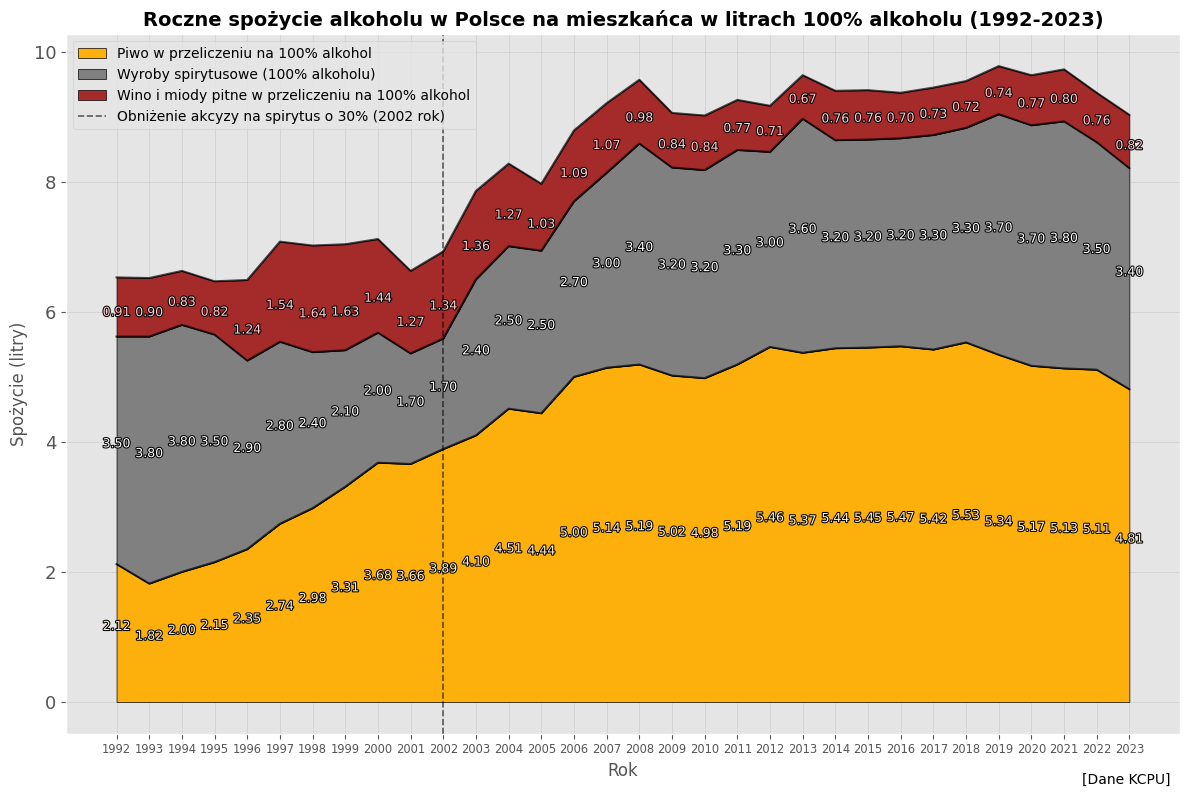

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Dane
alkohol_DF = {
    "Rok": list(range(1992, 2024)),
    "Wyroby spirytusowe (100% alkoholu)": [3.5, 3.8, 3.8, 3.5, 2.9, 2.8, 2.4, 2.1, 2.0, 1.7, 1.7, 2.4, 2.5, 2.5, 2.7, 3.0, 3.4, 3.2, 3.2, 3.3, 3.0, 3.6, 3.2, 3.2, 3.2, 3.3, 3.3, 3.7, 3.7, 3.8, 3.5, 3.4],
    "Wino i miody pitne w przeliczeniu na 100% alkohol": [0.91, 0.90, 0.83, 0.82, 1.24, 1.54, 1.64, 1.63, 1.44, 1.27, 1.34, 1.36, 1.27, 1.03, 1.09, 1.07, 0.98, 0.84, 0.84, 0.77, 0.71, 0.67, 0.76, 0.76, 0.70, 0.73, 0.72, 0.74, 0.77, 0.80, 0.76, 0.82],
    "Piwo w przeliczeniu na 100% alkohol": [2.12, 1.82, 2.0, 2.15, 2.35, 2.74, 2.98, 3.31, 3.68, 3.66, 3.89, 4.10, 4.51, 4.44, 5.00, 5.14, 5.19, 5.02, 4.98, 5.19, 5.46, 5.37, 5.44, 5.45, 5.47, 5.42, 5.53, 5.34, 5.17, 5.13, 5.11, 4.81]
}

# Tworzenie DataFrame
alkohol_DF = pd.DataFrame(alkohol_DF)

# Dane do wykresu
piwo = alkohol_DF["Piwo w przeliczeniu na 100% alkohol"].values
wodka = alkohol_DF["Wyroby spirytusowe (100% alkoholu)"].values
wino = alkohol_DF["Wino i miody pitne w przeliczeniu na 100% alkohol"].values
years = alkohol_DF["Rok"].values

# Tworzenie wykresu
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 8))

# Rysowanie obszarów
ax.fill_between(years, 0, piwo, color='#fdb00b', edgecolor='black', alpha=1.0, label='Piwo w przeliczeniu na 100% alkohol')
ax.fill_between(years, piwo, piwo + wodka, color='gray', edgecolor='black', alpha=1.0, label='Wyroby spirytusowe (100% alkoholu)')
ax.fill_between(years, piwo + wodka, piwo + wodka + wino, color='brown', edgecolor='black', alpha=1.0, label='Wino i miody pitne w przeliczeniu na 100% alkohol')

# Rysowanie linii na granicach obszarów
ax.plot(years, piwo, color='black', alpha=0.7, linewidth=1.5)
ax.plot(years, piwo + wodka, color='black', alpha=0.7, linewidth=1.5)
ax.plot(years, piwo + wodka + wino, color='black', alpha=0.7, linewidth=1.5)

# Dodanie wartości nad liniami
# Piwo
for x, y in zip(years, piwo):
    ax.text(
        x, y / 2, f"{y:.2f}",
        color='#ffefca', fontsize=9, ha='center', va='bottom',
        path_effects=[
            pe.withStroke(linewidth=1.5, foreground='black')
        ]
    )

# Wódka
for x, y_p, y_w in zip(years, piwo, wodka):
    ax.text(
        x, y_p + y_w / 2, f"{y_w:.2f}",
        color='white', fontsize=9, ha='center', va='bottom',
        path_effects=[
            pe.withStroke(linewidth=1.5, foreground='black')
        ]
    )

# Wino
for x, y_pw, y_wi in zip(years, piwo + wodka, wino):
    ax.text(
        x, y_pw + y_wi / 3.35, f"{y_wi:.2f}",
        color='#ffcbd1', fontsize=9, ha='center', va='bottom',
        path_effects=[
            pe.withStroke(linewidth=1.5, foreground='black')
        ]
    )


# Dodanie linii przerywanej w roku 2002
ax.axvline(x=2002, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Obniżenie akcyzy na spirytus o 30% (2002 rok)')

# Dostosowanie osi
ax.set_title('Roczne spożycie alkoholu w Polsce na mieszkańca w litrach 100% alkoholu (1992-2023)', fontsize=14, weight='bold')
ax.set_xlabel('Rok', fontsize=12)
ax.set_ylabel('Spożycie (litry)', fontsize=12)
ax.set_xticks(years)
ax.tick_params(axis='x', labelsize=8.3)
ax.tick_params(axis='y', labelsize=13)

# Siatka
ax.grid(visible=True, linestyle='-', linewidth=0.5, color='black', alpha=0.1)

# Dodanie legendy
ax.legend(loc='upper left', fontsize=10)

# Dodanie napisu [Dane KCPU] w prawym dolnym rogu figury
plt.figtext(0.98, 0.01, '[Dane KCPU]', ha='right', va='bottom', fontsize=10)


# Wyświetlenie wykresu
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd





# Przygotowanie DataFrame dla indeksu inflacyjnego
categories = ['PIWO', 'WÓDKA', 'WINO BIAŁE']
years = list(range(2014, 2024))
inflation_index = pd.DataFrame(index=years, columns=categories)

# Obliczanie indeksu inflacyjnego dla każdego roku
def calculate_inflation_index(base_price, current_price):
    return current_price / base_price

base_prices = {
    'PIWO': df2['piwo jasne pełne, butelkowane - za 0,5l', '2014', '[zł]']['POLSKA'],
    'WÓDKA': df2['wódka czysta 40% - za 0,5l', '2014', '[zł]']['POLSKA'],
    'WINO BIAŁE': df2['wino białe gronowe, wytrawne - za 0,75l', '2014', '[zł]']['POLSKA']
}

for year in years:
    # Piwo
    current_price_beer = df2['piwo jasne pełne, butelkowane - za 0,5l', str(year), '[zł]']['POLSKA']
    inflation_index.at[year, 'PIWO'] = calculate_inflation_index(base_prices['PIWO'], current_price_beer)

    # Wódka
    current_price_vodka = df2['wódka czysta 40% - za 0,5l', str(year), '[zł]']['POLSKA']
    inflation_index.at[year, 'WÓDKA'] = calculate_inflation_index(base_prices['WÓDKA'], current_price_vodka)

    # Wino białe (wytrawne dla 2014-2020, gronowe dla 2021-2023)
    if year <= 2020:
        current_price_wine = df2['wino białe gronowe, wytrawne - za 0,75l', str(year), '[zł]']['POLSKA']
    else:
        current_price_wine = df2['wino białe gronowe - za 0,75l', str(year), '[zł]']['POLSKA']
    inflation_index.at[year, 'WINO BIAŁE'] = calculate_inflation_index(base_prices['WINO BIAŁE'], current_price_wine)

print(inflation_index)


          PIWO     WÓDKA WINO BIAŁE
2014       1.0       1.0        1.0
2015  0.982517  1.156437   1.010417
2016  0.965035  1.132903   1.017708
2017  0.979021  1.124596   2.498958
2018       1.0  1.125519    2.56875
2019  1.045455   1.12275   2.615625
2020   1.08042  1.184126   2.552083
2021  1.101399  1.209045        2.3
2022  1.174825  1.338717   2.460417
2023  1.342657  1.491001      2.675


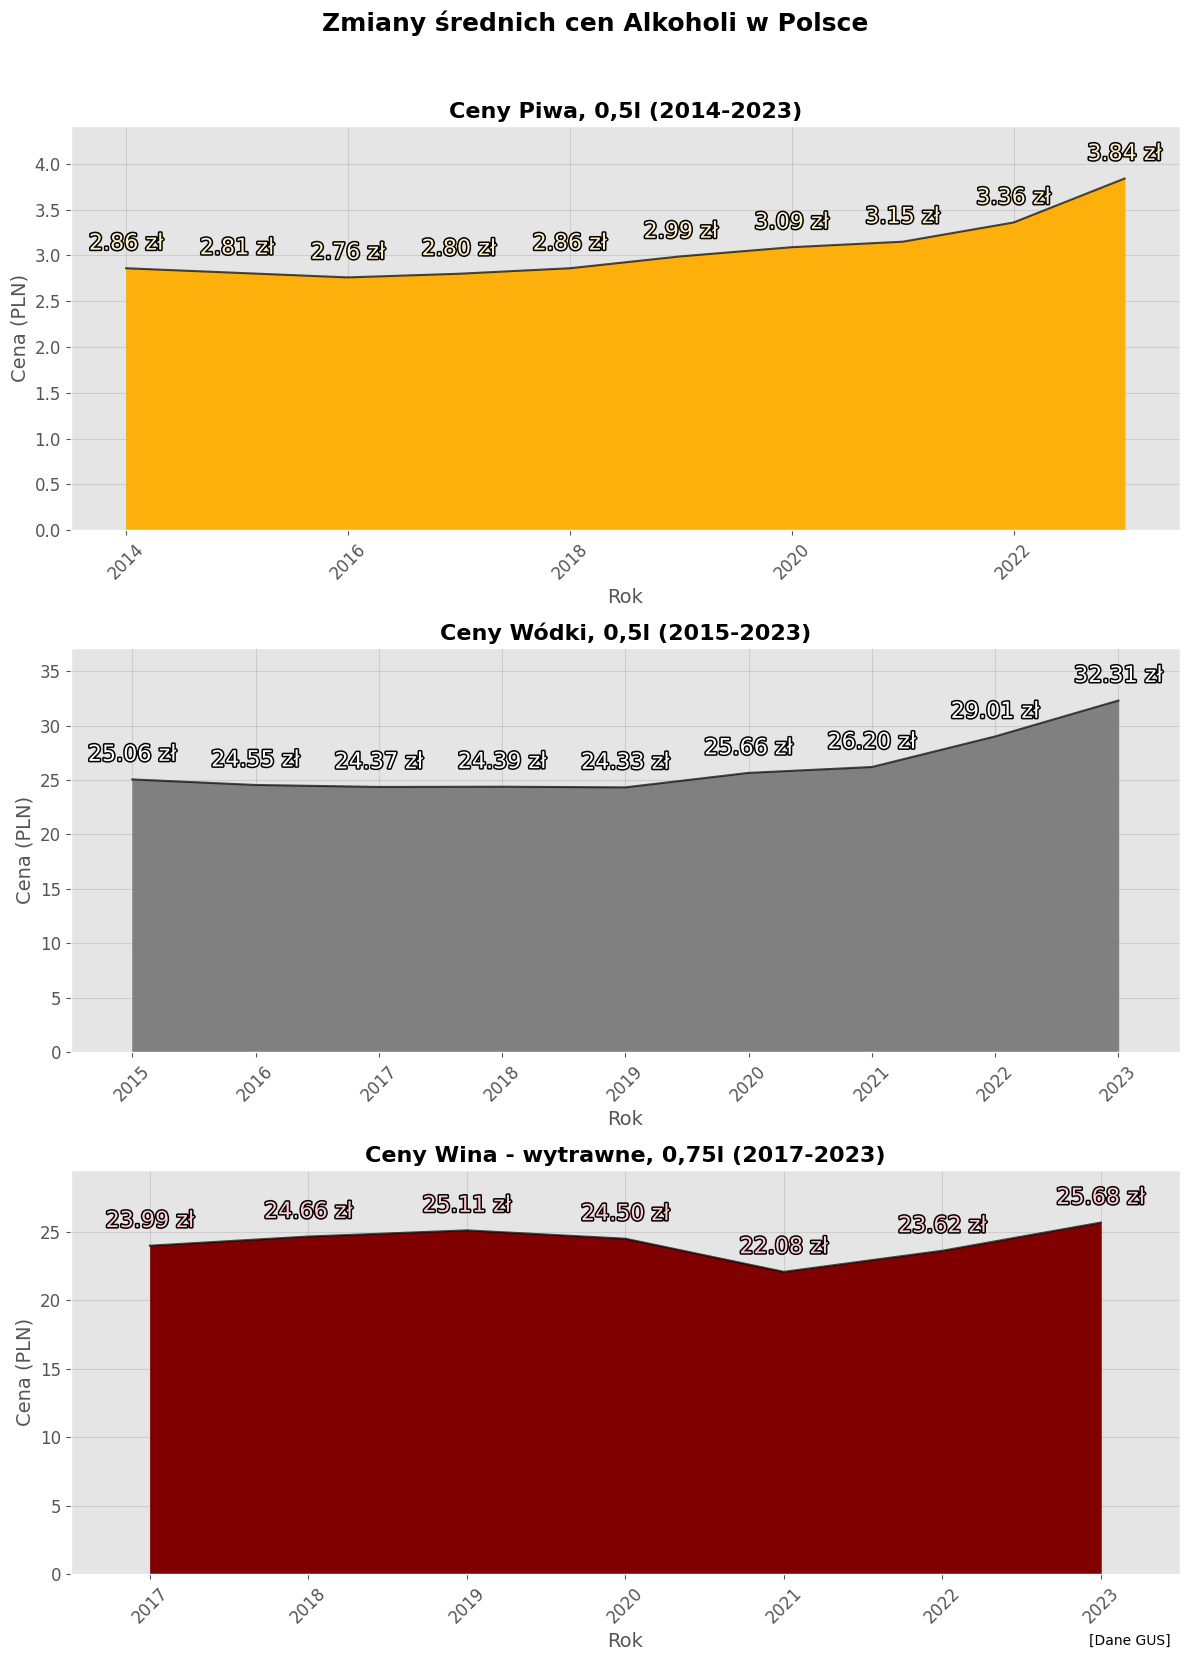

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patheffects as pe

# Dane wynagrodzeń
years = list(range(2014, 2024))  # Lata od 2014 do 2023
values = [4004, 4151, 4291, 4528, 4835, 5182, 5523, 6001, 6706, 7595]  # Wartości dla tych lat

# Tworzenie DataFrame
wynagrodzenia = pd.DataFrame({'Year': years, 'Value': values}).set_index('Year')

# Dane cenowe
years_beer = list(range(2014, 2024))
prices_beer = [df2['piwo jasne pełne, butelkowane - za 0,5l', str(year), '[zł]']['POLSKA'] for year in years_beer]

years_vodka = list(range(2015, 2024))
prices_vodka = [df2['wódka czysta 40% - za 0,5l', str(year), '[zł]']['POLSKA'] for year in years_vodka]

years_wine = list(range(2017, 2024))
prices_wine = [
    df2['wino białe gronowe - za 0,75l', str(year), '[zł]']['POLSKA']
    if year >= 2021 else df2['wino białe gronowe, wytrawne - za 0,75l', str(year), '[zł]']['POLSKA']
    for year in years_wine
]

# Konwersja na typ numeryczny
prices_beer = pd.to_numeric(prices_beer, errors='coerce')
prices_vodka = pd.to_numeric(prices_vodka, errors='coerce')
prices_wine = pd.to_numeric(prices_wine, errors='coerce')

# Funkcja do dynamicznego ustawienia osi Y
def set_dynamic_ylim(ax, y):
    margin = max(y) * 0.15  # Dodanie 15% marginesu
    ax.set_ylim([0, max(y) + margin])

# Funkcja do dodania wartości na wykresie
def annotate_values(ax, x, y, color):
    for i, value in enumerate(y):
        offset = max(y) * 0.07  # Dystans tekstu nad linią
        ax.text(
            x[i], value + offset, f'{value:.2f} zł',  # Wartość nad linią
            color=color, fontsize=16, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')]
        )

# Tworzenie wykresów
plt.style.use('ggplot')  # Styl 'ggplot'
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False)
fig.suptitle('Zmiany średnich cen Alkoholi w Polsce', fontsize=18, fontweight='bold', color='black', y=0.92)

# Wykres dla piwa
axes[0].fill_between(years_beer, prices_beer, color='#fdb00b', alpha=1.0)
axes[0].plot(years_beer, prices_beer, color='black', alpha=0.7, linewidth=1.5)
axes[0].set_title('Ceny Piwa, 0,5l (2014-2023)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Cena (PLN)', fontsize=14)
axes[0].grid(visible=True, linestyle='-', color='black', alpha=0.1)
axes[0].set_xlim([2013.5, 2023.5])
set_dynamic_ylim(axes[0], prices_beer)
annotate_values(axes[0], years_beer, prices_beer, '#ffefca')

# Wykres dla wódki
axes[1].fill_between(years_vodka, prices_vodka, color='gray', alpha=1.0)
axes[1].plot(years_vodka, prices_vodka, color='black', alpha=0.7, linewidth=1.5)
axes[1].set_title('Ceny Wódki, 0,5l (2015-2023)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Cena (PLN)', fontsize=14)
axes[1].grid(visible=True, linestyle='-', color='black', alpha=0.1)
axes[1].set_xlim([2014.5, 2023.5])
set_dynamic_ylim(axes[1], prices_vodka)
annotate_values(axes[1], years_vodka, prices_vodka, 'white')

# Wykres dla wina
axes[2].fill_between(years_wine, prices_wine, color='maroon', alpha=1.0)
axes[2].plot(years_wine, prices_wine, color='black', alpha=0.7, linewidth=1.5)
axes[2].set_title('Ceny Wina - wytrawne, 0,75l (2017-2023)', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Cena (PLN)', fontsize=14)
axes[2].grid(visible=True, linestyle='-', color='black', alpha=0.1)
axes[2].set_xlim([2016.5, 2023.5])
set_dynamic_ylim(axes[2], prices_wine)
annotate_values(axes[2], years_wine, prices_wine, '#ffcbd1')

# Ustawienia osi X dla wszystkich wykresów
for ax in axes:
    ax.set_xlabel('Rok', fontsize=14)
    ax.tick_params(axis='x', labelsize=12, rotation=45)
    ax.tick_params(axis='y', labelsize=12)

# Dodatkowe odstępy między wykresami
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
fig.text(0.98, 0.01, '[Dane GUS]', ha='right', va='bottom', fontsize=10)

# Zapis wykresu do pliku
plt.savefig('zmiany_cen_alkoholi_tv.png', dpi=300)

# Wyświetlenie wykresów
plt.show()


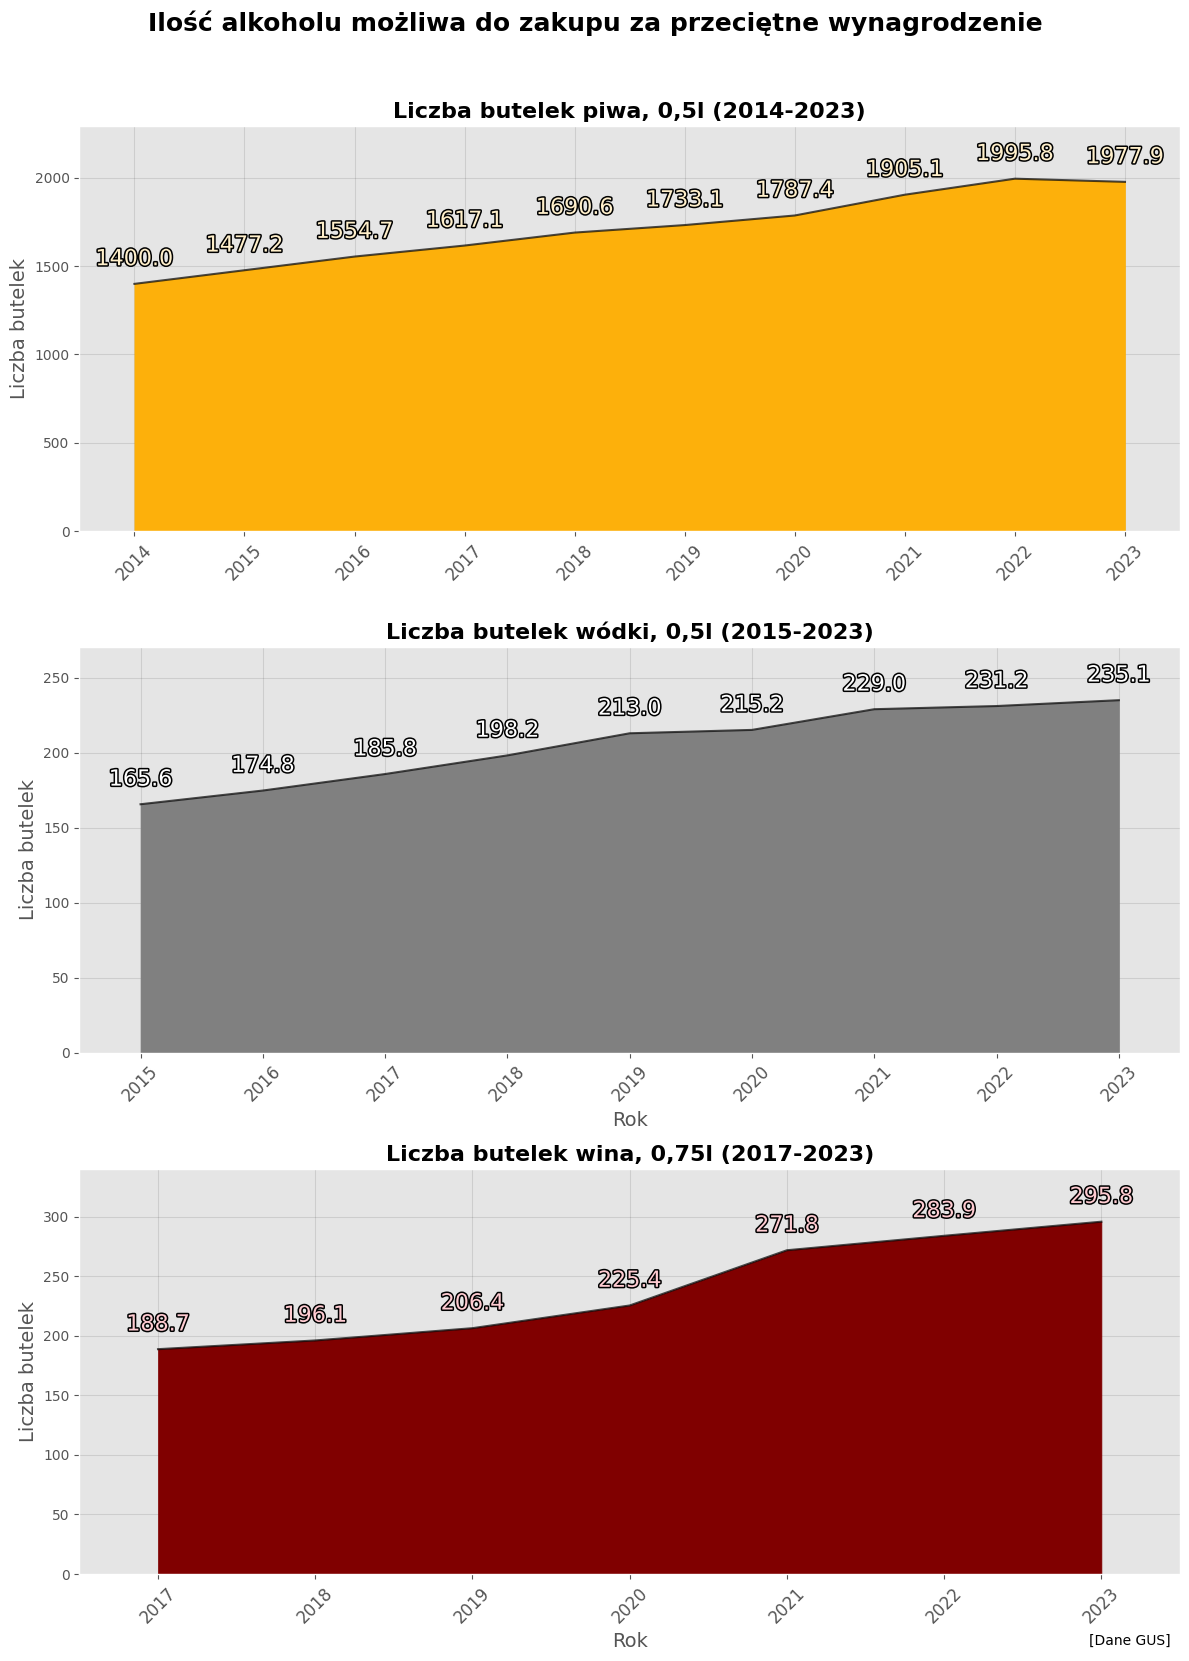

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patheffects as pe

# Dane wynagrodzeń
years = list(range(2014, 2024))  # Lata od 2014 do 2023
values = [4004, 4151, 4291, 4528, 4835, 5182, 5523, 6001, 6706, 7595]  # Wynagrodzenia w PLN
wynagrodzenia = pd.DataFrame({'Year': years, 'Value': values}).set_index('Year')

# Dane cenowe
prices_beer = [df2['piwo jasne pełne, butelkowane - za 0,5l', str(year), '[zł]']['POLSKA'] for year in years]
prices_vodka = [df2['wódka czysta 40% - za 0,5l', str(year), '[zł]']['POLSKA'] for year in range(2015, 2024)]
prices_wine = [
    df2['wino białe gronowe - za 0,75l', str(year), '[zł]']['POLSKA']
    if year >= 2021 else df2['wino białe gronowe, wytrawne - za 0,75l', str(year), '[zł]']['POLSKA']
    for year in range(2017, 2024)
]

# Konwersja na typ numeryczny
prices_beer = pd.to_numeric(prices_beer, errors='coerce')
prices_vodka = pd.to_numeric(prices_vodka, errors='coerce')
prices_wine = pd.to_numeric(prices_wine, errors='coerce')

# Obliczenia ilości
beer_amount = wynagrodzenia['Value'] / prices_beer
vodka_amount = wynagrodzenia.loc[2015:2023, 'Value'] / prices_vodka
wine_amount = wynagrodzenia.loc[2017:2023, 'Value'] / prices_wine

# Tworzenie wykresów
plt.style.use('ggplot')  # Styl 'ggplot'
fig, axes = plt.subplots(3, 1, figsize=(12, 18), sharex=False)
fig.suptitle('Ilość alkoholu możliwa do zakupu za przeciętne wynagrodzenie', fontsize=18, fontweight='bold', color='black', y=0.92)

# Funkcja do dynamicznego ustawienia osi Y
def set_dynamic_ylim(ax, y):
    margin = max(y) * 0.15  # Dodanie 15% marginesu
    ax.set_ylim([0, max(y) + margin])

# Funkcja do dodania wartości na wykresie
def annotate_values(ax, x, y, color):
    for i, value in enumerate(y):
        offset = max(y) * 0.07  # Dystans tekstu nad linią
        ax.text(
            x[i], value + offset, f'{value:.1f}',  # Wartość nad linią
            color=color, fontsize=16, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')]  # Efekt obrysu
        )

# Wykres dla piwa
axes[0].fill_between(years, beer_amount, color='#fdb00b', alpha=1.0)
axes[0].plot(years, beer_amount, color='black', alpha=0.7, linewidth=1.5)
axes[0].set_title('Liczba butelek piwa, 0,5l (2014-2023)', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Liczba butelek', fontsize=14)
axes[0].grid(visible=True, linestyle='-', color='black', alpha=0.1)
axes[0].set_xlim([2013.5, 2023.5])
set_dynamic_ylim(axes[0], beer_amount)
annotate_values(axes[0], years, beer_amount, '#ffefca')

# Wyświetlanie wszystkich lat na osi X dla piwa
axes[0].set_xticks(years)
axes[0].tick_params(axis='x', labelsize=12, rotation=45)

# Wykres dla wódki
axes[1].fill_between(range(2015, 2024), vodka_amount, color='gray', alpha=1.0)
axes[1].plot(range(2015, 2024), vodka_amount, color='black', alpha=0.7, linewidth=1.5)
axes[1].set_title('Liczba butelek wódki, 0,5l (2015-2023)', fontsize=16, fontweight='bold')
axes[1].set_ylabel('Liczba butelek', fontsize=14)
axes[1].grid(visible=True, linestyle='-', color='black', alpha=0.1)
axes[1].set_xlim([2014.5, 2023.5])
set_dynamic_ylim(axes[1], vodka_amount)
annotate_values(axes[1], range(2015, 2024), vodka_amount, 'white')

# Wykres dla wina
axes[2].fill_between(range(2017, 2024), wine_amount, color='maroon', alpha=1.0)
axes[2].plot(range(2017, 2024), wine_amount, color='black', alpha=0.7, linewidth=1.5)
axes[2].set_title('Liczba butelek wina, 0,75l (2017-2023)', fontsize=16, fontweight='bold')
axes[2].set_ylabel('Liczba butelek', fontsize=14)
axes[2].grid(visible=True, linestyle='-', color='black', alpha=0.1)
axes[2].set_xlim([2016.5, 2023.5])
set_dynamic_ylim(axes[2], wine_amount)
annotate_values(axes[2], range(2017, 2024), wine_amount, '#ffcbd1')

# Oś X dla pozostałych wykresów
for ax in axes[1:]:
    ax.set_xlabel('Rok', fontsize=14)
    ax.tick_params(axis='x', labelsize=12, rotation=45)

# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
fig.text(0.98, 0.01, '[Dane GUS]', ha='right', va='bottom', fontsize=10)

# Dodatkowe odstępy między wykresami
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Zapis wykresu do pliku
plt.savefig('ilosc_alkoholu_za_wynagrodzenie.png', dpi=300)

# Wyświetlenie wykresów
plt.show()


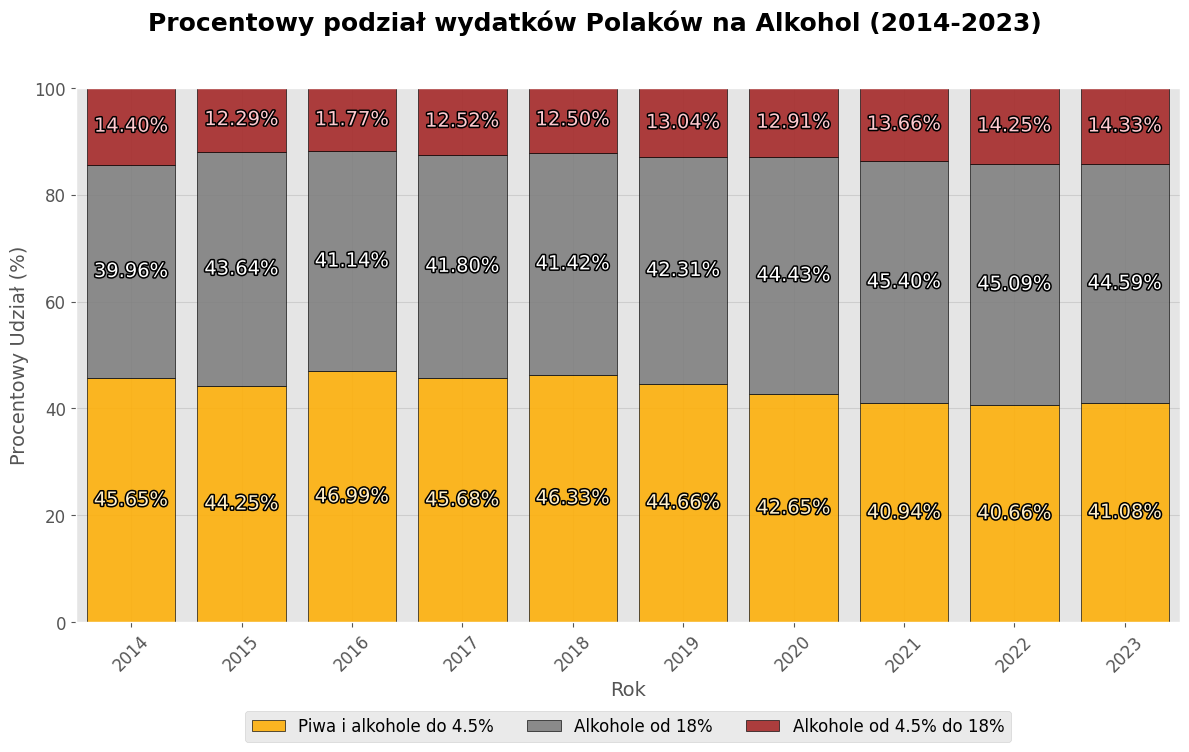

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Dane procentowego udziału wydatków na alkohol
years = list(range(2014, 2024))
pct_beer = [miesiac_data.at[year, 'PIWA I ALKOHOLE DO 4.5% - PROCENTOWY UDZIAL'] for year in years]
pct_medium = [miesiac_data.at[year, 'ALKOHOLE OD 4.5% DO 18% - PROCENTOWY UDZIAL'] for year in years]
pct_strong = [miesiac_data.at[year, 'ALKOHOLE OD 18% - PROCENTOWY UDZIAL'] for year in years]

# Przygotowanie danych do wykresu kolumnowego
data = {
    'Piwa i alkohole do 4.5%': pct_beer,
    'Alkohole od 18%': pct_strong,
    'Alkohole od 4.5% do 18%': pct_medium
}
df = pd.DataFrame(data, index=years)

# Tworzenie wykresu kolumnowego
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Procentowy podział wydatków Polaków na Alkohol (2014-2023)', fontsize=18, fontweight='bold', color='black', y=0.95)

# Tworzenie stosowanych kolumn
colors = ['#fdb00b', 'gray', 'brown']
bottom = np.zeros(len(years))
for idx, (label, color) in enumerate(zip(data.keys(), colors)):
    values = df[label].values
    ax.bar(years, values, bottom=bottom, label=label, color=color, edgecolor='black', alpha=0.9)
    bottom += values

# Dodanie wartości nad kolumnami
for year in years:
    total = 0
    for label, color in zip(data.keys(), colors):
        value = df.at[year, label]
        text_color = '#ffefca' if label == 'Piwa i alkohole do 4.5%' else ('white' if label == 'Alkohole od 18%' else '#ffcbd1')
        ax.text(
            year, total + value / 2, f"{value:.2f}%",
            color=text_color, fontsize=14, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')]
        )
        total += value

# Ustawienia osi
ax.set_xlabel('Rok', fontsize=14)
ax.set_ylabel('Procentowy Udział (%)', fontsize=14)
ax.set_xlim([2013.5, 2023.5])
ax.set_ylim([0, 100])
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.grid(visible=True, linestyle='-', color='black', alpha=0.1)

# Legenda
ax.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Zapis i wyświetlenie wykresu
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('procentowy_udzial_wydatkow_na_alkohol_kolumnowy.png', dpi=300)
plt.show()

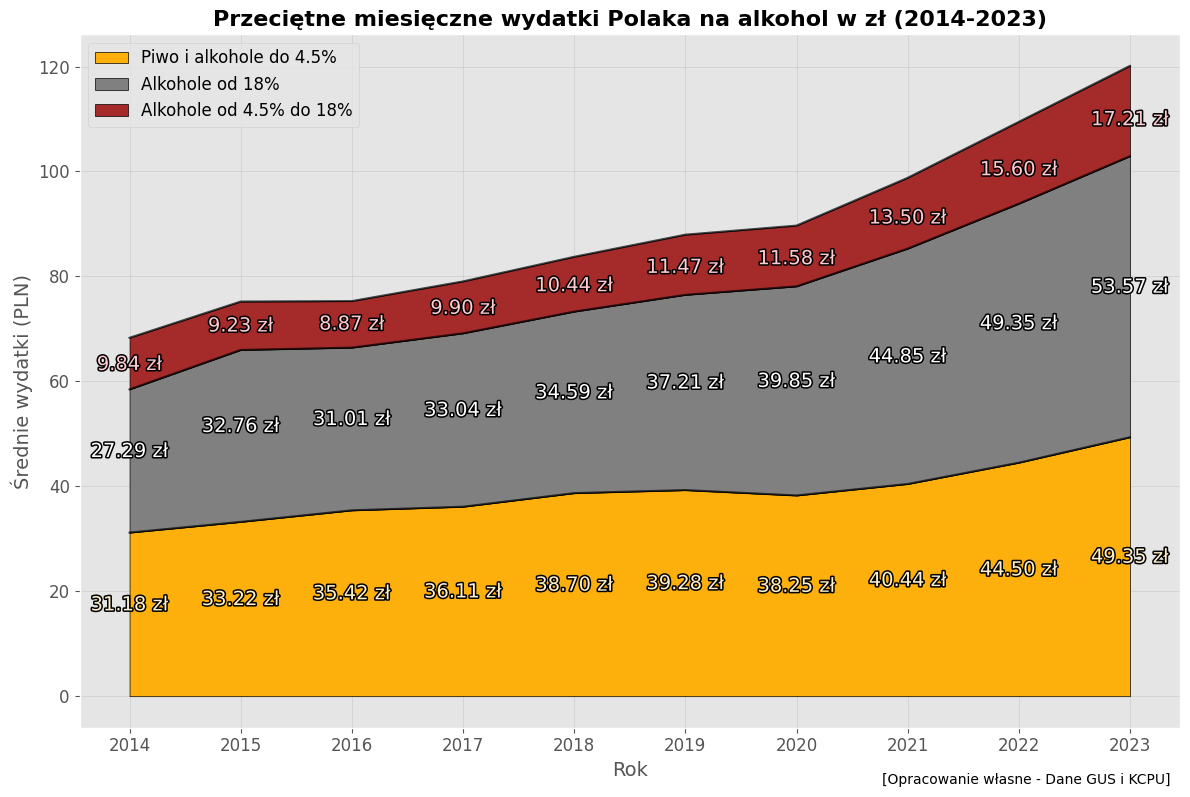

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Przygotowanie danych
columns = ['PIWA I ALKOHOLE DO 4.5%', 'ALKOHOLE OD 4.5% DO 18%', 'ALKOHOLE OD 18%', 'ALKOHOLE LACZNIE']
years = list(range(2014, 2024))
miesiac_data = pd.DataFrame(index=years, columns=columns)

for year in years:
    total_population = df_ludnosc[str(year)]['POLSKA'] * 1000  # Wartości w tysiącach

    # Wydatki na rok przez populację i przez 12 miesięcy
    miesiac_data.at[year, 'PIWA I ALKOHOLE DO 4.5%'] = tables_parpa[str(year)][2].iloc[:, 1][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 4.5% DO 18%'] = tables_parpa[str(year)][2].iloc[:, 2][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 18%'] = tables_parpa[str(year)][2].iloc[:, 3][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE LACZNIE'] = tables_parpa[str(year)][2].iloc[:, 4][16] / (12 * total_population)

# Konwersja kolumn na typ numeryczny
miesiac_data = miesiac_data.apply(pd.to_numeric, errors='coerce')

# Dane do wykresu
piwo = miesiac_data['PIWA I ALKOHOLE DO 4.5%'].values
wodka = miesiac_data['ALKOHOLE OD 18%'].values
wino = miesiac_data['ALKOHOLE OD 4.5% DO 18%'].values
years = np.array(years)

# Tworzenie wykresu
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 8))

# Rysowanie obszarów
ax.fill_between(years, 0, piwo, color='#fdb00b', edgecolor='black', alpha=1.0, label='Piwo i alkohole do 4.5%')
ax.fill_between(years, piwo, piwo + wodka, color='gray', edgecolor='black', alpha=1.0, label='Alkohole od 18%')
ax.fill_between(years, piwo + wodka, piwo + wodka + wino, color='brown', edgecolor='black', alpha=1.0, label='Alkohole od 4.5% do 18%')

# Rysowanie linii na granicach obszarów
ax.plot(years, piwo, color='black', alpha=0.7, linewidth=1.5)
ax.plot(years, piwo + wodka, color='black', alpha=0.7, linewidth=1.5)
ax.plot(years, piwo + wodka + wino, color='black', alpha=0.7, linewidth=1.5)

# Dodanie wartości nad liniami
# Piwo
for x, y in zip(years, piwo):
    ax.text(
        x, y/2, f"{y:.2f} zł",
        color='#ffefca', fontsize=14, ha='center', va='bottom',
        path_effects=[
            pe.withStroke(linewidth=2.2, foreground='black')
        ]
    )

# Wódka
for x, y_p, y_w in zip(years, piwo, wodka):
    ax.text(
        x, y_p + y_w/2, f"{y_w:.2f} zł",
        color='white', fontsize=14, ha='center', va='bottom',
        path_effects=[
            pe.withStroke(linewidth=2.2, foreground='black')
        ]
    )

# Wino
for x, y_pw, y_wi in zip(years, piwo + wodka, wino):
    ax.text(
        x, y_pw + y_wi/3.35, f"{y_wi:.2f} zł",
        color='#ffcbd1', fontsize=14, ha='center', va='bottom',
        path_effects=[
            pe.withStroke(linewidth=2.2, foreground='black')
        ]
    )

# Dostosowanie osi
ax.set_title('Przeciętne miesięczne wydatki Polaka na alkohol w zł (2014-2023)', fontsize=16, weight='bold')
ax.set_xlabel('Rok', fontsize=14)
ax.set_ylabel('Średnie wydatki (PLN)', fontsize=14)
ax.set_xticks(years)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Siatka
ax.grid(visible=True, linestyle='-', linewidth=0.5, color='black', alpha=0.1)

# Dodanie legendy
ax.legend(loc='upper left', fontsize=12)

# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.98, 0.01, '[Opracowanie własne - Dane GUS i KCPU]', ha='right', va='bottom', fontsize=10)

# Wyświetlenie wykresu
plt.tight_layout()
plt.show()


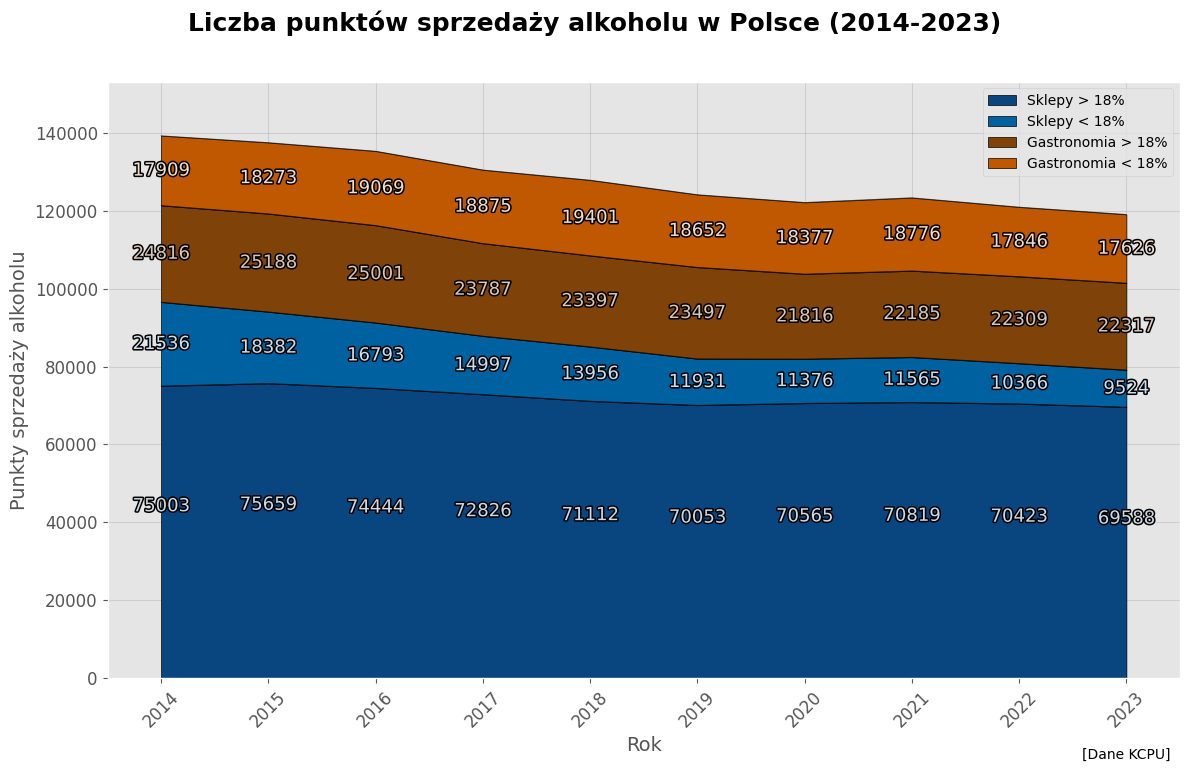

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Przygotowanie danych dla lat 2014-2023
years = list(range(2014, 2024))

# Funkcja do wyciągania danych z tabeli
def extract_points(year, table):
    shop_points_total = table[str(year)][0].iloc[16, 2]  # sklepy ogółem
    gastro_points_total = table[str(year)][0].iloc[16, 3]  # gastronomia ogółem
    shop_points_above_18 = table[str(year)][0].iloc[16, 5]  # sklepy >18%
    gastro_points_above_18 = table[str(year)][0].iloc[16, 6]  # gastronomia >18%

    # Sklepy i gastronomia, które nie sprzedają >18% (czyli różnica)
    shop_points_below_18 = shop_points_total - shop_points_above_18
    gastro_points_below_18 = gastro_points_total - gastro_points_above_18

    return shop_points_below_18, gastro_points_below_18, shop_points_above_18, gastro_points_above_18

# Zbieranie danych dla lat 2014-2023
shop_points_below_18, gastro_points_below_18 = [], []
shop_points_above_18, gastro_points_above_18 = [], []

for year in years:
    shop_below_18, gastro_below_18, shop_18, gastro_18 = extract_points(year, tables_parpa)
    shop_points_below_18.append(shop_below_18)
    gastro_points_below_18.append(gastro_below_18)
    shop_points_above_18.append(shop_18)
    gastro_points_above_18.append(gastro_18)

# Tworzenie wykresu
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Liczba punktów sprzedaży alkoholu w Polsce (2014-2023)', fontsize=18, fontweight='bold', color='black', y=0.95)

# Rysowanie obszarów dla sklepów (poniżej i powyżej 18%)
ax.fill_between(years, 0, shop_points_above_18, color='#09457f', label='Sklepy > 18%', alpha=1.0, edgecolor='black')
ax.fill_between(years, shop_points_above_18, np.array(shop_points_above_18) + np.array(shop_points_below_18),
                color='#0061a0', label='Sklepy < 18%', alpha=1.0, edgecolor='black')

# Rysowanie obszarów dla gastronomii (poniżej i powyżej 18%)
ax.fill_between(years, np.array(shop_points_above_18) + np.array(shop_points_below_18),
                np.array(shop_points_above_18) + np.array(shop_points_below_18) + np.array(gastro_points_above_18),
                color='#7f4309', label='Gastronomia > 18%', alpha=1.0, edgecolor='black')
ax.fill_between(years, np.array(shop_points_above_18) + np.array(shop_points_below_18) + np.array(gastro_points_above_18),
                np.array(shop_points_above_18) + np.array(shop_points_below_18) + np.array(gastro_points_above_18) + np.array(gastro_points_below_18),
                color='#bf5800', label='Gastronomia < 18%', alpha=1.0, edgecolor='black')

# Rysowanie czarnych linii granicznych obszarów
ax.plot(years, shop_points_above_18, color='black', alpha=0.7, linewidth=0.5)
ax.plot(years, np.array(shop_points_above_18) + np.array(shop_points_below_18), color='black', alpha=0.7, linewidth=0.5)
ax.plot(years, np.array(shop_points_above_18) + np.array(shop_points_below_18) + np.array(gastro_points_above_18), color='black', alpha=0.7, linewidth=0.5)
ax.plot(years, np.array(shop_points_above_18) + np.array(shop_points_below_18) + np.array(gastro_points_above_18) + np.array(gastro_points_below_18), color='black', alpha=0.7, linewidth=0.5)

# Dodanie wartości nad słupkami
for year, shop_below, gastro_below, shop_18, gastro_18 in zip(years, shop_points_below_18, gastro_points_below_18,
                                                              shop_points_above_18, gastro_points_above_18):
    ax.text(year, shop_18 + shop_below / 2, f"{shop_below}", color='#ccdfec', fontsize=13, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')])
    ax.text(year, shop_18 / 1.7, f"{shop_18}", color='#cedae5', fontsize=13, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')])
    ax.text(year, shop_below + shop_18 + gastro_18 + gastro_below / 2, f"{gastro_below}", color='#f2decc', fontsize=13, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')])
    ax.text(year, shop_below + shop_18 + gastro_18 / 2, f"{gastro_18}", color='#d9c7b5', fontsize=13, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')])

# Ustawienia osi
ax.set_xlabel('Rok', fontsize=14)
ax.set_ylabel('Punkty sprzedaży alkoholu', fontsize=14)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, fontsize=12)
ax.set_xlim([2013.5, 2023.5])
ax.set_ylim([0, max(np.array(shop_points_above_18) + np.array(shop_points_below_18) +
                   np.array(gastro_points_above_18) + np.array(gastro_points_below_18)) * 1.1])
ax.tick_params(axis='y', labelsize=12)
ax.grid(visible=True, linestyle='-', color='black', alpha=0.1)

# Legenda - zmiana położenia, aby nie zasłaniała wykresu
ax.legend(fontsize=10, loc='upper right')

plt.figtext(0.98, 0.01, '[Dane KCPU]', ha='right', va='bottom', fontsize=10)


# Zapis i wyświetlenie wykresu
plt.tight_layout(rect=[0, 0, 1, 0.93])
# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.savefig('punkty_alkoholowe_poland_2014_2023_sumaryczne_with_lines.png', dpi=300)
plt.show()


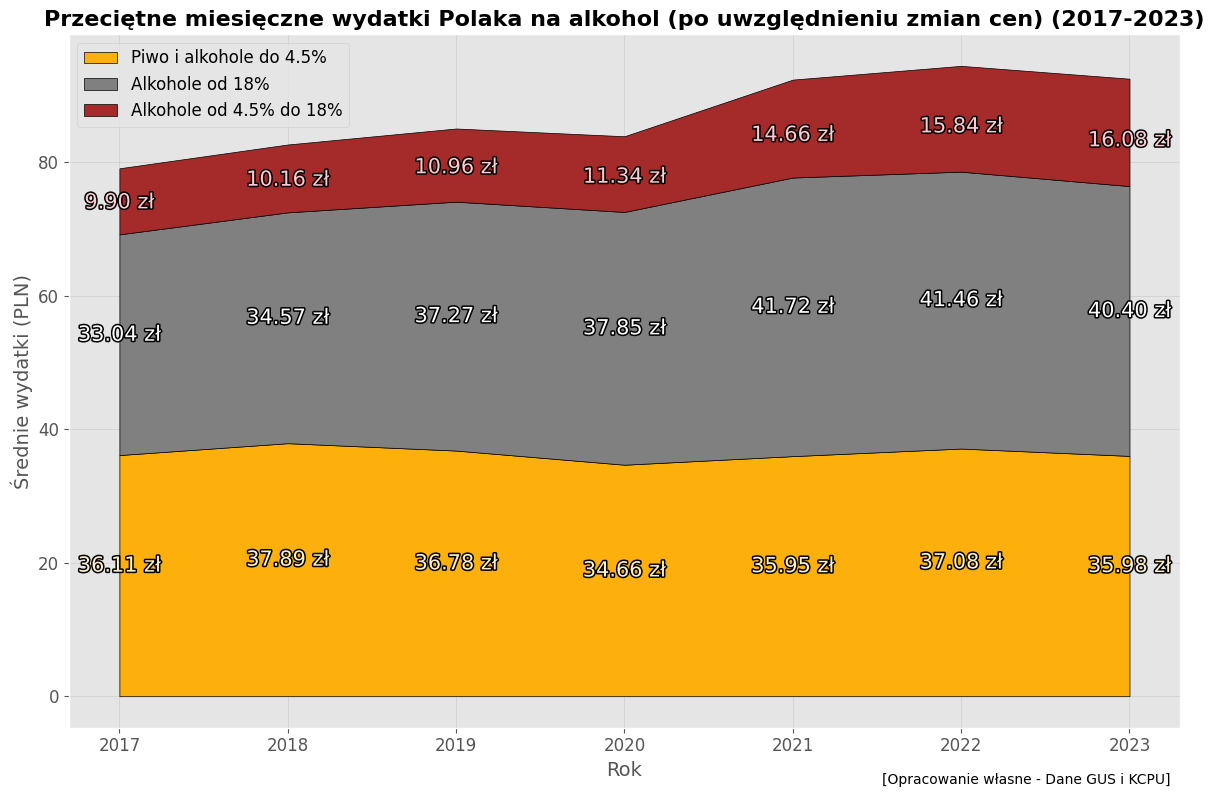

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


years = list(range(2017, 2024))

# Dane dla alkoholi w latach 2017-2023
prices_beer = [df2['piwo jasne pełne, butelkowane - za 0,5l', str(year), '[zł]']['POLSKA'] for year in years]
prices_vodka = [df2['wódka czysta 40% - za 0,5l', str(year), '[zł]']['POLSKA'] for year in years]
prices_wine = [
    df2['wino białe gronowe - za 0,75l', str(year), '[zł]']['POLSKA']
    if year >= 2021 else df2['wino białe gronowe, wytrawne - za 0,75l', str(year), '[zł]']['POLSKA']
    for year in years
]

# Przekształcenie na wartości liczbowe
prices_beer = pd.to_numeric(prices_beer, errors='coerce')
prices_vodka = pd.to_numeric(prices_vodka, errors='coerce')
prices_wine = pd.to_numeric(prices_wine, errors='coerce')

# Obliczenie procentowych zmian cen
change_beer = prices_beer / prices_beer[0]  # 2017 = 1.0
change_vodka = prices_vodka / prices_vodka[0]  # 2017 = 1.0
change_wine = prices_wine / prices_wine[0]  # 2017 = 1.0

# Wydatki Polaków na alkohol w 2017-2023 (przykład na podstawie danych z tabel)
miesiac_data = pd.DataFrame(index=years, columns=['PIWA I ALKOHOLE DO 4.5%', 'ALKOHOLE OD 4.5% DO 18%', 'ALKOHOLE OD 18%'])
for year in years:
    total_population = df_ludnosc[str(year)]['POLSKA'] * 1000  # Wartości w tysiącach

    miesiac_data.at[year, 'PIWA I ALKOHOLE DO 4.5%'] = tables_parpa[str(year)][2].iloc[:, 1][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 4.5% DO 18%'] = tables_parpa[str(year)][2].iloc[:, 2][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 18%'] = tables_parpa[str(year)][2].iloc[:, 3][16] / (12 * total_population)

# Konwersja danych na liczby
miesiac_data = miesiac_data.apply(pd.to_numeric, errors='coerce')

# Przypisanie danych do odpowiednich kategorii
piwo = miesiac_data['PIWA I ALKOHOLE DO 4.5%'].values
wodka = miesiac_data['ALKOHOLE OD 18%'].values
wino = miesiac_data['ALKOHOLE OD 4.5% DO 18%'].values

# Obliczenie wydatków po uwzględnieniu zmian cen
piwo_change = piwo / change_beer
wodka_change = wodka / change_vodka
wino_change = wino / change_wine

# Tworzenie wykresu
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 8))

# Rysowanie obszarów
ax.fill_between(years, 0, piwo_change, color='#fdb00b', edgecolor='black', alpha=1.0, label='Piwo i alkohole do 4.5%')
ax.fill_between(years, piwo_change, piwo_change + wodka_change, color='gray', edgecolor='black', alpha=1.0, label='Alkohole od 18%')
ax.fill_between(years, piwo_change + wodka_change, piwo_change + wodka_change + wino_change, color='brown', edgecolor='black', alpha=1.0, label='Alkohole od 4.5% do 18%')

# Dodanie wartości nad liniami
for x, y in zip(years, piwo_change):
    ax.text(
        x, y/2, f"{y:.2f} zł",
        color='#ffefca', fontsize=15, ha='center', va='bottom',
        path_effects=[pe.withStroke(linewidth=2.2, foreground='black')]
    )

for x, y_p, y_w in zip(years, piwo_change, wodka_change):
    ax.text(
        x, y_p + y_w/2, f"{y_w:.2f} zł",
        color='white', fontsize=15, ha='center', va='bottom',
        path_effects=[pe.withStroke(linewidth=2.2, foreground='black')]
    )

for x, y_pw, y_wi in zip(years, piwo_change + wodka_change, wino_change):
    ax.text(
        x, y_pw + y_wi/3, f"{y_wi:.2f} zł",
        color='#ffcbd1', fontsize=15, ha='center', va='bottom',
        path_effects=[pe.withStroke(linewidth=2.2, foreground='black')]
    )

# Dostosowanie osi
ax.set_title('Przeciętne miesięczne wydatki Polaka na alkohol (po uwzględnieniu zmian cen) (2017-2023)', fontsize=16, weight='bold')
ax.set_xlabel('Rok', fontsize=14)
ax.set_ylabel('Średnie wydatki (PLN)', fontsize=14)
ax.set_xticks(years)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Siatka
ax.grid(visible=True, linestyle='-', linewidth=0.5, color='black', alpha=0.1)

# Dodanie legendy
ax.legend(loc='upper left', fontsize=12)

# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.98, 0.01, '[Opracowanie własne - Dane GUS i KCPU]', ha='right', va='bottom', fontsize=10)

# Wyświetlenie wykresu
plt.tight_layout()
plt.show()


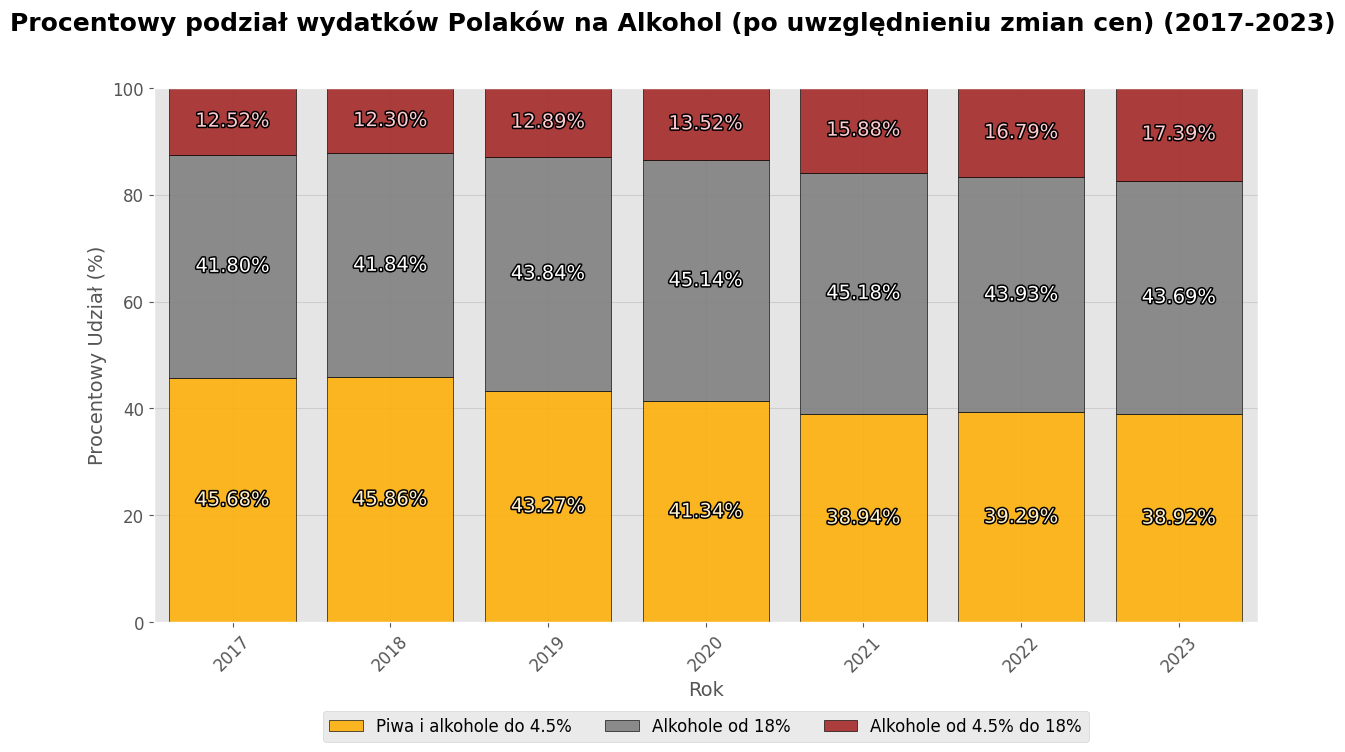

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Dane dla alkoholi w latach 2017-2023
years = list(range(2017, 2024))

# Zakładając, że masz dane już załadowane do zmiennych df2, df_ludnosc i tables_parpa
# Ceny alkoholi (po przekształceniu na wartości liczbowe)
prices_beer = [df2['piwo jasne pełne, butelkowane - za 0,5l', str(year), '[zł]']['POLSKA'] for year in years]
prices_vodka = [df2['wódka czysta 40% - za 0,5l', str(year), '[zł]']['POLSKA'] for year in years]
prices_wine = [
    df2['wino białe gronowe - za 0,75l', str(year), '[zł]']['POLSKA']
    if year >= 2021 else df2['wino białe gronowe, wytrawne - za 0,75l', str(year), '[zł]']['POLSKA']
    for year in years
]

# Przekształcenie cen na wartości liczbowe
prices_beer = pd.to_numeric(prices_beer, errors='coerce')
prices_vodka = pd.to_numeric(prices_vodka, errors='coerce')
prices_wine = pd.to_numeric(prices_wine, errors='coerce')

# Obliczenie procentowych zmian cen względem roku 2017
change_beer = prices_beer / prices_beer[0]  # 2017 = 1.0
change_vodka = prices_vodka / prices_vodka[0]  # 2017 = 1.0
change_wine = prices_wine / prices_wine[0]  # 2017 = 1.0

# Wydatki Polaków na alkohol w latach 2017-2023 (przykład na podstawie danych z tabel)
miesiac_data = pd.DataFrame(index=years, columns=['PIWA I ALKOHOLE DO 4.5%', 'ALKOHOLE OD 4.5% DO 18%', 'ALKOHOLE OD 18%'])
for year in years:
    total_population = df_ludnosc[str(year)]['POLSKA'] * 1000  # Wartości w tysiącach

    miesiac_data.at[year, 'PIWA I ALKOHOLE DO 4.5%'] = tables_parpa[str(year)][2].iloc[:, 1][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 4.5% DO 18%'] = tables_parpa[str(year)][2].iloc[:, 2][16] / (12 * total_population)
    miesiac_data.at[year, 'ALKOHOLE OD 18%'] = tables_parpa[str(year)][2].iloc[:, 3][16] / (12 * total_population)

# Konwersja danych na liczby
miesiac_data = miesiac_data.apply(pd.to_numeric, errors='coerce')

# Przygotowanie danych
piwo = miesiac_data['PIWA I ALKOHOLE DO 4.5%'].values
wodka = miesiac_data['ALKOHOLE OD 18%'].values
wino = miesiac_data['ALKOHOLE OD 4.5% DO 18%'].values

# Obliczenie wydatków po uwzględnieniu zmian cen
piwo_change = piwo / change_beer
wodka_change = wodka / change_vodka
wino_change = wino / change_wine

# Obliczanie procentowych udziałów w wydatkach
total_spending = piwo_change + wodka_change + wino_change
pct_beer = (piwo_change / total_spending) * 100
pct_medium = (wino_change / total_spending) * 100
pct_strong = (wodka_change / total_spending) * 100

# Przygotowanie danych do wykresu
data = {
    'Piwa i alkohole do 4.5%': pct_beer,
    'Alkohole od 18%': pct_strong,
    'Alkohole od 4.5% do 18%': pct_medium
}
df = pd.DataFrame(data, index=years)

# Tworzenie wykresu kolumnowego
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Procentowy podział wydatków Polaków na Alkohol (po uwzględnieniu zmian cen) (2017-2023)', fontsize=18, fontweight='bold', color='black', y=0.95)

# Tworzenie stosowanych kolumn
colors = ['#fdb00b', 'gray', 'brown']
bottom = np.zeros(len(years))
for idx, (label, color) in enumerate(zip(data.keys(), colors)):
    values = df[label].values
    ax.bar(years, values, bottom=bottom, label=label, color=color, edgecolor='black', alpha=0.9)
    bottom += values

# Dodanie wartości nad kolumnami
for year in years:
    total = 0
    for label, color in zip(data.keys(), colors):
        value = df.at[year, label]
        text_color = '#ffefca' if label == 'Piwa i alkohole do 4.5%' else ('white' if label == 'Alkohole od 18%' else '#ffcbd1')
        ax.text(
            year, total + value / 2, f"{value:.2f}%",
            color=text_color, fontsize=14, ha='center', va='center',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='black')]
        )
        total += value

# Ustawienia osi
ax.set_xlabel('Rok', fontsize=14)
ax.set_ylabel('Procentowy Udział (%)', fontsize=14)
ax.set_xlim([2016.5, 2023.5])
ax.set_ylim([0, 100])
ax.set_xticks(years)
ax.set_xticklabels(years, fontsize=12, rotation=45)
ax.tick_params(axis='y', labelsize=12)
ax.grid(visible=True, linestyle='-', color='black', alpha=0.1)

# Legenda
ax.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# Zapis i wyświetlenie wykresu
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('procentowy_udzial_wydatkow_na_alkohol_zmiana_cen.png', dpi=300)
plt.show()


In [ ]:
import eurostat

# Lista kodów tabel z Eurostatu
data_codes = [
    "hlth_ehis_al1e", "hlth_ehis_al1i", "hlth_ehis_al1u", "hlth_ehis_al3e",
    "hlth_ehis_al3i", "hlth_ehis_al3u", "hlth_ehis_al2e", "hlth_ehis_al2i",
    "hlth_ehis_al2u", "hlth_ehis_al1b", "hlth_ehis_al1c", "hlth_ehis_de1"  # Dodano kod BMI
]

# Słownik do przechowywania danych
db = {}

# Pobieranie danych
for code in data_codes:
    try:
        data = eurostat.get_data_df(code)
        db[code] = data
        print(f"Dane dla {code} zostały pomyślnie pobrane.")
    except Exception as e:
        print(f"Nie udało się pobrać danych dla {code}: {e}")

# Testowanie - wyświetlanie danych dla konkretnej tabeli
print(db["hlth_ehis_al2e"])


Dane dla hlth_ehis_al1e zostały pomyślnie pobrane.
Dane dla hlth_ehis_al1i zostały pomyślnie pobrane.
Dane dla hlth_ehis_al1u zostały pomyślnie pobrane.
Dane dla hlth_ehis_al3e zostały pomyślnie pobrane.
Dane dla hlth_ehis_al3i zostały pomyślnie pobrane.
Dane dla hlth_ehis_al3u zostały pomyślnie pobrane.
Dane dla hlth_ehis_al2e zostały pomyślnie pobrane.
Dane dla hlth_ehis_al2i zostały pomyślnie pobrane.
Dane dla hlth_ehis_al2u zostały pomyślnie pobrane.
Dane dla hlth_ehis_al1b zostały pomyślnie pobrane.
Dane dla hlth_ehis_al1c zostały pomyślnie pobrane.
Dane dla hlth_ehis_de1 zostały pomyślnie pobrane.
     freq unit isced11 sex     age geo\TIME_PERIOD  2014
0       A   PC   ED0-2   F   TOTAL              AT   0.5
1       A   PC   ED0-2   F   TOTAL              BE   1.8
2       A   PC   ED0-2   F   TOTAL              BG   0.5
3       A   PC   ED0-2   F   TOTAL              CY   0.2
4       A   PC   ED0-2   F   TOTAL              CZ   1.2
...   ...  ...     ...  ..     ...             

In [ ]:
# Testowanie - wyświetlanie danych dla konkretnej tabeli
print(db["hlth_ehis_al1e"])


      freq unit frequenc isced11 sex     age geo\TIME_PERIOD  2014  2019
0        A   PC      DAY   ED0-2   F   TOTAL              AT   2.0   2.3
1        A   PC      DAY   ED0-2   F   TOTAL              BE   7.5   4.0
2        A   PC      DAY   ED0-2   F   TOTAL              BG   1.3   2.8
3        A   PC      DAY   ED0-2   F   TOTAL              CY   0.6   0.1
4        A   PC      DAY   ED0-2   F   TOTAL              CZ   2.5   1.7
...    ...  ...      ...     ...  ..     ...             ...   ...   ...
56611    A   PC     WEEK   TOTAL   T  Y_GE75              SE  27.8  30.2
56612    A   PC     WEEK   TOTAL   T  Y_GE75              SI  19.9  15.0
56613    A   PC     WEEK   TOTAL   T  Y_GE75              SK   5.9   8.8
56614    A   PC     WEEK   TOTAL   T  Y_GE75              TR   0.3   0.4
56615    A   PC     WEEK   TOTAL   T  Y_GE75              UK  29.6   NaN

[56616 rows x 9 columns]


In [ ]:
print(db["hlth_ehis_al1e"][
        (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL')
        &
        (db["hlth_ehis_al1e"]['age'] == 'TOTAL')
        #&
        #(db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
        &
        (db["hlth_ehis_al1e"]['sex'] == 'T')
].head(50))


      freq unit frequenc isced11 sex    age geo\TIME_PERIOD  2014  2019
7414     A   PC      DAY   TOTAL   T  TOTAL              AT   6.2   5.7
7415     A   PC      DAY   TOTAL   T  TOTAL              BE  14.2   9.7
7416     A   PC      DAY   TOTAL   T  TOTAL              BG   8.9  10.2
7417     A   PC      DAY   TOTAL   T  TOTAL              CY   4.2   4.0
7418     A   PC      DAY   TOTAL   T  TOTAL              CZ   9.5   7.8
7419     A   PC      DAY   TOTAL   T  TOTAL              DE   9.3   7.5
7420     A   PC      DAY   TOTAL   T  TOTAL              DK  11.3   9.6
7421     A   PC      DAY   TOTAL   T  TOTAL              EE   2.0   1.3
7422     A   PC      DAY   TOTAL   T  TOTAL              EL   6.9   5.9
7423     A   PC      DAY   TOTAL   T  TOTAL              ES  15.3  13.0
7424     A   PC      DAY   TOTAL   T  TOTAL       EU27_2020   9.5   8.4
7425     A   PC      DAY   TOTAL   T  TOTAL            EU28   9.2   NaN
7426     A   PC      DAY   TOTAL   T  TOTAL              FI   2.

In [ ]:
print(db["hlth_ehis_al1e"][
        (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK')
        &
        (db["hlth_ehis_al1e"]['age'] == 'TOTAL')
       &
        (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
        &
        (db["hlth_ehis_al1e"]['sex'] == 'T')
])

      freq unit frequenc isced11 sex    age geo\TIME_PERIOD  2014  2019
49901    A   PC     WEEK   ED0-2   T  TOTAL              PL   7.4   8.8
51923    A   PC     WEEK   ED3_4   T  TOTAL              PL  16.2  17.2
53945    A   PC     WEEK   ED5-8   T  TOTAL              PL  22.4  20.5
55967    A   PC     WEEK   TOTAL   T  TOTAL              PL  16.0  16.8


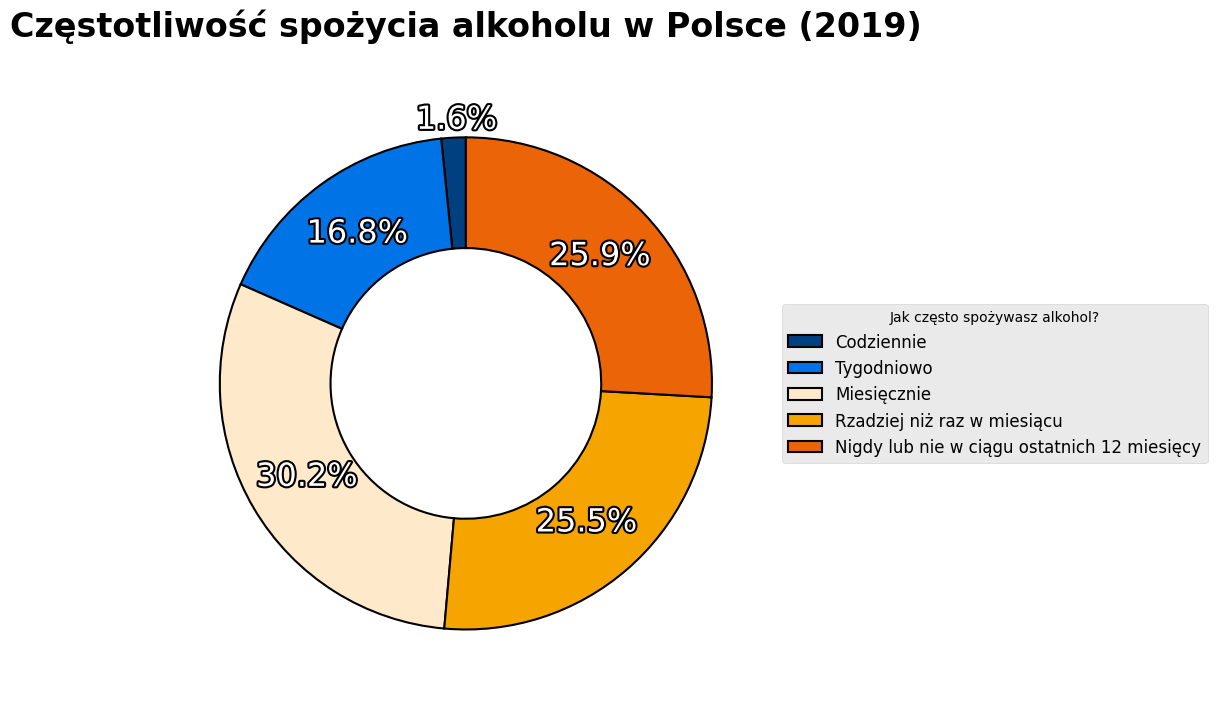

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Filtracja danych z bazy danych
data = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['age'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
    & (db["hlth_ehis_al1e"]['sex'] == 'T')
].copy()

# Mapa tłumaczenia częstotliwości picia alkoholu na język polski
frequency_map = {
    'DAY': 'Codziennie',
    'WEEK': 'Tygodniowo',
    'MTH': 'Miesięcznie',
    'LT1M': 'Rzadziej niż raz w miesiącu',
    'NVR_NM12': 'Nigdy lub nie w ciągu ostatnich 12 miesięcy'
}

# Tłumaczenie nazw kategorii
data['frequenc_description'] = data['frequenc'].map(frequency_map)

# Grupowanie danych dla roku 2019
frequency_data = data.groupby('frequenc_description')['2019'].sum()

# Kolejność kategorii
desired_order = ['Codziennie', 'Tygodniowo', 'Miesięcznie', 'Rzadziej niż raz w miesiącu', 'Nigdy lub nie w ciągu ostatnich 12 miesięcy']
frequency_data = frequency_data.reindex(desired_order)

# Tworzenie pierścieniowego wykresu
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 8))

# Definiowanie kolorów
colors = ['#004080', '#0073e6', '#feeaca', '#f6a500', '#eb6508']

# Rysowanie pierścieniowego wykresu z grubszymi konturami
wedges, _ = ax.pie(frequency_data, labels=None, startangle=90,
                   colors=colors, wedgeprops=dict(width=0.45, edgecolor='black', linewidth=1.5))

# Dodanie wartości procentowych na środku każdego segmentu pierścienia
for wedge, value, label in zip(wedges, frequency_data, frequency_data.index):
    angle = (wedge.theta2 + wedge.theta1) / 2  # Środek segmentu
    x = 0.75 * np.cos(np.deg2rad(angle))  # Współrzędne na środku segmentu pierścienia
    y = 0.75 * np.sin(np.deg2rad(angle))

    # Dla "Codziennie" ustawiamy tekst nad pierścieniem
    if label == 'Codziennie':
        y += 0.32  # Przesunięcie w górę dla "Codziennie"

    ax.text(
        x, y, f"{value:.1f}%",
        ha='center', va='center', fontsize=23, color='white',
        path_effects=[pe.withStroke(linewidth=3, foreground='black')]  # Zwiększenie grubości konturu tekstu
    )

# Tytuł wykresu
ax.set_title('Częstotliwość spożycia alkoholu w Polsce (2019)', fontsize=24, fontweight='bold', y=1.05)

# Dodanie legendy
ax.legend(wedges, frequency_data.index, title="Jak często spożywasz alkohol?", loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12)

# Dostosowanie wyglądu
plt.tight_layout()
plt.show()


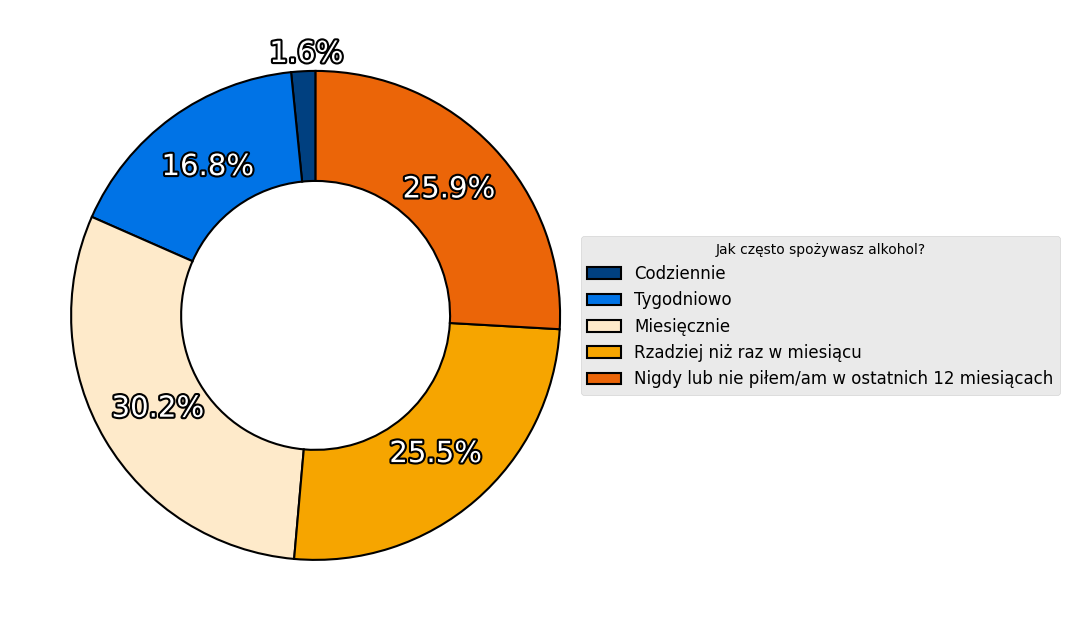

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Filtracja danych z bazy danych
data = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['age'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
    & (db["hlth_ehis_al1e"]['sex'] == 'T')
].copy()

# Mapa tłumaczenia częstotliwości picia alkoholu na język polski
frequency_map = {
    'DAY': 'Codziennie',
    'WEEK': 'Tygodniowo',
    'MTH': 'Miesięcznie',
    'LT1M': 'Rzadziej niż raz w miesiącu',
    'NVR_NM12': 'Nigdy lub nie piłem/am w ostatnich 12 miesiącach'
}

# Tłumaczenie nazw kategorii
data['frequenc_description'] = data['frequenc'].map(frequency_map)

# Grupowanie danych dla roku 2019
frequency_data = data.groupby('frequenc_description')['2019'].sum()

# Kolejność kategorii
desired_order = ['Codziennie', 'Tygodniowo', 'Miesięcznie', 'Rzadziej niż raz w miesiącu', 'Nigdy lub nie piłem/am w ostatnich 12 miesiącach']
frequency_data = frequency_data.reindex(desired_order)

# Tworzenie pierścieniowego wykresu
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 8))

# Definiowanie kolorów
colors = ['#004080', '#0073e6', '#feeaca', '#f6a500', '#eb6508']

# Rysowanie pierścieniowego wykresu z grubszymi konturami
wedges, _ = ax.pie(frequency_data, labels=None, startangle=90,
                   colors=colors, wedgeprops=dict(width=0.45, edgecolor='black', linewidth=1.5))

# Dodanie wartości procentowych na środku każdego segmentu pierścienia
for wedge, value, label in zip(wedges, frequency_data, frequency_data.index):
    angle = (wedge.theta2 + wedge.theta1) / 2  # Środek segmentu
    x = 0.75 * np.cos(np.deg2rad(angle))  # Współrzędne na środku segmentu pierścienia
    y = 0.75 * np.sin(np.deg2rad(angle))

    # Dla "Codziennie" ustawiamy tekst nad pierścieniem
    if label == 'Codziennie':
        y += 0.32  # Przesunięcie w górę dla "Codziennie"

    ax.text(
        x, y, f"{value:.1f}%",
        ha='center', va='center', fontsize=21, color='white',
        path_effects=[pe.withStroke(linewidth=3, foreground='black')]  # Zwiększenie grubości konturu tekstu
    )


# Dodanie legendy
ax.legend(wedges, frequency_data.index, title="Jak często spożywasz alkohol?", loc="center left", bbox_to_anchor=(0.92, 0.5), fontsize=12)

# Dostosowanie wyglądu
plt.tight_layout()
plt.show()


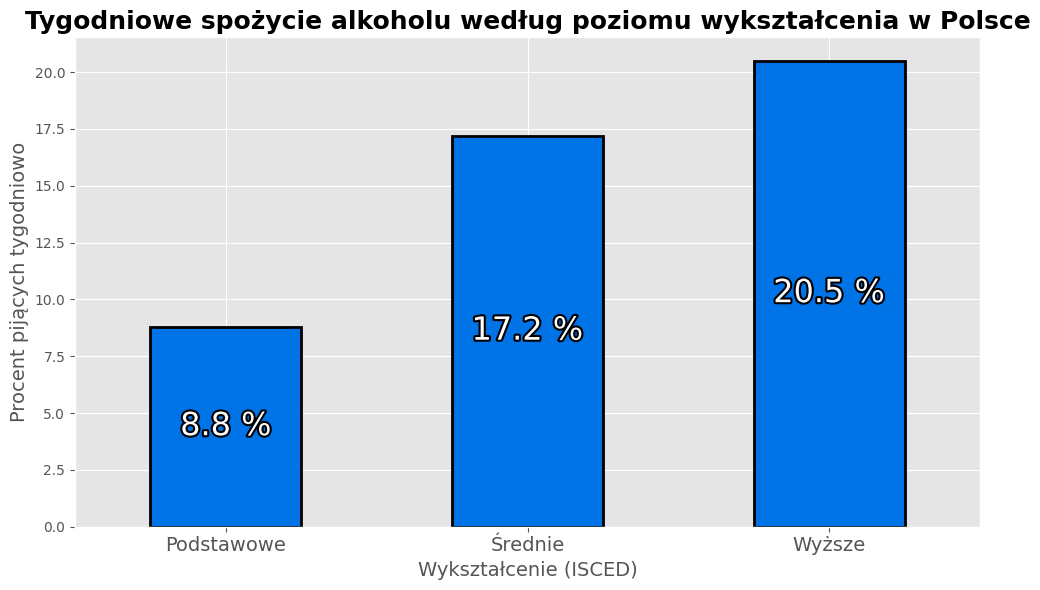

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Filtracja danych: tylko osoby pijące codziennie, wykluczając 'TOTAL' w 'isced11'
data = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK')
    & (db["hlth_ehis_al1e"]['age'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
    & (db["hlth_ehis_al1e"]['sex'] == 'T')
    & (db["hlth_ehis_al1e"]['isced11'] != 'TOTAL')  # Wykluczamy 'TOTAL' z poziomu wykształcenia
].copy()

# Grupowanie danych według poziomu wykształcenia (sumowanie wartości dla 2019)
education_data = data.groupby('isced11')['2019'].sum()

# Zmiana etykiet na poziomie wykształcenia przy użyciu map
education_data.index = education_data.index.map({
    'ED0-2': 'Podstawowe',
    'ED3_4': 'Średnie',
    'ED5-8': 'Wyższe'
})

# Tworzenie wykresu słupkowego
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))

# Rysowanie wykresu słupkowego
bars = education_data.plot(kind='bar', color='#0073e6', ax=ax, edgecolor='black', linewidth=2)

# Dodanie tytułu i etykiet osi
ax.set_title('Tygodniowe spożycie alkoholu według poziomu wykształcenia w Polsce', fontsize=18, fontweight='bold')
ax.set_xlabel('Wykształcenie (ISCED)', fontsize=14)
ax.set_ylabel('Procent pijących tygodniowo', fontsize=14)

# Ustawienie poziomych etykiet osi X
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=14)

# Dodanie wartości na słupkach, z białym tekstem na czarnym tle z konturem
for i, value in enumerate(education_data):
    bar = bars.patches[i]  # Słupki wykresu
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height / 2, f'{value:.1f} %',  # Wartości w środku słupków
        ha='center', va='center', fontsize=23, color='white',
        path_effects=[pe.withStroke(linewidth=3, foreground='black')]  # Kontur tekstu
    )

# Dostosowanie wyglądu wykresu
plt.tight_layout()
plt.show()

In [ ]:
print(db["hlth_ehis_al1e"][
        (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL')
        &
        (db["hlth_ehis_al1e"]['age'] == 'TOTAL')
        &
        (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
        &
        (db["hlth_ehis_al1e"]['frequenc'] == 'DAY')
])

     freq unit frequenc isced11 sex    age geo\TIME_PERIOD  2014  2019
6091    A   PC      DAY   TOTAL   F  TOTAL              PL   0.4   0.2
6765    A   PC      DAY   TOTAL   M  TOTAL              PL   3.6   3.0
7439    A   PC      DAY   TOTAL   T  TOTAL              PL   1.8   1.6


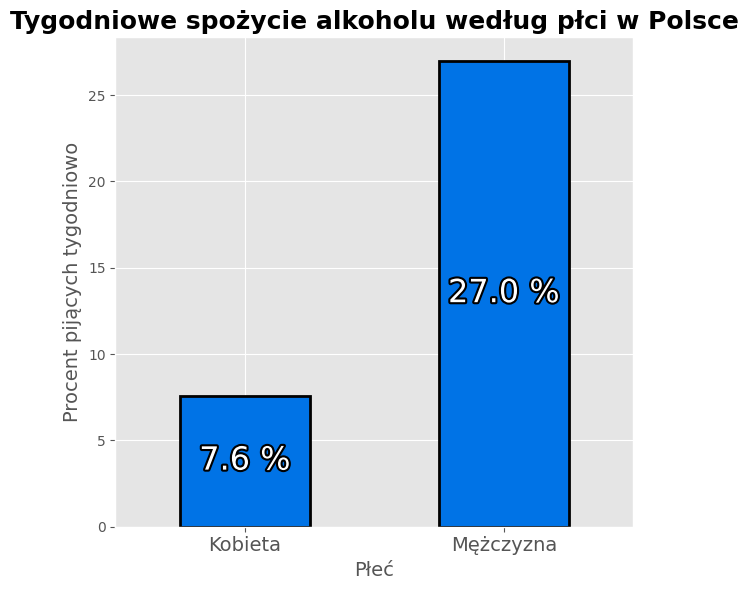

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

# Filtracja danych: tylko osoby pijące codziennie, wykluczając 'T' (TOTAL) w kolumnie 'sex'
data = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['age'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
    & (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK')
    & (db["hlth_ehis_al1e"]['sex'] != 'T')  # Wykluczamy 'T' - TOTAL z płci
].copy()

# Przetłumaczenie wartości w kolumnie 'sex'
data['sex'] = data['sex'].replace({'F': 'Kobieta', 'M': 'Mężczyzna'})

# Grupowanie danych według płci (sumowanie wartości dla 2019)
gender_data = data.groupby('sex')['2019'].sum()

# Tworzenie wykresu słupkowego
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(6, 6))

# Rysowanie wykresu słupkowego
bars = gender_data.plot(kind='bar', color='#0073e6', ax=ax, edgecolor='black', linewidth=2)

# Dodanie tytułu i etykiet osi
ax.set_title('Tygodniowe spożycie alkoholu według płci w Polsce', fontsize=18, fontweight='bold')
ax.set_xlabel('Płeć', fontsize=14)
ax.set_ylabel('Procent pijących tygodniowo', fontsize=14)

# Ustawienie poziomych etykiet osi X
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=14)

# Dodanie wartości na słupkach, z białym tekstem na czarnym tle z konturem
for i, value in enumerate(gender_data):
    bar = bars.patches[i]  # Słupki wykresu
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2, height / 2, f'{value:.1f} %',  # Wartości w środku słupka
        ha='center', va='center', fontsize=23, color='white',
        path_effects=[pe.withStroke(linewidth=3, foreground='black')]  # Kontur tekstu
    )

# Dostosowanie wyglądu wykresu
plt.tight_layout()
plt.show()


In [ ]:
print(db["hlth_ehis_al1e"][
        (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL')
        &
        (db["hlth_ehis_al1e"]['frequenc'] == 'DAY')
        &
        (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
        &
        (db["hlth_ehis_al1e"]['sex'] == 'T')
])


     freq unit frequenc isced11 sex     age geo\TIME_PERIOD  2014  2019
7439    A   PC      DAY   TOTAL   T   TOTAL              PL   1.8   1.6
7473    A   PC      DAY   TOTAL   T  Y15-19              PL   0.0   0.0
7507    A   PC      DAY   TOTAL   T  Y15-24              PL   0.5   0.1
7541    A   PC      DAY   TOTAL   T  Y15-29              PL   0.6   0.3
7575    A   PC      DAY   TOTAL   T  Y15-64              PL   2.0   1.6
7609    A   PC      DAY   TOTAL   T  Y18-24              PL   0.6   0.1
7641    A   PC      DAY   TOTAL   T  Y18-44              PL   1.5   NaN
7674    A   PC      DAY   TOTAL   T  Y18-64              PL   2.0   1.6
7708    A   PC      DAY   TOTAL   T  Y20-24              PL   0.9   0.2
7742    A   PC      DAY   TOTAL   T  Y25-29              PL   0.8   0.5
7776    A   PC      DAY   TOTAL   T  Y25-34              PL   1.7   1.2
7808    A   PC      DAY   TOTAL   T  Y25-64              PL   2.2   NaN
7841    A   PC      DAY   TOTAL   T  Y35-44              PL   1.

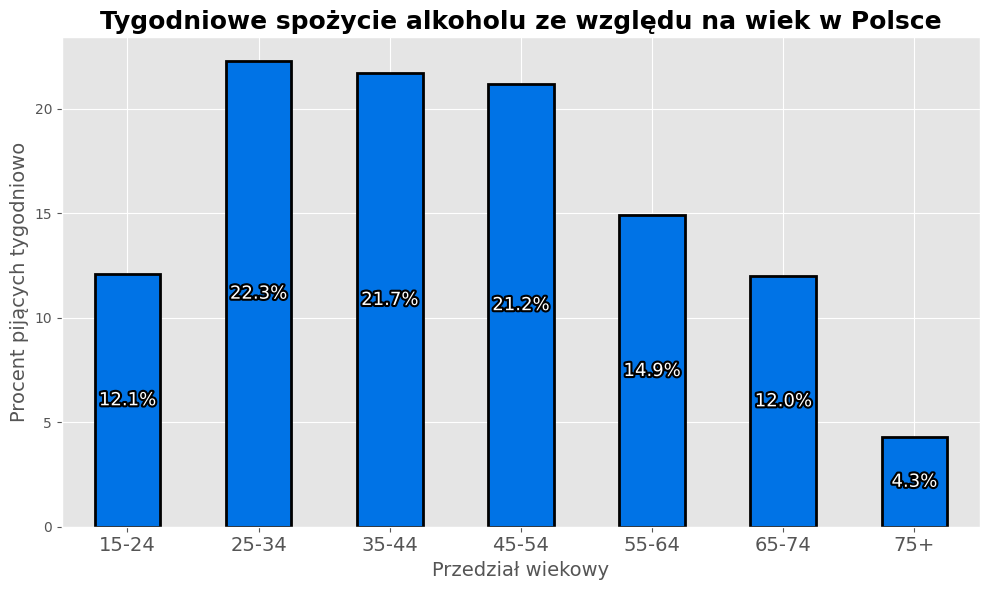

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Filtracja danych: tylko osoby pijące codziennie i dla odpowiednich przedziałów wiekowych
data = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL')
    & (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK')
    & (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL')
    & (db["hlth_ehis_al1e"]['sex'] == 'T')
    & (db["hlth_ehis_al1e"]['age'].isin(['Y15-24', 'Y25-34', 'Y35-44', 'Y45-54', 'Y55-64', 'Y65-74', 'Y_GE75']))
].copy()

# Mapowanie etykiet wiekowych
data['age'] = data['age'].map({
    'Y15-24': '15-24',
    'Y25-34': '25-34',
    'Y35-44': '35-44',
    'Y45-54': '45-54',
    'Y55-64': '55-64',
    'Y65-74': '65-74',
    'Y_GE75': '75+',
})

# Grupowanie danych według przedziałów wiekowych
age_data = data.groupby('age')['2019'].sum()

# Tworzenie wykresu słupkowego
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(10, 6))

# Rysowanie wykresu słupkowego
bars = age_data.plot(kind='bar', color='#0073e6', ax=ax, edgecolor='black', linewidth=2)

# Dodanie tytułu i etykiet osi
ax.set_title('Tygodniowe spożycie alkoholu ze względu na wiek w Polsce', fontsize=18, fontweight='bold')
ax.set_xlabel('Przedział wiekowy', fontsize=14)
ax.set_ylabel('Procent pijących tygodniowo', fontsize=14)

# Ustawienie poziomych etykiet osi X
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=14)

# Dodanie wartości na słupkach
for i, value in enumerate(age_data):
    bar = bars.patches[i]  # Słupki wykresu
    height = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2, height / 2, f'{value:.1f}%',  # Wartości w środku słupka
        ha='center', va='center', fontsize=13, color='white',
        path_effects=[pe.withStroke(linewidth=3, foreground='black')]  # Kontur tekstu
    )

# Dostosowanie wyglądu wykresu
plt.tight_layout()
plt.show()



.

.

.

TRZEBA W RAPORCIE NAPISAC ZE DLATEGO BIORE WEEKLY BO JEST PROBLEM METODOLOGICZNY BADANIA I JEST ALBO DAILY ALBO WEEKLY WIEC JAK COS CO 2 DZIEN PIJE TO JUZ NIE UZNA ZE CODZIENNIE PIJE I DANE Z POLSKI SA MALO MIARODAJNE

.
ale tez trzeba pomyslec jak to dla wyksztalcenia podstawowowego jest tylko 8.8%  dla weekly i 1.5% dla daily


zakladam ze podstawowe jest niereprezentatywne, wiekszosc ludzi z podstawowych coby pili i np byli w menelowniach nie dalo sie do nich dostac poprzez ankiety tego typu, zakladam ze wiekszosc tutaj to sa np starsi ludzie ktorzy nie mogli miec wyzszego wyksztalcenia bo takie byly czasy
.
.
.

.

.

.









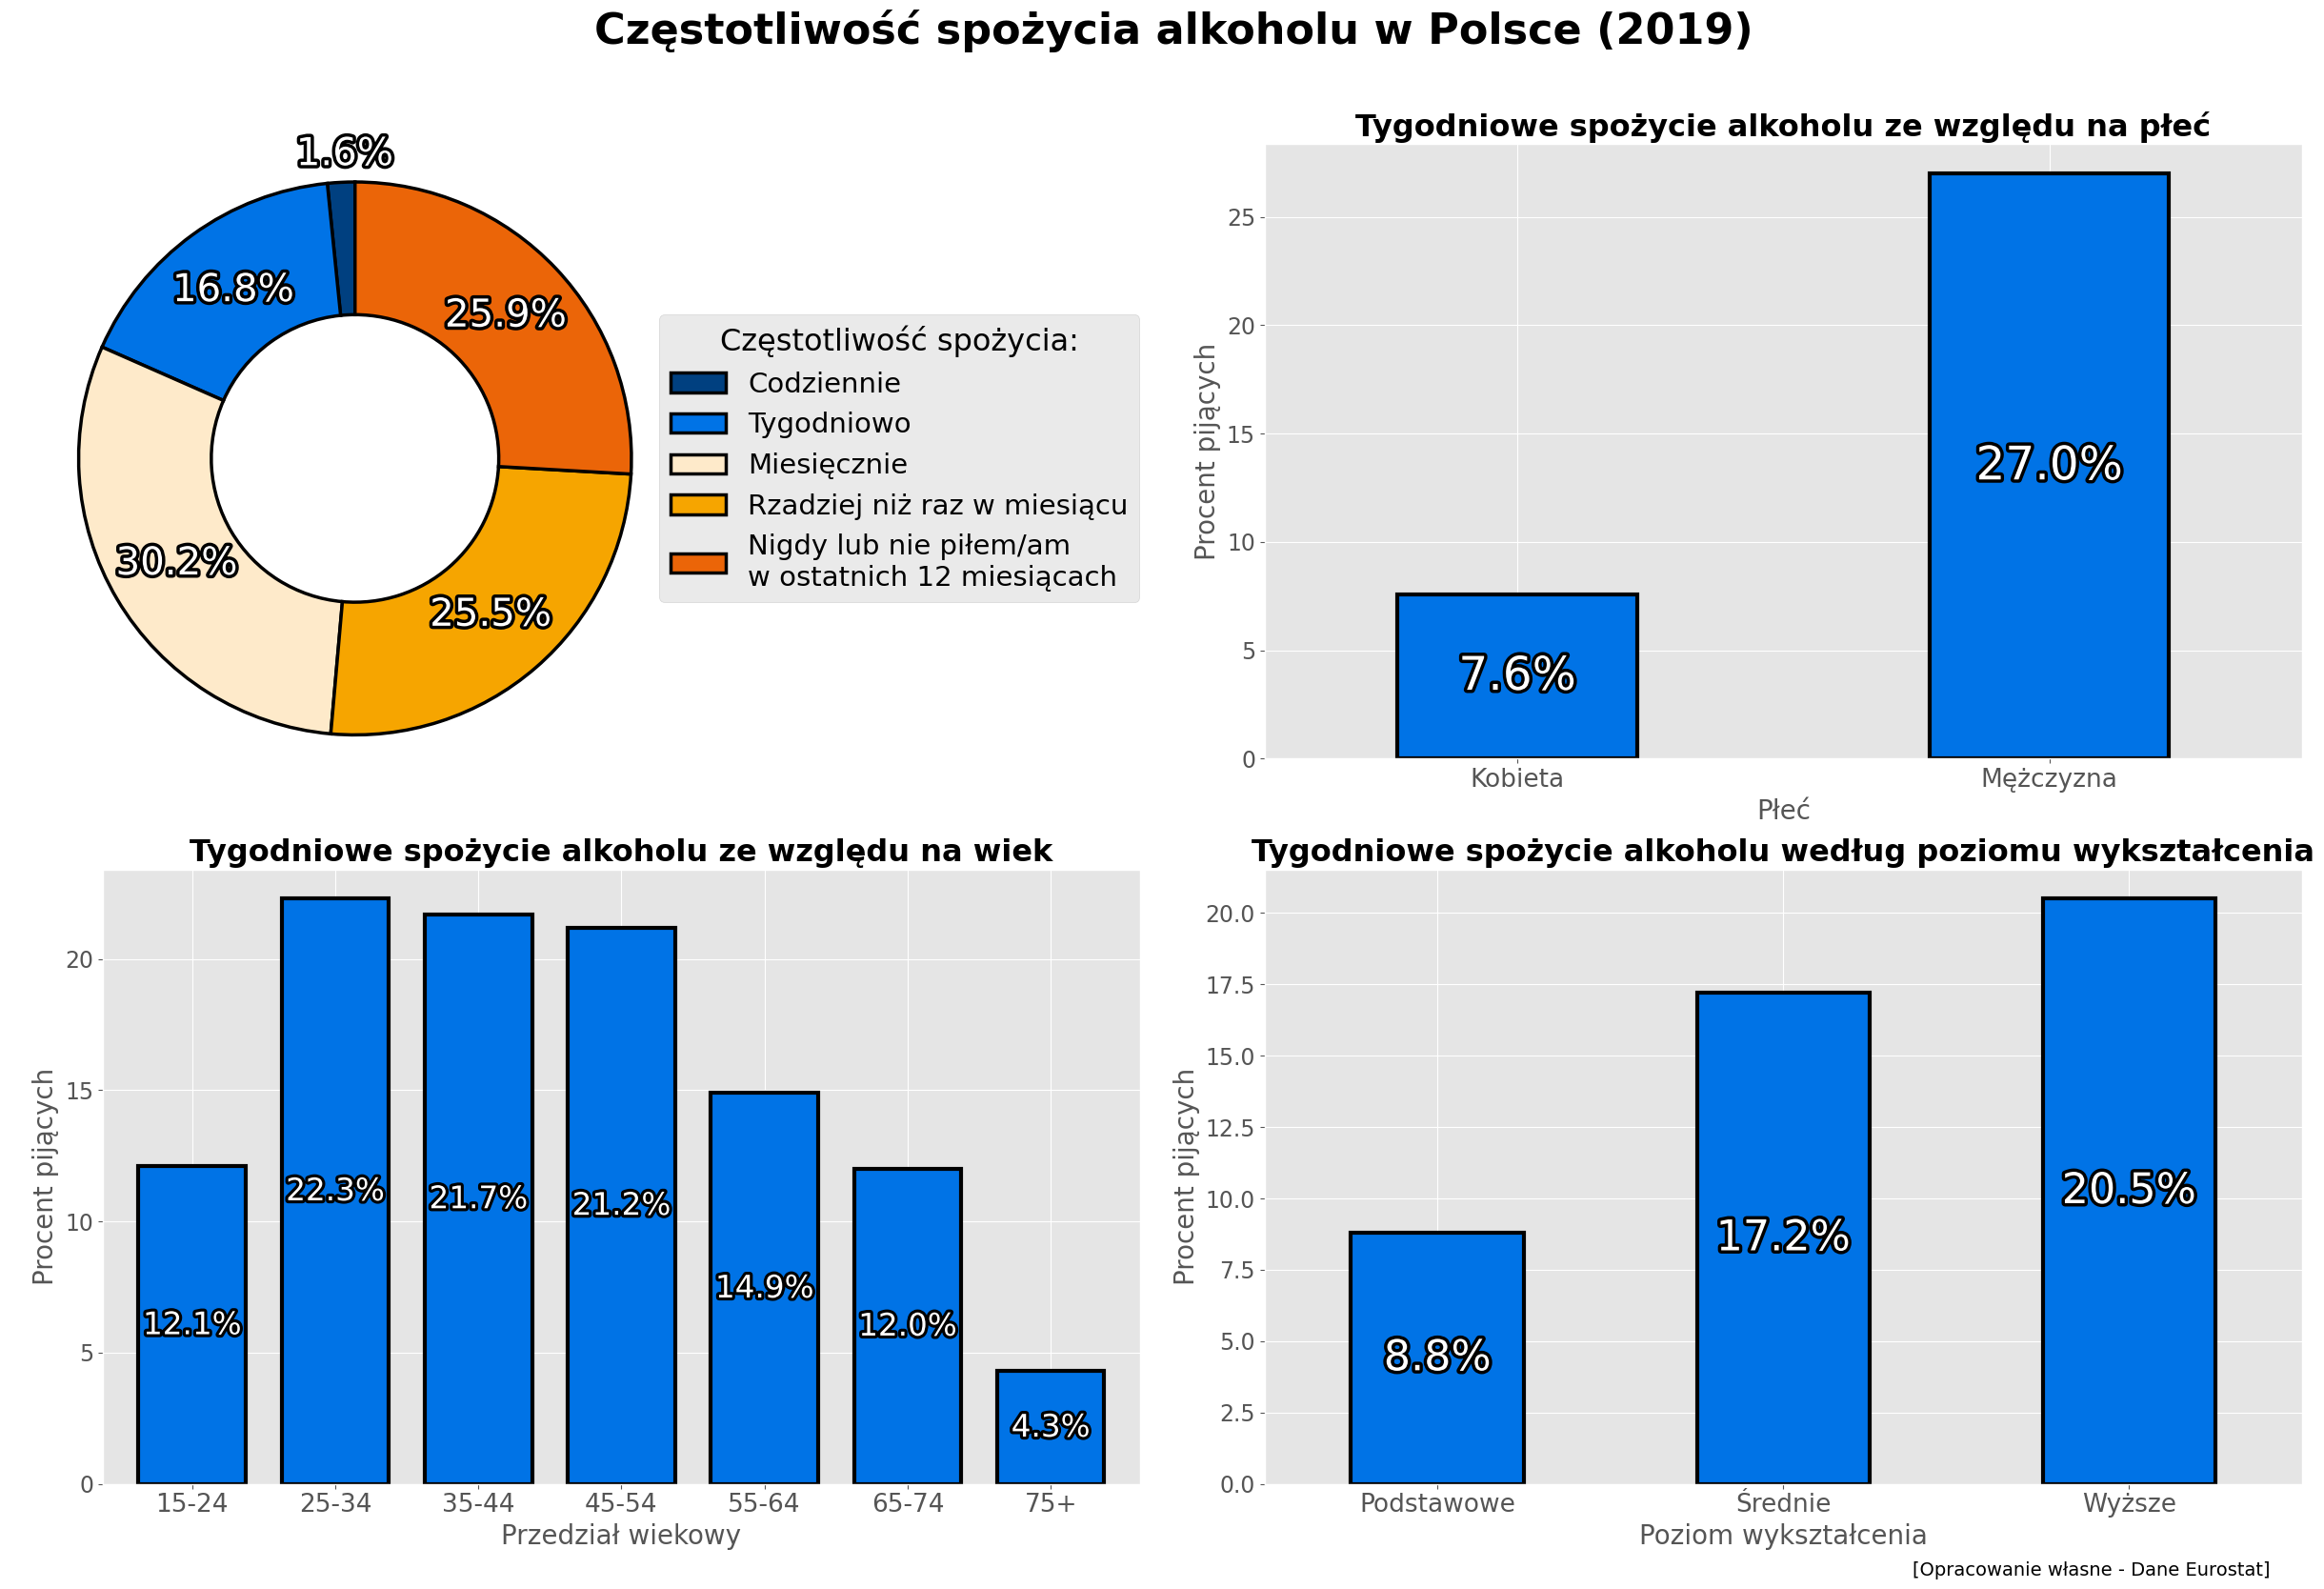

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

plt.style.use('ggplot')

# Utwórz siatkę 2x2 subplotów
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 16))
fig.subplots_adjust(wspace=0.3, hspace=0.4)  # Dodatkowe odstępy między wykresami

# Główny tytuł
fig.suptitle('Częstotliwość spożycia alkoholu w Polsce (2019)',
            fontsize=32, fontweight='bold', y=1.02)

# --------------------- WYKRES 1 (lewy górny) ---------------------
data1 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
].copy()

frequency_map = {
    'DAY': 'Codziennie',
    'WEEK': 'Tygodniowo',
    'MTH': 'Miesięcznie',
    'LT1M': 'Rzadziej niż raz w miesiącu',
    'NVR_NM12': 'Nigdy lub nie piłem/am\nw ostatnich 12 miesiącach'
}

data1['frequenc_description'] = data1['frequenc'].map(frequency_map)
frequency_data1 = data1.groupby('frequenc_description')['2019'].sum().reindex([
    'Codziennie', 'Tygodniowo', 'Miesięcznie', 'Rzadziej niż raz w miesiącu', 'Nigdy lub nie piłem/am\nw ostatnich 12 miesiącach'
])

colors = ['#004080', '#0073e6', '#feeaca', '#f6a500', '#eb6508']
wedges, _ = ax1.pie(frequency_data1, labels=None, startangle=90,
                   colors=colors, wedgeprops=dict(width=0.48, edgecolor='black', linewidth=2.5))

for wedge, value, label in zip(wedges, frequency_data1, frequency_data1.index):
    angle = (wedge.theta2 + wedge.theta1)/2
    x = 0.75 * np.cos(np.deg2rad(angle))
    y = 0.75 * np.sin(np.deg2rad(angle))
    if label == 'Codziennie': y += 0.35
    ax1.text(x, y, f"{value:.1f}%", ha='center', va='center',
            fontsize=29, color='white', path_effects=[pe.withStroke(linewidth=5, foreground='black')])

ax1.legend(wedges, frequency_data1.index, title="Częstotliwość spożycia:", title_fontsize=23,
         loc="center left", bbox_to_anchor=(0.92, 0.5), fontsize=21)

# --------------------- WYKRES 2 (prawy górny) ---------------------
data2 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL') &
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['sex'] != 'T')
].copy()

data2['sex'] = data2['sex'].replace({'F': 'Kobieta', 'M': 'Mężczyzna'})
gender_data2 = data2.groupby('sex')['2019'].sum()

bars2 = gender_data2.plot(kind='bar', color='#0073e6', ax=ax2,
                         edgecolor='black', linewidth=3, width=0.45)
ax2.set_title('Tygodniowe spożycie alkoholu ze względu na płeć', fontsize=23, fontweight='bold')
ax2.set_xlabel('Płeć', fontsize=20)
ax2.set_ylabel('Procent pijących', fontsize=20)
ax2.set_xticklabels(gender_data2.index, rotation=0, fontsize=19)

for i, value in enumerate(gender_data2):
    bar = bars2.patches[i]
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=35, color='white',
            path_effects=[pe.withStroke(linewidth=5, foreground='black')])

# --------------------- WYKRES 3 (lewy dolny) ---------------------
data3 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T') &
    (db["hlth_ehis_al1e"]['age'].isin(['Y15-24', 'Y25-34', 'Y35-44', 'Y45-54', 'Y55-64', 'Y65-74', 'Y_GE75']))
].copy()

data3['age'] = data3['age'].map({
    'Y15-24': '15-24', 'Y25-34': '25-34', 'Y35-44': '35-44',
    'Y45-54': '45-54', 'Y55-64': '55-64', 'Y65-74': '65-74',
    'Y_GE75': '75+'
})

age_data3 = data3.groupby('age')['2019'].sum()

bars3 = age_data3.plot(kind='bar', color='#0073e6', ax=ax3,
                      edgecolor='black', linewidth=3, width=0.75)

ax3.set_title('Tygodniowe spożycie alkoholu ze względu na wiek', fontsize=23, fontweight='bold')
ax3.set_xlabel('Przedział wiekowy', fontsize=20)
ax3.set_ylabel('Procent pijących', fontsize=20)
ax3.set_xticklabels(age_data3.index, rotation=0, fontsize=19)


for i, value in enumerate(age_data3):
    bar = bars3.patches[i]
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=23.5, color='white',
            path_effects=[pe.withStroke(linewidth=4.5, foreground='black')])

# --------------------- WYKRES 4 (prawy dolny) ---------------------
data4 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'PL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T') &
    (db["hlth_ehis_al1e"]['isced11'] != 'TOTAL')
].copy()

education_data4 = data4.groupby('isced11')['2019'].sum()
education_data4.index = education_data4.index.map({
    'ED0-2': 'Podstawowe',
    'ED3_4': 'Średnie',
    'ED5-8': 'Wyższe'
})

bars4 = education_data4.plot(kind='bar', color='#0073e6', ax=ax4,
                            edgecolor='black', linewidth=3)
ax4.set_title('Tygodniowe spożycie alkoholu według poziomu wykształcenia', fontsize=23, fontweight='bold')
ax4.set_xlabel('Poziom wykształcenia', fontsize=20)
ax4.set_ylabel('Procent pijących', fontsize=20)
ax4.set_xticklabels(education_data4.index, rotation=0, fontsize=19)

for i, value in enumerate(education_data4):
    bar = bars4.patches[i]
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=32, color='white',
            path_effects=[pe.withStroke(linewidth=5, foreground='black')])

plt.tight_layout()


#=========================================================================================================================#
# Przesunięcie wykresu 2 w lewo
pos = ax1.get_position()
ax1.set_position([pos.x0 - 0.07, pos.y0, pos.width * 0.9, pos.height])  # Przesunięcie i lekkie zwężenie

plt.tight_layout()

# Przesunięcie wykresu 2 w lewo
pos = ax1.get_position()
ax1.set_position([pos.x0 - 0.03, pos.y0, pos.width * 0.9, pos.height])  # Przesunięcie i lekkie zwężenie

# Na końcu kodu, przed plt.show():
for ax in [ax2, ax3, ax4]:
    ax.tick_params(axis='y', labelsize=17)

# Pobierz aktualną pozycję wykresu
original_pos = ax1.get_position()

fig.subplots_adjust(wspace=0.12, hspace=0.18)

# Zwiększ rozmiar wykresu o 20% i wycentruj
new_width = original_pos.width * 1.25
new_height = original_pos.height * 1.25
ax1.set_position([
    original_pos.x0 - 0.1,  # Przesunięcie w lewo
    original_pos.y0 - 0.05,  # Przesunięcie w dół
    new_width,
    new_height
])

# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.98, -0.01, '[Opracowanie własne - Dane Eurostat]', ha='right', va='bottom', fontsize=14)


plt.show()

In [ ]:
'EU27_2020'

'EU27_2020'

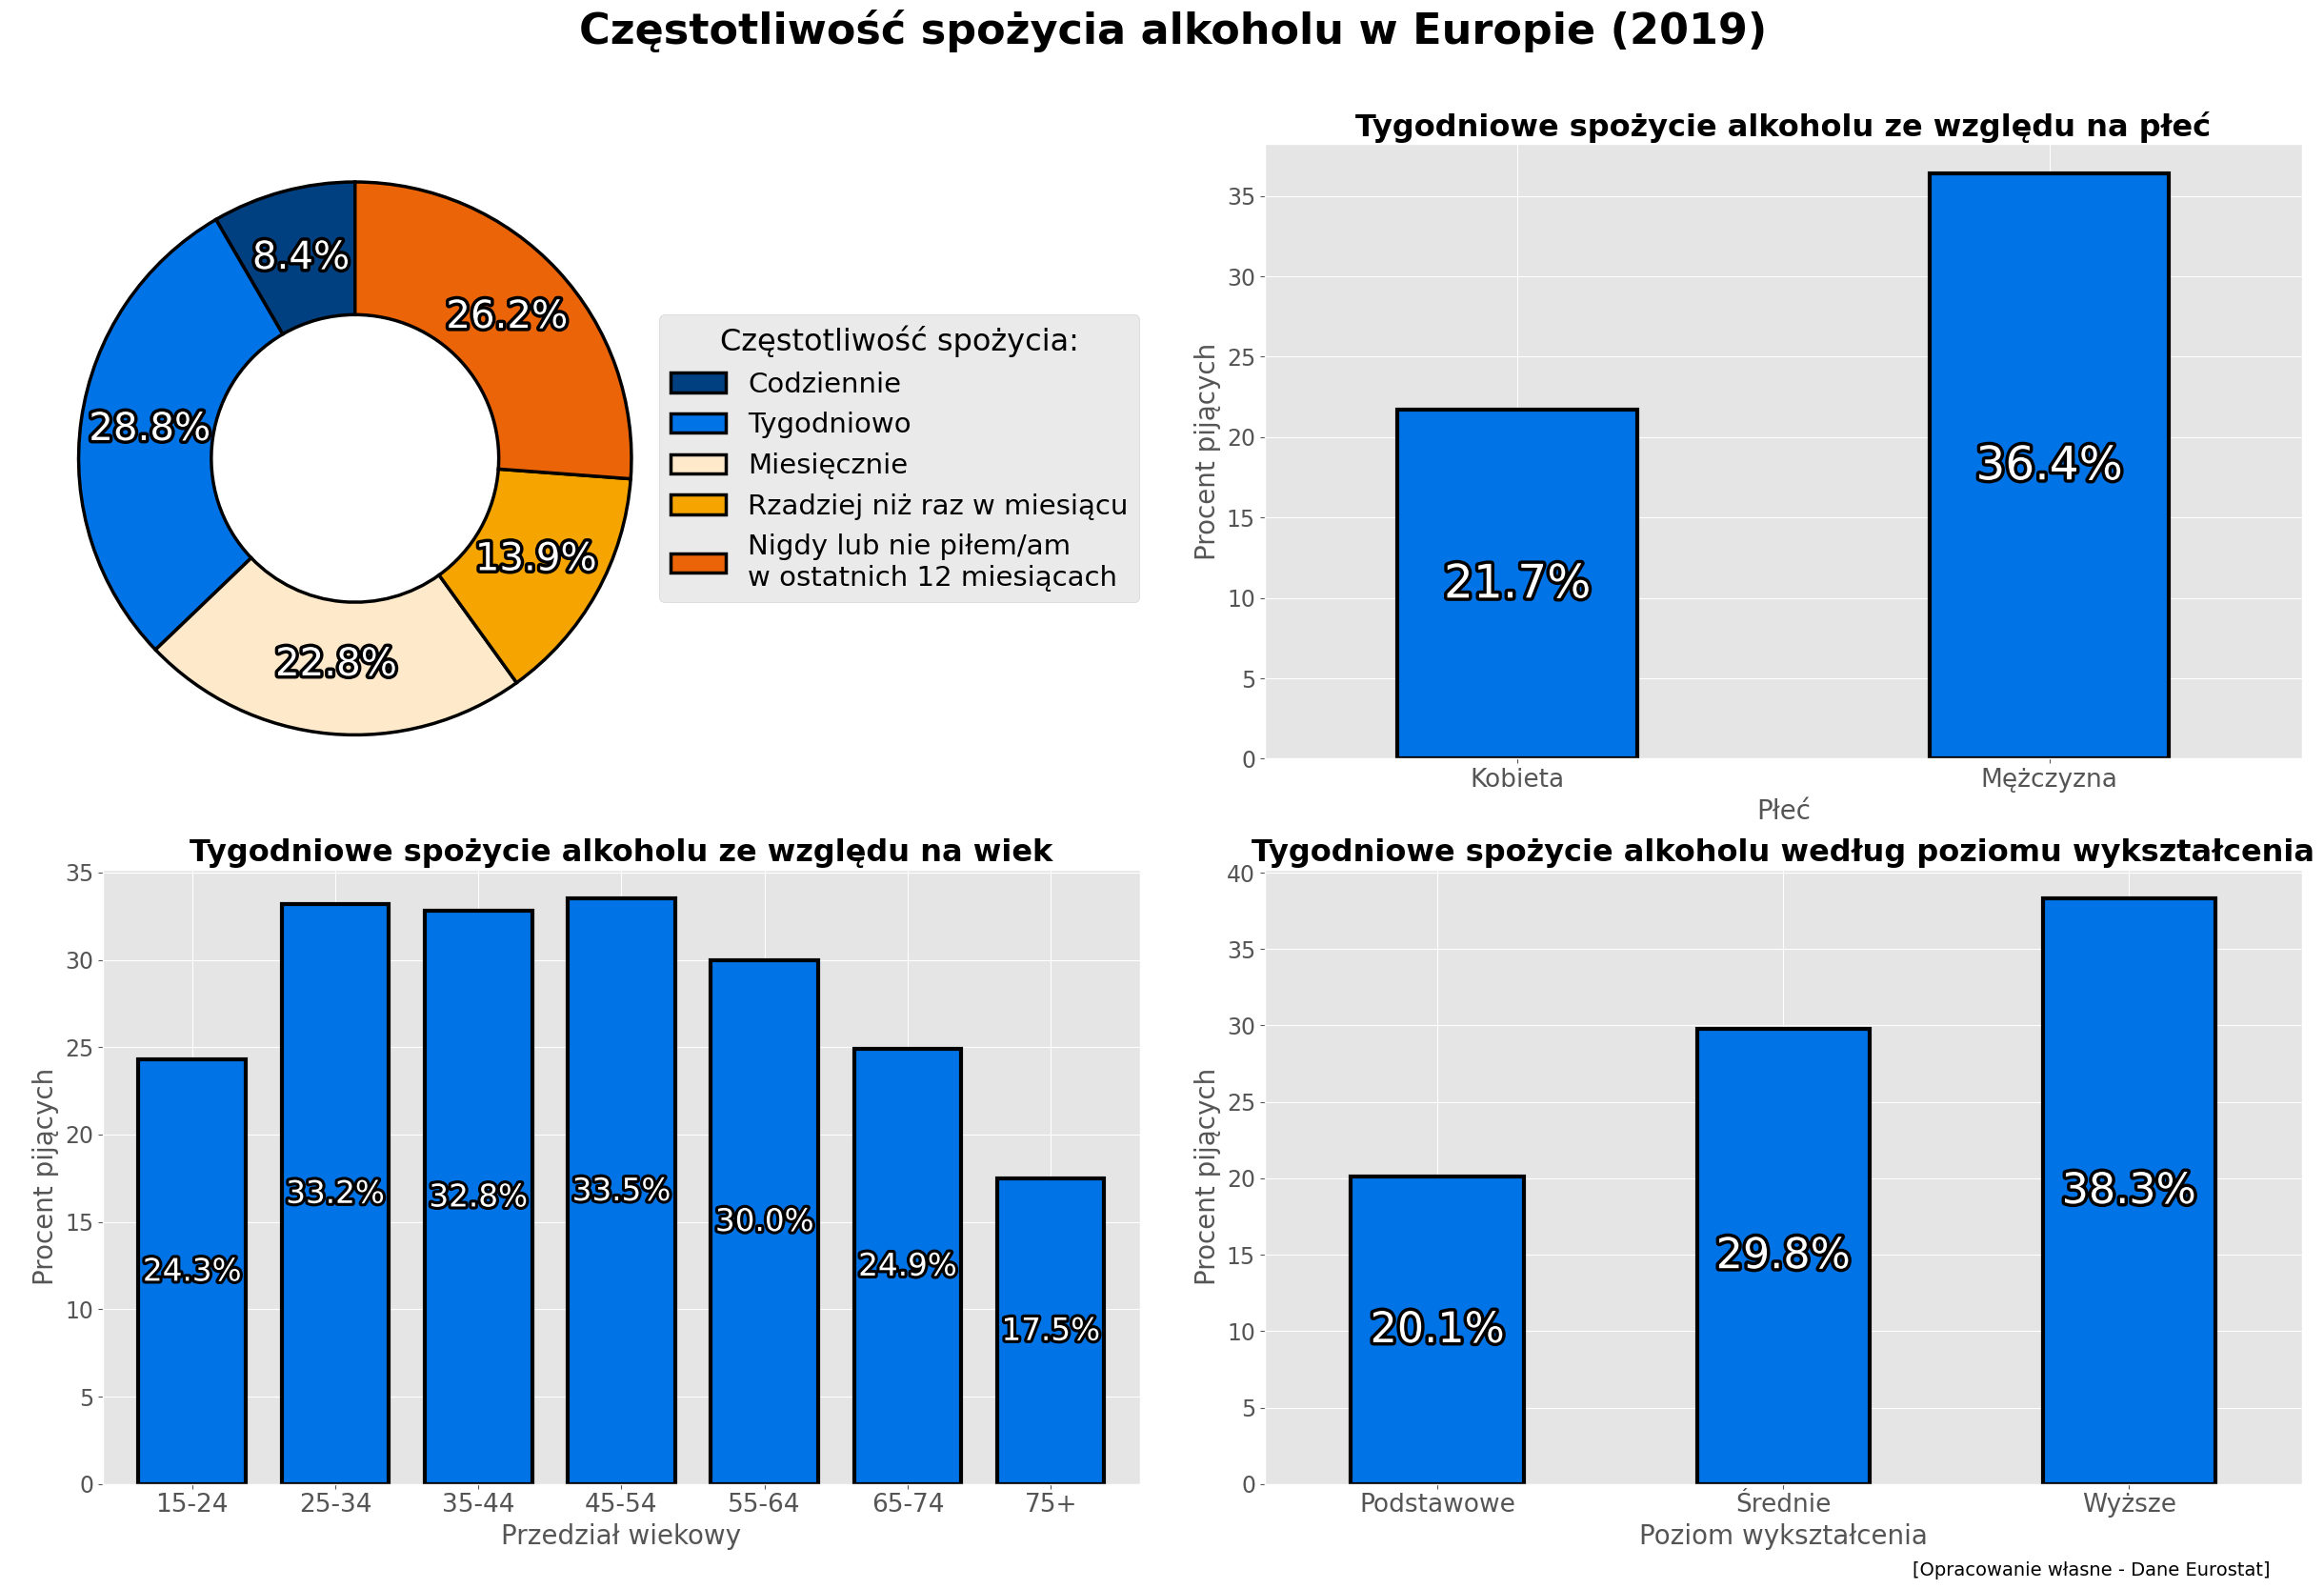

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

plt.style.use('ggplot')

# Utwórz siatkę 2x2 subplotów
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 16))
fig.subplots_adjust(wspace=0.3, hspace=0.4)  # Dodatkowe odstępy między wykresami

# Główny tytuł
fig.suptitle('Częstotliwość spożycia alkoholu w Europie (2019)',
            fontsize=32, fontweight='bold', y=1.02)

# --------------------- WYKRES 1 (lewy górny) ---------------------
data1 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
].copy()

frequency_map = {
    'DAY': 'Codziennie',
    'WEEK': 'Tygodniowo',
    'MTH': 'Miesięcznie',
    'LT1M': 'Rzadziej niż raz w miesiącu',
    'NVR_NM12': 'Nigdy lub nie piłem/am\nw ostatnich 12 miesiącach'
}

data1['frequenc_description'] = data1['frequenc'].map(frequency_map)
frequency_data1 = data1.groupby('frequenc_description')['2019'].sum().reindex([
    'Codziennie', 'Tygodniowo', 'Miesięcznie', 'Rzadziej niż raz w miesiącu', 'Nigdy lub nie piłem/am\nw ostatnich 12 miesiącach'
])

colors = ['#004080', '#0073e6', '#feeaca', '#f6a500', '#eb6508']
wedges, _ = ax1.pie(frequency_data1, labels=None, startangle=90,
                   colors=colors, wedgeprops=dict(width=0.48, edgecolor='black', linewidth=2.5))

for wedge, value, label in zip(wedges, frequency_data1, frequency_data1.index):
    angle = (wedge.theta2 + wedge.theta1)/2
    x = 0.75 * np.cos(np.deg2rad(angle))
    y = 0.75 * np.sin(np.deg2rad(angle))
    ax1.text(x, y, f"{value:.1f}%", ha='center', va='center',
            fontsize=29, color='white', path_effects=[pe.withStroke(linewidth=5, foreground='black')])

ax1.legend(wedges, frequency_data1.index, title="Częstotliwość spożycia:", title_fontsize=23,
         loc="center left", bbox_to_anchor=(0.92, 0.5), fontsize=21)

# --------------------- WYKRES 2 (prawy górny) ---------------------
data2 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['sex'] != 'T')
].copy()

data2['sex'] = data2['sex'].replace({'F': 'Kobieta', 'M': 'Mężczyzna'})
gender_data2 = data2.groupby('sex')['2019'].sum()

bars2 = gender_data2.plot(kind='bar', color='#0073e6', ax=ax2,
                         edgecolor='black', linewidth=3, width=0.45)
ax2.set_title('Tygodniowe spożycie alkoholu ze względu na płeć', fontsize=23, fontweight='bold')
ax2.set_xlabel('Płeć', fontsize=20)
ax2.set_ylabel('Procent pijących', fontsize=20)
ax2.set_xticklabels(gender_data2.index, rotation=0, fontsize=19)

for i, value in enumerate(gender_data2):
    bar = bars2.patches[i]
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=35, color='white',
            path_effects=[pe.withStroke(linewidth=5, foreground='black')])

# --------------------- WYKRES 3 (lewy dolny) ---------------------
data3 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['sex'] == 'T') &
    (db["hlth_ehis_al1e"]['age'].isin(['Y15-24', 'Y25-34', 'Y35-44', 'Y45-54', 'Y55-64', 'Y65-74', 'Y_GE75']))
].copy()

data3['age'] = data3['age'].map({
    'Y15-24': '15-24', 'Y25-34': '25-34', 'Y35-44': '35-44',
    'Y45-54': '45-54', 'Y55-64': '55-64', 'Y65-74': '65-74',
    'Y_GE75': '75+'
})

age_data3 = data3.groupby('age')['2019'].sum()

bars3 = age_data3.plot(kind='bar', color='#0073e6', ax=ax3,
                      edgecolor='black', linewidth=3, width=0.75)

ax3.set_title('Tygodniowe spożycie alkoholu ze względu na wiek', fontsize=23, fontweight='bold')
ax3.set_xlabel('Przedział wiekowy', fontsize=20)
ax3.set_ylabel('Procent pijących', fontsize=20)
ax3.set_xticklabels(age_data3.index, rotation=0, fontsize=19)


for i, value in enumerate(age_data3):
    bar = bars3.patches[i]
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=23.5, color='white',
            path_effects=[pe.withStroke(linewidth=4.5, foreground='black')])

# --------------------- WYKRES 4 (prawy dolny) ---------------------
data4 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['sex'] == 'T') &
    (db["hlth_ehis_al1e"]['isced11'] != 'TOTAL')
].copy()

education_data4 = data4.groupby('isced11')['2019'].sum()
education_data4.index = education_data4.index.map({
    'ED0-2': 'Podstawowe',
    'ED3_4': 'Średnie',
    'ED5-8': 'Wyższe'
})

bars4 = education_data4.plot(kind='bar', color='#0073e6', ax=ax4,
                            edgecolor='black', linewidth=3)
ax4.set_title('Tygodniowe spożycie alkoholu według poziomu wykształcenia', fontsize=23, fontweight='bold')
ax4.set_xlabel('Poziom wykształcenia', fontsize=20)
ax4.set_ylabel('Procent pijących', fontsize=20)
ax4.set_xticklabels(education_data4.index, rotation=0, fontsize=19)

for i, value in enumerate(education_data4):
    bar = bars4.patches[i]
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=32, color='white',
            path_effects=[pe.withStroke(linewidth=5, foreground='black')])

plt.tight_layout()


#=========================================================================================================================#
# Przesunięcie wykresu 2 w lewo
pos = ax1.get_position()
ax1.set_position([pos.x0 - 0.07, pos.y0, pos.width * 0.9, pos.height])  # Przesunięcie i lekkie zwężenie

plt.tight_layout()

# Przesunięcie wykresu 2 w lewo
pos = ax1.get_position()
ax1.set_position([pos.x0 - 0.03, pos.y0, pos.width * 0.9, pos.height])  # Przesunięcie i lekkie zwężenie

# Na końcu kodu, przed plt.show():
for ax in [ax2, ax3, ax4]:
    ax.tick_params(axis='y', labelsize=17)

# Pobierz aktualną pozycję wykresu
original_pos = ax1.get_position()

fig.subplots_adjust(wspace=0.12, hspace=0.18)

# Zwiększ rozmiar wykresu o 20% i wycentruj
new_width = original_pos.width * 1.25
new_height = original_pos.height * 1.25
ax1.set_position([
    original_pos.x0 - 0.1,  # Przesunięcie w lewo
    original_pos.y0 - 0.05,  # Przesunięcie w dół
    new_width,
    new_height
])

# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.98, -0.01, '[Opracowanie własne - Dane Eurostat]', ha='right', va='bottom', fontsize=14)
plt.show()

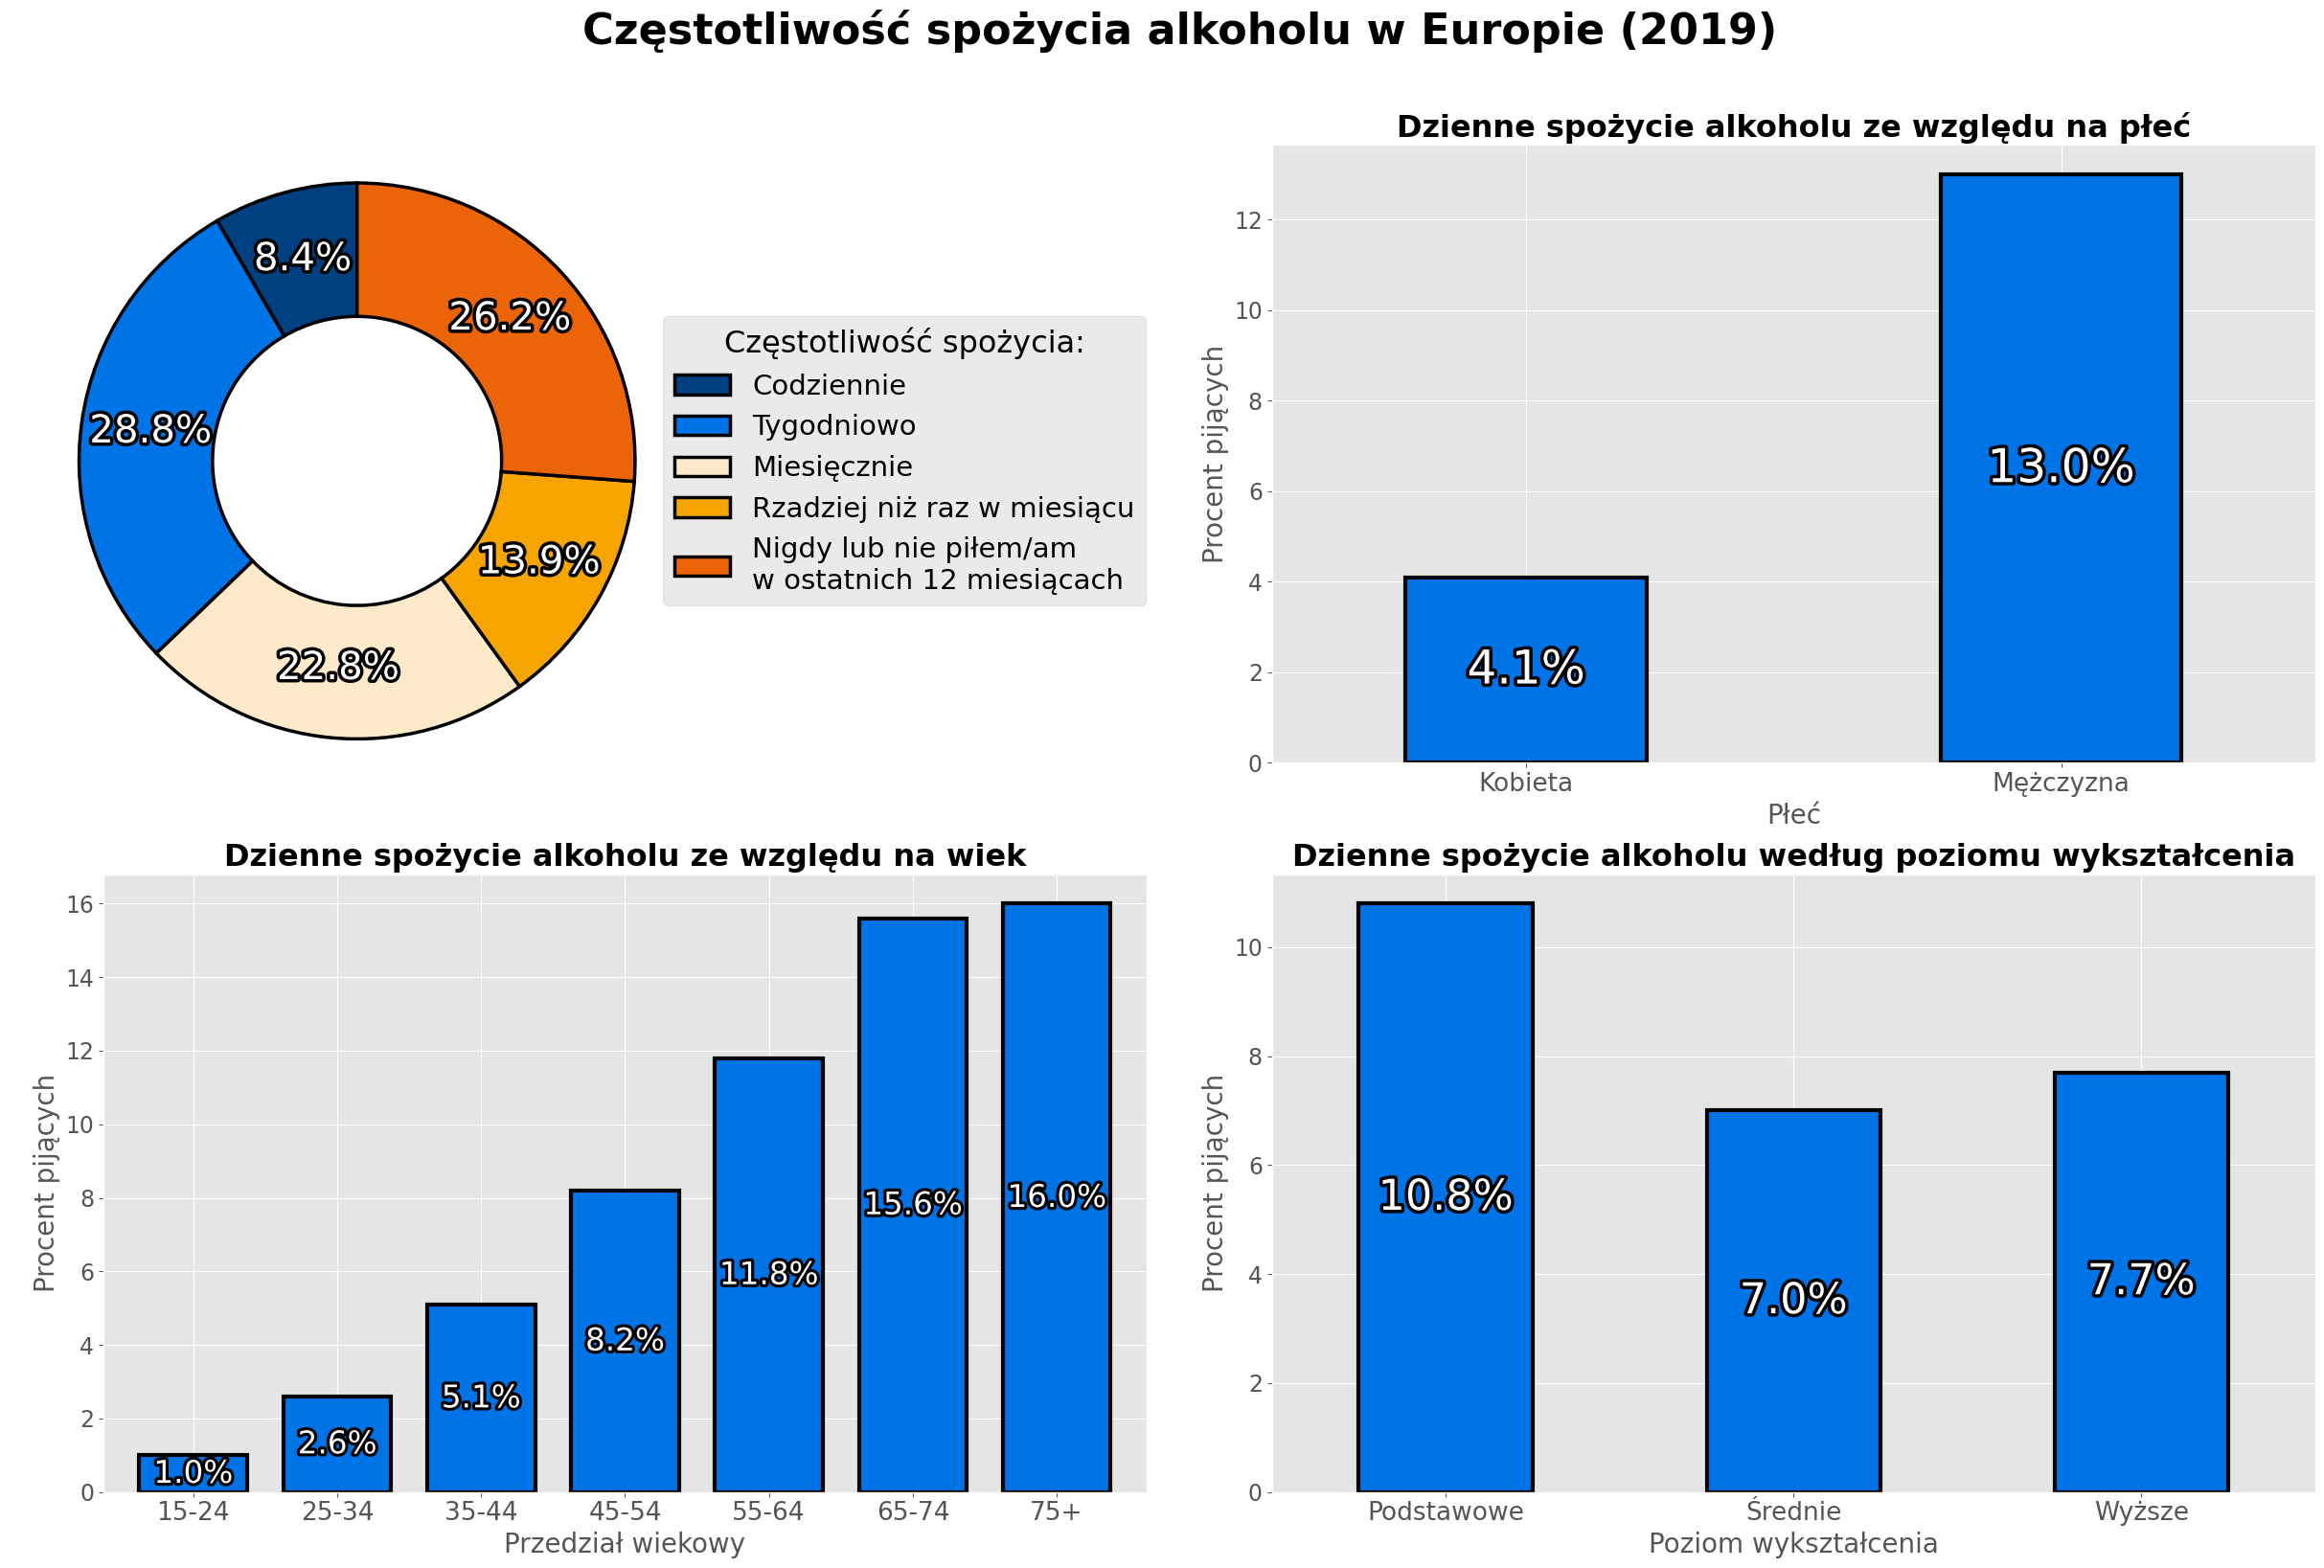

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe

plt.style.use('ggplot')

# Utwórz siatkę 2x2 subplotów
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 16))
fig.subplots_adjust(wspace=0.3, hspace=0.4)  # Dodatkowe odstępy między wykresami

# Główny tytuł
fig.suptitle('Częstotliwość spożycia alkoholu w Europie (2019)',
            fontsize=32, fontweight='bold', y=1.02)

# --------------------- WYKRES 1 (lewy górny) ---------------------
data1 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
].copy()

frequency_map = {
    'DAY': 'Codziennie',
    'WEEK': 'Tygodniowo',
    'MTH': 'Miesięcznie',
    'LT1M': 'Rzadziej niż raz w miesiącu',
    'NVR_NM12': 'Nigdy lub nie piłem/am\nw ostatnich 12 miesiącach'
}

data1['frequenc_description'] = data1['frequenc'].map(frequency_map)
frequency_data1 = data1.groupby('frequenc_description')['2019'].sum().reindex([
    'Codziennie', 'Tygodniowo', 'Miesięcznie', 'Rzadziej niż raz w miesiącu', 'Nigdy lub nie piłem/am\nw ostatnich 12 miesiącach'
])

colors = ['#004080', '#0073e6', '#feeaca', '#f6a500', '#eb6508']
wedges, _ = ax1.pie(frequency_data1, labels=None, startangle=90,
                   colors=colors, wedgeprops=dict(width=0.48, edgecolor='black', linewidth=2.5))

for wedge, value, label in zip(wedges, frequency_data1, frequency_data1.index):
    angle = (wedge.theta2 + wedge.theta1)/2
    x = 0.75 * np.cos(np.deg2rad(angle))
    y = 0.75 * np.sin(np.deg2rad(angle))
    ax1.text(x, y, f"{value:.1f}%", ha='center', va='center',
            fontsize=29, color='white', path_effects=[pe.withStroke(linewidth=5, foreground='black')])

ax1.legend(wedges, frequency_data1.index, title="Częstotliwość spożycia:", title_fontsize=23,
         loc="center left", bbox_to_anchor=(0.92, 0.5), fontsize=21)

# --------------------- WYKRES 2 (prawy górny) ---------------------
data2 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['frequenc'] == 'DAY') &
    (db["hlth_ehis_al1e"]['sex'] != 'T')
].copy()

data2['sex'] = data2['sex'].replace({'F': 'Kobieta', 'M': 'Mężczyzna'})
gender_data2 = data2.groupby('sex')['2019'].sum()

bars2 = gender_data2.plot(kind='bar', color='#0073e6', ax=ax2,
                         edgecolor='black', linewidth=3, width=0.45)
ax2.set_title('Dzienne spożycie alkoholu ze względu na płeć', fontsize=23, fontweight='bold')
ax2.set_xlabel('Płeć', fontsize=20)
ax2.set_ylabel('Procent pijących', fontsize=20)
ax2.set_xticklabels(gender_data2.index, rotation=0, fontsize=19)

for i, value in enumerate(gender_data2):
    bar = bars2.patches[i]
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=35, color='white',
            path_effects=[pe.withStroke(linewidth=5, foreground='black')])

# --------------------- WYKRES 3 (lewy dolny) ---------------------
data3 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['frequenc'] == 'DAY') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['sex'] == 'T') &
    (db["hlth_ehis_al1e"]['age'].isin(['Y15-24', 'Y25-34', 'Y35-44', 'Y45-54', 'Y55-64', 'Y65-74', 'Y_GE75']))
].copy()

data3['age'] = data3['age'].map({
    'Y15-24': '15-24', 'Y25-34': '25-34', 'Y35-44': '35-44',
    'Y45-54': '45-54', 'Y55-64': '55-64', 'Y65-74': '65-74',
    'Y_GE75': '75+'
})

age_data3 = data3.groupby('age')['2019'].sum()

bars3 = age_data3.plot(kind='bar', color='#0073e6', ax=ax3,
                      edgecolor='black', linewidth=3, width=0.75)

ax3.set_title('Dzienne spożycie alkoholu ze względu na wiek', fontsize=23, fontweight='bold')
ax3.set_xlabel('Przedział wiekowy', fontsize=20)
ax3.set_ylabel('Procent pijących', fontsize=20)
ax3.set_xticklabels(age_data3.index, rotation=0, fontsize=19)


for i, value in enumerate(age_data3):
    bar = bars3.patches[i]
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=23.5, color='white',
            path_effects=[pe.withStroke(linewidth=4.5, foreground='black')])

# --------------------- WYKRES 4 (prawy dolny) ---------------------
data4 = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'DAY') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['geo\TIME_PERIOD'] == 'EU27_2020') &
    (db["hlth_ehis_al1e"]['sex'] == 'T') &
    (db["hlth_ehis_al1e"]['isced11'] != 'TOTAL')
].copy()

education_data4 = data4.groupby('isced11')['2019'].sum()
education_data4.index = education_data4.index.map({
    'ED0-2': 'Podstawowe',
    'ED3_4': 'Średnie',
    'ED5-8': 'Wyższe'
})

bars4 = education_data4.plot(kind='bar', color='#0073e6', ax=ax4,
                            edgecolor='black', linewidth=3)
ax4.set_title('Dzienne spożycie alkoholu według poziomu wykształcenia', fontsize=23, fontweight='bold')
ax4.set_xlabel('Poziom wykształcenia', fontsize=20)
ax4.set_ylabel('Procent pijących', fontsize=20)
ax4.set_xticklabels(education_data4.index, rotation=0, fontsize=19)

for i, value in enumerate(education_data4):
    bar = bars4.patches[i]
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2, f'{value:.1f}%',
            ha='center', va='center', fontsize=32, color='white',
            path_effects=[pe.withStroke(linewidth=5, foreground='black')])

plt.tight_layout()


#=========================================================================================================================#
# Przesunięcie wykresu 2 w lewo
pos = ax1.get_position()
ax1.set_position([pos.x0 - 0.07, pos.y0, pos.width * 0.9, pos.height])  # Przesunięcie i lekkie zwężenie

plt.tight_layout()

# Przesunięcie wykresu 2 w lewo
pos = ax1.get_position()
ax1.set_position([pos.x0 - 0.03, pos.y0, pos.width * 0.9, pos.height])  # Przesunięcie i lekkie zwężenie

# Na końcu kodu, przed plt.show():
for ax in [ax2, ax3, ax4]:
    ax.tick_params(axis='y', labelsize=17)

# Pobierz aktualną pozycję wykresu
original_pos = ax1.get_position()

fig.subplots_adjust(wspace=0.12, hspace=0.18)

# Zwiększ rozmiar wykresu o 20% i wycentruj
new_width = original_pos.width * 1.25
new_height = original_pos.height * 1.25
ax1.set_position([
    original_pos.x0 - 0.1,  # Przesunięcie w lewo
    original_pos.y0 - 0.05,  # Przesunięcie w dół
    new_width,
    new_height
])

plt.show()

In [ ]:
!pip install geopandas pycountry matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 34.0 MB/s eta 0:00:00


In [ ]:
!pip install contextily


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 43.6 MB/s eta 0:00:00


In [ ]:
# Zakładamy, że dane już zostały wyfiltrowane do zmiennej alcohol_data:
alcohol_data = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
].copy()

# Wyciągamy unikalne kraje – kolumna zawiera kody krajów
unique_countries = alcohol_data['geo\\TIME_PERIOD'].unique()

# Wyświetlamy wynik
print("Unikalne kraje:", unique_countries)


Unikalne kraje: ['AT' 'BE' 'BG' 'CY' 'CZ' 'DE' 'DK' 'EE' 'EL' 'ES' 'EU27_2020' 'EU28' 'FI'
 'FR' 'HR' 'HU' 'IE' 'IS' 'IT' 'LT' 'LU' 'LV' 'MT' 'NL' 'NO' 'PL' 'PT'
 'RO' 'RS' 'SE' 'SI' 'SK' 'TR' 'UK']


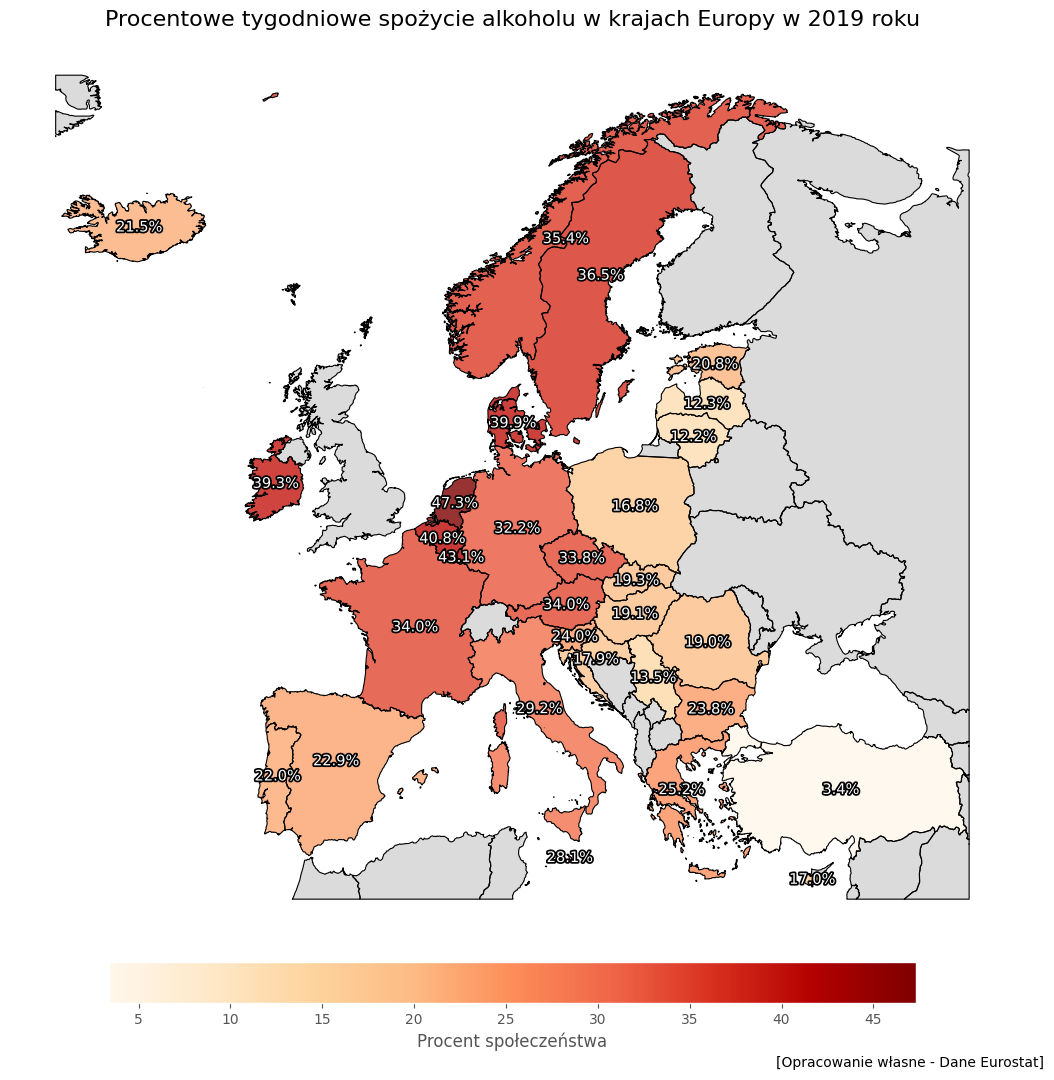

In [ ]:
import os
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
from shapely.geometry import box
import matplotlib.patheffects as pe

# Zakładamy, że zmienna `db` jest już zdefiniowana i zawiera DataFrame o kluczu "hlth_ehis_al1e"

# ------------------------------
# Krok 1: Pobranie i filtrowanie danych z bazy
# ------------------------------
# Filtrowanie wg warunków:
#   - frequenc == 'WEEK'
#   - age == 'TOTAL'
#   - isced11 == 'TOTAL'
#   - sex == 'T'
df = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'WEEK') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
]

# Wybieramy dane dla roku 2019 oraz kolumnę z kodem kraju
df_2019 = df[['geo\\TIME_PERIOD', '2019']].dropna(subset=['2019'])

# Usuwamy agregaty unijne, jeśli występują
df_2019 = df_2019[~df_2019['geo\\TIME_PERIOD'].isin(['EU27_2020', 'EU28'])]

# Zamiana kodów krajów: Grecja ("EL") na "GR" oraz Wielka Brytania ("UK") na "GB"
df_2019['geo\\TIME_PERIOD'] = df_2019['geo\\TIME_PERIOD'].replace({'EL': 'GR', 'UK': 'GB'})

# Funkcja konwertująca kod kraju (alpha-2) na kod ISO A3
def get_alpha3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except Exception:
        return None

df_2019['iso_a3'] = df_2019['geo\\TIME_PERIOD'].apply(get_alpha3)

# ------------------------------
# Krok 2: Pobranie danych geograficznych (GeoJSON)
# ------------------------------

data_dir = 'data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

geojson_file = os.path.join(data_dir, 'countries.geojson')
if not os.path.exists(geojson_file):
    print("Pobieram dane GeoJSON z GitHub...")
    url_geojson = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
    r = requests.get(url_geojson)
    if r.status_code == 200:
        with open(geojson_file, 'wb') as f:
            f.write(r.content)
    else:
        raise Exception("Błąd pobierania danych GeoJSON. Kod statusu: {}".format(r.status_code))

world = gpd.read_file(geojson_file)
# Ujednolicenie nazwy kolumny: "ISO_A3" → "iso_a3" (jeśli występuje)
if 'ISO_A3' in world.columns:
    world = world.rename(columns={'ISO_A3': 'iso_a3'})

# ------------------------------
# Krok 3: Łączenie danych i filtrowanie do Europy
# ------------------------------

merged = world.merge(df_2019, how='left', on='iso_a3')
merged['geometry'] = merged['geometry'].buffer(0)

# Definicja przybliżonego obszaru Europy (bounding box)
europe_bbox = box(-25, 34, 45, 72)
merged_europe = gpd.clip(merged, europe_bbox)

# ------------------------------
# Krok 4: Tworzenie mapy i formatowanie legendy
# ------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Rysowanie konturów krajów
merged_europe.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Rysowanie wypełnionych krajów wg wartości z 2019 roku
merged_europe.plot(column='2019', ax=ax, legend=True, cmap='OrRd', alpha=0.8,
                   legend_kwds={'label': "Procent społeczeństwa",
                                'shrink': 0.6,
                                'orientation': "horizontal",
                                'pad': 0.02},  # Przesunięcie legendy bliżej mapy
                   missing_kwds={'color': 'lightgrey', 'label': 'Brak danych'})

# Dodanie etykiet z wartościami na mapie (na środku krajów)
for idx, row in merged_europe.iterrows():
    if pd.notna(row['2019']):
        centroid = row['geometry'].centroid
        ax.text(centroid.x, centroid.y, f"{row['2019']:.1f}%",
                ha='center', va='center', fontsize=10.5, color='white',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])

ax.set_title('Procentowe tygodniowe spożycie alkoholu w krajach Europy w 2019 roku', fontsize=16)
ax.set_axis_off()

# Dostosowanie marginesów, aby legenda była bliżej mapy
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.2)
# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.88, 0.24, '[Opracowanie własne - Dane Eurostat]', ha='right', va='bottom', fontsize=10)

plt.show()


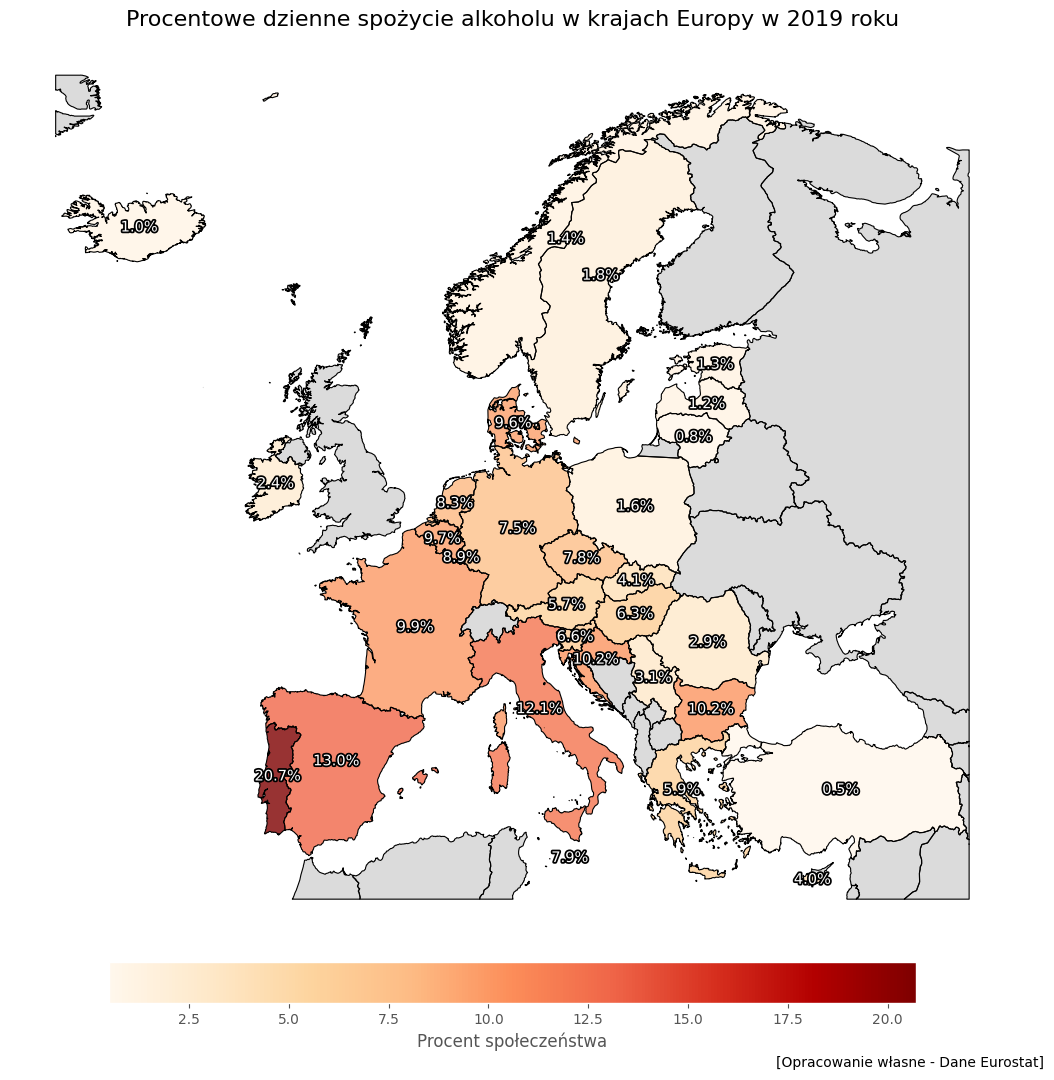

In [ ]:
import os
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
from shapely.geometry import box
import matplotlib.patheffects as pe

# Zakładamy, że zmienna `db` jest już zdefiniowana i zawiera DataFrame o kluczu "hlth_ehis_al1e"

# ------------------------------
# Krok 1: Pobranie i filtrowanie danych z bazy
# ------------------------------
# Filtrowanie wg warunków:
#   - frequenc == 'WEEK'
#   - age == 'TOTAL'
#   - isced11 == 'TOTAL'
#   - sex == 'T'
df = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'DAY') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
]

# Wybieramy dane dla roku 2019 oraz kolumnę z kodem kraju
df_2019 = df[['geo\\TIME_PERIOD', '2019']].dropna(subset=['2019'])

# Usuwamy agregaty unijne, jeśli występują
df_2019 = df_2019[~df_2019['geo\\TIME_PERIOD'].isin(['EU27_2020', 'EU28'])]

# Zamiana kodów krajów: Grecja ("EL") na "GR" oraz Wielka Brytania ("UK") na "GB"
df_2019['geo\\TIME_PERIOD'] = df_2019['geo\\TIME_PERIOD'].replace({'EL': 'GR', 'UK': 'GB'})

# Funkcja konwertująca kod kraju (alpha-2) na kod ISO A3
def get_alpha3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except Exception:
        return None

df_2019['iso_a3'] = df_2019['geo\\TIME_PERIOD'].apply(get_alpha3)

# ------------------------------
# Krok 2: Pobranie danych geograficznych (GeoJSON)
# ------------------------------

data_dir = 'data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

geojson_file = os.path.join(data_dir, 'countries.geojson')
if not os.path.exists(geojson_file):
    print("Pobieram dane GeoJSON z GitHub...")
    url_geojson = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
    r = requests.get(url_geojson)
    if r.status_code == 200:
        with open(geojson_file, 'wb') as f:
            f.write(r.content)
    else:
        raise Exception("Błąd pobierania danych GeoJSON. Kod statusu: {}".format(r.status_code))

world = gpd.read_file(geojson_file)
# Ujednolicenie nazwy kolumny: "ISO_A3" → "iso_a3" (jeśli występuje)
if 'ISO_A3' in world.columns:
    world = world.rename(columns={'ISO_A3': 'iso_a3'})

# ------------------------------
# Krok 3: Łączenie danych i filtrowanie do Europy
# ------------------------------

merged = world.merge(df_2019, how='left', on='iso_a3')
merged['geometry'] = merged['geometry'].buffer(0)

# Definicja przybliżonego obszaru Europy (bounding box)
europe_bbox = box(-25, 34, 45, 72)
merged_europe = gpd.clip(merged, europe_bbox)

# ------------------------------
# Krok 4: Tworzenie mapy i formatowanie legendy
# ------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Rysowanie konturów krajów
merged_europe.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Rysowanie wypełnionych krajów wg wartości z 2019 roku
merged_europe.plot(column='2019', ax=ax, legend=True, cmap='OrRd', alpha=0.8,
                   legend_kwds={'label': "Procent społeczeństwa",
                                'shrink': 0.6,
                                'orientation': "horizontal",
                                'pad': 0.02},  # Przesunięcie legendy bliżej mapy
                   missing_kwds={'color': 'lightgrey', 'label': 'Brak danych'})

# Dodanie etykiet z wartościami na mapie (na środku krajów)
for idx, row in merged_europe.iterrows():
    if pd.notna(row['2019']):
        centroid = row['geometry'].centroid
        ax.text(centroid.x, centroid.y, f"{row['2019']:.1f}%",
                ha='center', va='center', fontsize=10.5, color='white',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])

ax.set_title('Procentowe dzienne spożycie alkoholu w krajach Europy w 2019 roku', fontsize=16)
ax.set_axis_off()

# Dostosowanie marginesów, aby legenda była bliżej mapy
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.2)

# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.88, 0.24, '[Opracowanie własne - Dane Eurostat]', ha='right', va='bottom', fontsize=10)

plt.show()


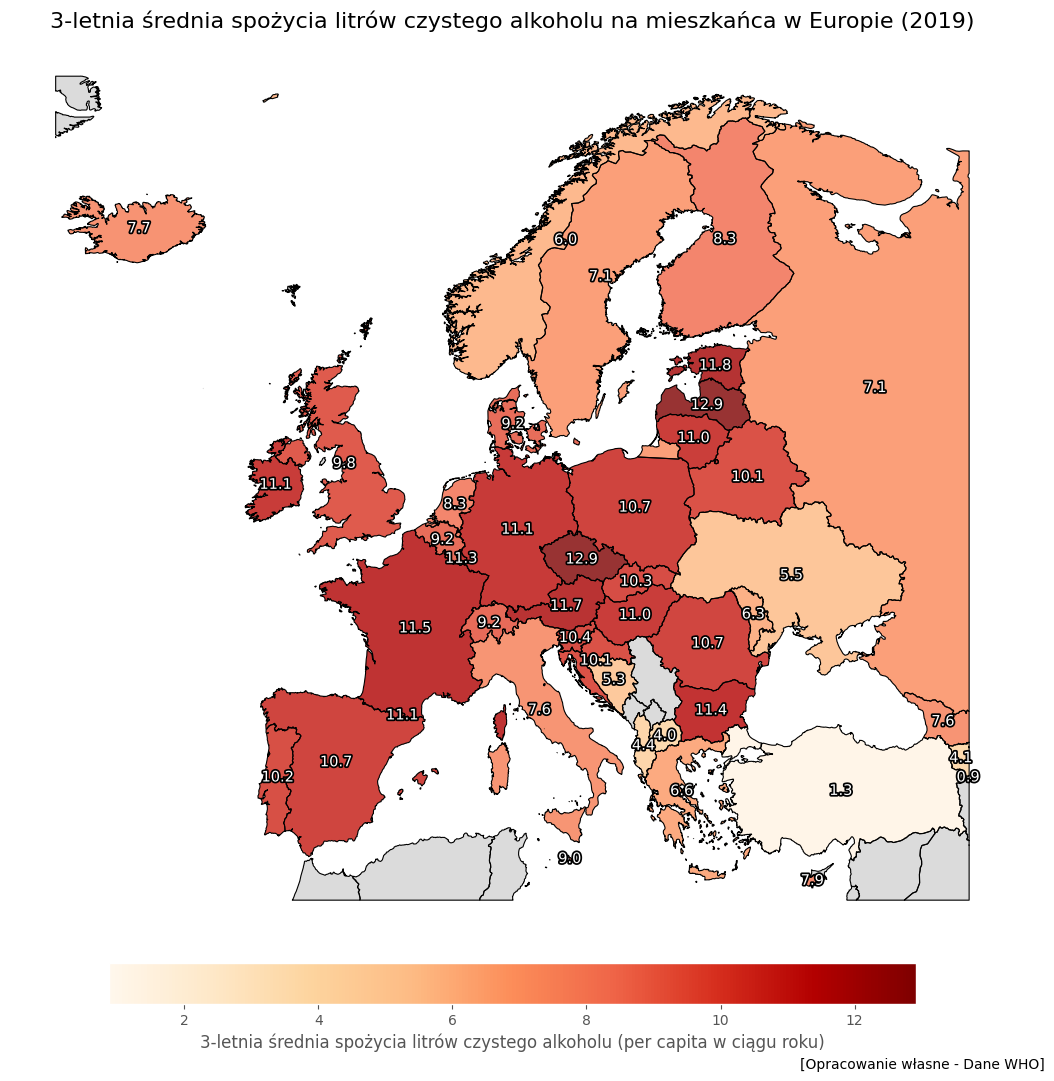

In [ ]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from shapely.geometry import box

# -------------- Krok 1: Wczytanie pliku CSV ------------------
# Podaj ścieżkę do swojego pliku CSV (np. lokalny plik pobrany z Twojego repozytorium)
csv_file = "https://raw.githubusercontent.com/RusieckiFilip/Inzynieria_Obliczeniowa_UW/refs/heads/main/DATABASES/ALCOHOL_CONSUMPTION/WHO/08f7c8a6-0a75-4ee4-9563-09b5fe68704b.csv"  # <- zmień tę ścieżkę na odpowiednią
df = pd.read_csv(csv_file)

# -------------- Krok 2: Przetwarzanie danych ------------------
# Zakładamy, że interesujące nas kolumny to:
# - "Period"              : rok, np. 2019
# - "SpatialDimValueCode" : kod kraju (ISO A3)
# - "FactValueNumeric"    : wartość spożycia alkoholu
#
# Wybieramy dane dla roku 2019 i usuwamy wiersze bez danych
df_filtered = df[df["Period"] == 2019][["SpatialDimValueCode", "FactValueNumeric"]].dropna()
# Zmieniamy nazwy kolumn dla wygody
df_filtered = df_filtered.rename(columns={
    "SpatialDimValueCode": "iso_a3",
    "FactValueNumeric": "consumption"
})

# -------------- Krok 3: Wczytanie danych geograficznych (GeoJSON) ------------------
# Upewnij się, że masz plik GeoJSON z granicami krajów zapisany lokalnie.
data_dir = "data"
geojson_file = os.path.join(data_dir, "countries.geojson")
if not os.path.exists(geojson_file):
    raise FileNotFoundError(f"Plik GeoJSON nie został znaleziony. Umieść plik 'countries.geojson' w folderze '{data_dir}'.")

# Wczytanie danych geograficznych
world = gpd.read_file(geojson_file)
# Ujednolicenie nazwy kolumny z kodem kraju – zamieniamy 'ISO_A3' na 'iso_a3'
if "ISO_A3" in world.columns:
    world = world.rename(columns={"ISO_A3": "iso_a3"})

# -------------- Krok 4: Łączenie danych i filtrowanie do Europy ------------------
# Łączymy dane WHO z danymi geograficznymi na podstawie kodu kraju
merged = world.merge(df_filtered, how="left", on="iso_a3")
# Naprawiamy ewentualne błędy geometrii
merged["geometry"] = merged["geometry"].buffer(0)

# Definiujemy przybliżony obszar Europy (bounding box: -25° do 45° długości, 34° do 72° szerokości)
europe_bbox = box(-25, 34, 45, 72)
merged_europe = gpd.clip(merged, europe_bbox)

# -------------- Krok 5: Rysowanie mapy ------------------
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Rysujemy kontury krajów
merged_europe.boundary.plot(ax=ax, color="black", linewidth=0.8)

# Rysujemy wypełnienie krajów według wartości spożycia alkoholu
merged_europe.plot(
    column="consumption",
    ax=ax,
    legend=True,
    cmap="OrRd",
    alpha=0.8,
    legend_kwds={
        "label": "3-letnia średnia spożycia litrów czystego alkoholu (per capita w ciągu roku)",
        "shrink": 0.6,
        "orientation": "horizontal",
        "pad": 0.02
    },
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

# Dodanie etykiet – umieszczamy wartość spożycia na centroidach krajów
for idx, row in merged_europe.iterrows():
    if pd.notna(row["consumption"]):
        centroid = row["geometry"].centroid
        ax.text(
            centroid.x, centroid.y,
            f"{row['consumption']:.1f}",
            ha="center", va="center",
            fontsize=10.5,
            color="white",
            path_effects=[pe.withStroke(linewidth=2.5, foreground="black")]
        )

ax.set_title("3-letnia średnia spożycia litrów czystego alkoholu na mieszkańca w Europie (2019)", fontsize=16)
ax.set_axis_off()
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.2)
# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.88, 0.24, '[Opracowanie własne - Dane WHO]', ha='right', va='bottom', fontsize=10)
plt.show()


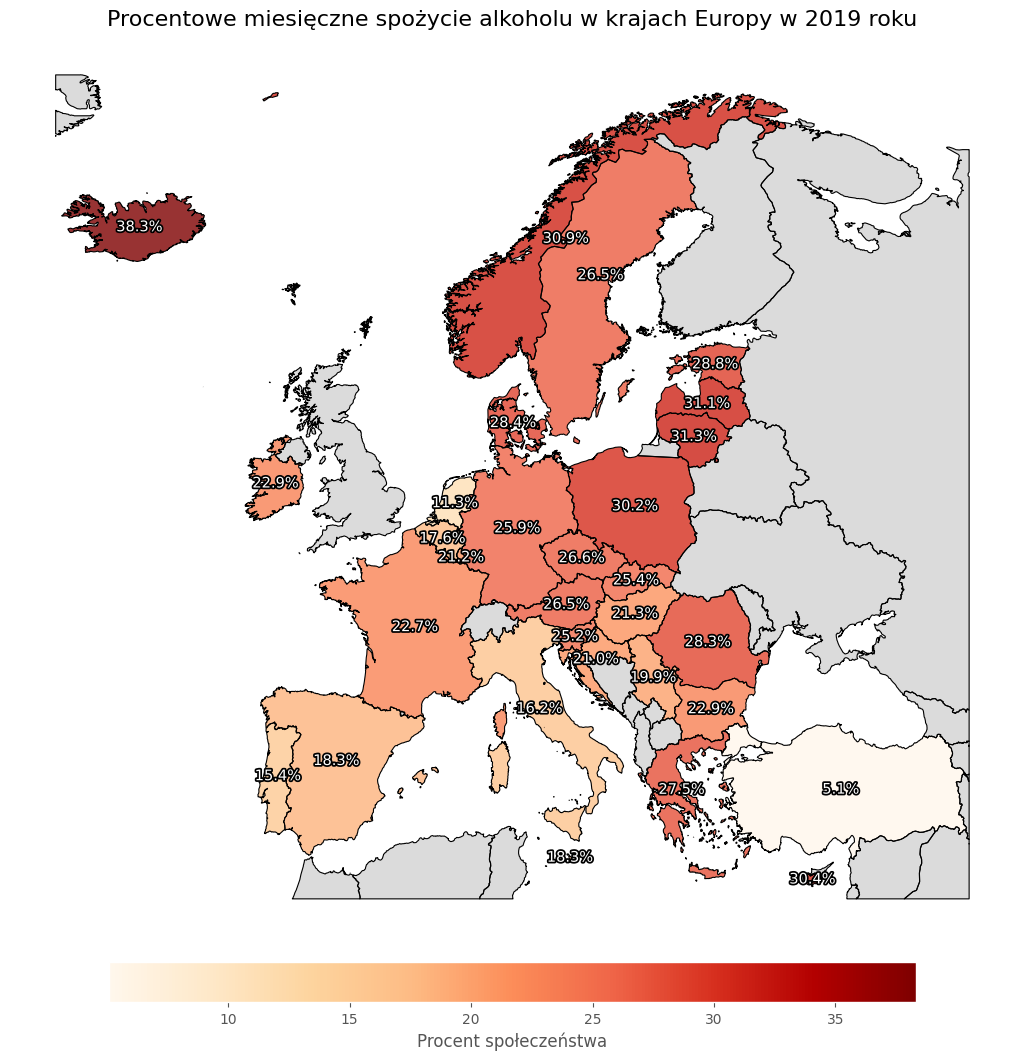

In [ ]:
import os
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
from shapely.geometry import box
import matplotlib.patheffects as pe

# Zakładamy, że zmienna `db` jest już zdefiniowana i zawiera DataFrame o kluczu "hlth_ehis_al1e"

# ------------------------------
# Krok 1: Pobranie i filtrowanie danych z bazy
# ------------------------------
# Filtrowanie wg warunków:
#   - frequenc == 'WEEK'
#   - age == 'TOTAL'
#   - isced11 == 'TOTAL'
#   - sex == 'T'
df = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'MTH') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
]

# Wybieramy dane dla roku 2019 oraz kolumnę z kodem kraju
df_2019 = df[['geo\\TIME_PERIOD', '2019']].dropna(subset=['2019'])

# Usuwamy agregaty unijne, jeśli występują
df_2019 = df_2019[~df_2019['geo\\TIME_PERIOD'].isin(['EU27_2020', 'EU28'])]

# Zamiana kodów krajów: Grecja ("EL") na "GR" oraz Wielka Brytania ("UK") na "GB"
df_2019['geo\\TIME_PERIOD'] = df_2019['geo\\TIME_PERIOD'].replace({'EL': 'GR', 'UK': 'GB'})

# Funkcja konwertująca kod kraju (alpha-2) na kod ISO A3
def get_alpha3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except Exception:
        return None

df_2019['iso_a3'] = df_2019['geo\\TIME_PERIOD'].apply(get_alpha3)

# ------------------------------
# Krok 2: Pobranie danych geograficznych (GeoJSON)
# ------------------------------

data_dir = 'data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

geojson_file = os.path.join(data_dir, 'countries.geojson')
if not os.path.exists(geojson_file):
    print("Pobieram dane GeoJSON z GitHub...")
    url_geojson = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
    r = requests.get(url_geojson)
    if r.status_code == 200:
        with open(geojson_file, 'wb') as f:
            f.write(r.content)
    else:
        raise Exception("Błąd pobierania danych GeoJSON. Kod statusu: {}".format(r.status_code))

world = gpd.read_file(geojson_file)
# Ujednolicenie nazwy kolumny: "ISO_A3" → "iso_a3" (jeśli występuje)
if 'ISO_A3' in world.columns:
    world = world.rename(columns={'ISO_A3': 'iso_a3'})

# ------------------------------
# Krok 3: Łączenie danych i filtrowanie do Europy
# ------------------------------

merged = world.merge(df_2019, how='left', on='iso_a3')
merged['geometry'] = merged['geometry'].buffer(0)

# Definicja przybliżonego obszaru Europy (bounding box)
europe_bbox = box(-25, 34, 45, 72)
merged_europe = gpd.clip(merged, europe_bbox)

# ------------------------------
# Krok 4: Tworzenie mapy i formatowanie legendy
# ------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Rysowanie konturów krajów
merged_europe.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Rysowanie wypełnionych krajów wg wartości z 2019 roku
merged_europe.plot(column='2019', ax=ax, legend=True, cmap='OrRd', alpha=0.8,
                   legend_kwds={'label': "Procent społeczeństwa",
                                'shrink': 0.6,
                                'orientation': "horizontal",
                                'pad': 0.02},  # Przesunięcie legendy bliżej mapy
                   missing_kwds={'color': 'lightgrey', 'label': 'Brak danych'})

# Dodanie etykiet z wartościami na mapie (na środku krajów)
for idx, row in merged_europe.iterrows():
    if pd.notna(row['2019']):
        centroid = row['geometry'].centroid
        ax.text(centroid.x, centroid.y, f"{row['2019']:.1f}%",
                ha='center', va='center', fontsize=10.5, color='white',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])

ax.set_title('Procentowe miesięczne spożycie alkoholu w krajach Europy w 2019 roku', fontsize=16)
ax.set_axis_off()

# Dostosowanie marginesów, aby legenda była bliżej mapy
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.2)

plt.show()


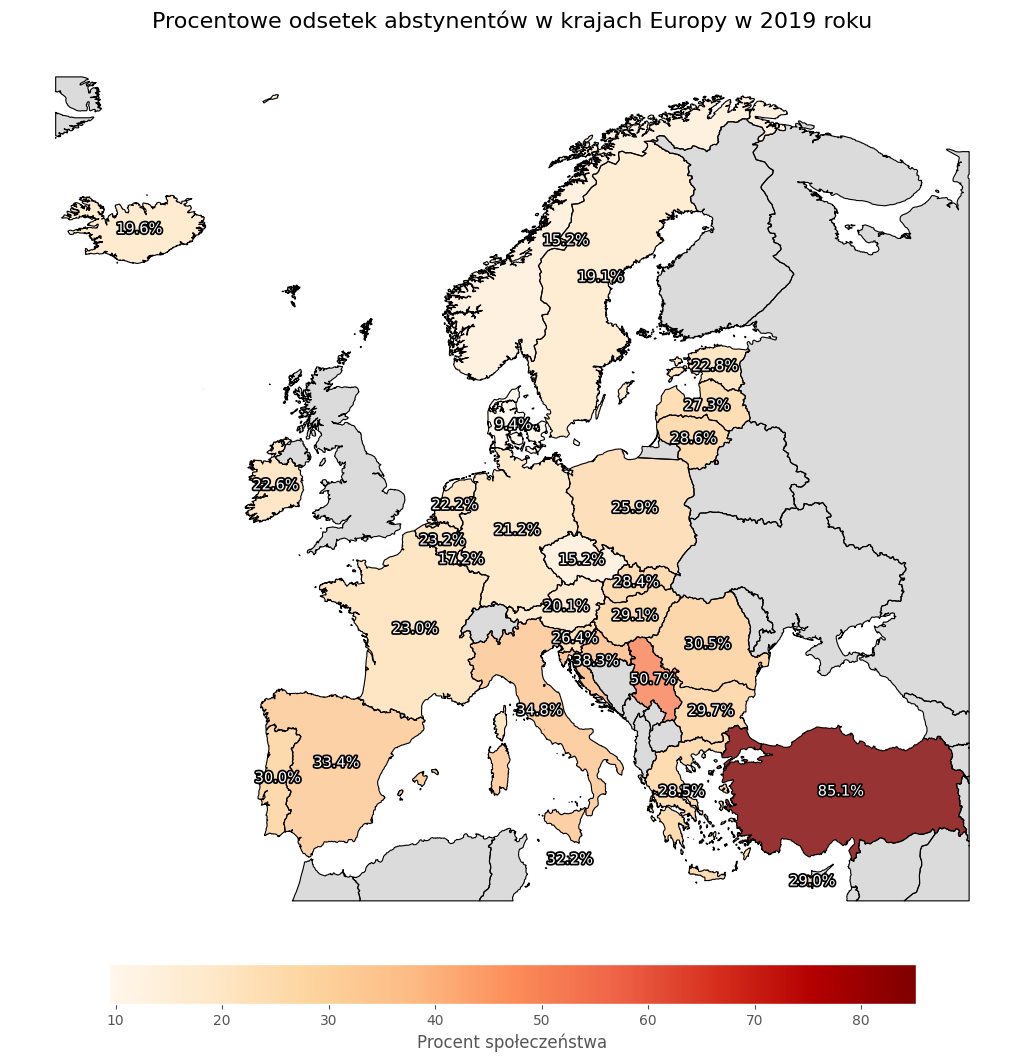

In [ ]:
import os
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pycountry
from shapely.geometry import box
import matplotlib.patheffects as pe

# Zakładamy, że zmienna `db` jest już zdefiniowana i zawiera DataFrame o kluczu "hlth_ehis_al1e"

# ------------------------------
# Krok 1: Pobranie i filtrowanie danych z bazy
# ------------------------------
# Filtrowanie wg warunków:
#   - frequenc == 'WEEK'
#   - age == 'TOTAL'
#   - isced11 == 'TOTAL'
#   - sex == 'T'
df = db["hlth_ehis_al1e"][
    (db["hlth_ehis_al1e"]['frequenc'] == 'NVR_NM12') &
    (db["hlth_ehis_al1e"]['age'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['isced11'] == 'TOTAL') &
    (db["hlth_ehis_al1e"]['sex'] == 'T')
]

# Wybieramy dane dla roku 2019 oraz kolumnę z kodem kraju
df_2019 = df[['geo\\TIME_PERIOD', '2019']].dropna(subset=['2019'])

# Usuwamy agregaty unijne, jeśli występują
df_2019 = df_2019[~df_2019['geo\\TIME_PERIOD'].isin(['EU27_2020', 'EU28'])]

# Zamiana kodów krajów: Grecja ("EL") na "GR" oraz Wielka Brytania ("UK") na "GB"
df_2019['geo\\TIME_PERIOD'] = df_2019['geo\\TIME_PERIOD'].replace({'EL': 'GR', 'UK': 'GB'})

# Funkcja konwertująca kod kraju (alpha-2) na kod ISO A3
def get_alpha3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except Exception:
        return None

df_2019['iso_a3'] = df_2019['geo\\TIME_PERIOD'].apply(get_alpha3)

# ------------------------------
# Krok 2: Pobranie danych geograficznych (GeoJSON)
# ------------------------------

data_dir = 'data'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

geojson_file = os.path.join(data_dir, 'countries.geojson')
if not os.path.exists(geojson_file):
    print("Pobieram dane GeoJSON z GitHub...")
    url_geojson = "https://raw.githubusercontent.com/datasets/geo-countries/master/data/countries.geojson"
    r = requests.get(url_geojson)
    if r.status_code == 200:
        with open(geojson_file, 'wb') as f:
            f.write(r.content)
    else:
        raise Exception("Błąd pobierania danych GeoJSON. Kod statusu: {}".format(r.status_code))

world = gpd.read_file(geojson_file)
# Ujednolicenie nazwy kolumny: "ISO_A3" → "iso_a3" (jeśli występuje)
if 'ISO_A3' in world.columns:
    world = world.rename(columns={'ISO_A3': 'iso_a3'})

# ------------------------------
# Krok 3: Łączenie danych i filtrowanie do Europy
# ------------------------------

merged = world.merge(df_2019, how='left', on='iso_a3')
merged['geometry'] = merged['geometry'].buffer(0)

# Definicja przybliżonego obszaru Europy (bounding box)
europe_bbox = box(-25, 34, 45, 72)
merged_europe = gpd.clip(merged, europe_bbox)

# ------------------------------
# Krok 4: Tworzenie mapy i formatowanie legendy
# ------------------------------

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Rysowanie konturów krajów
merged_europe.boundary.plot(ax=ax, color='black', linewidth=0.8)

# Rysowanie wypełnionych krajów wg wartości z 2019 roku
merged_europe.plot(column='2019', ax=ax, legend=True, cmap='OrRd', alpha=0.8,
                   legend_kwds={'label': "Procent społeczeństwa",
                                'shrink': 0.6,
                                'orientation': "horizontal",
                                'pad': 0.02},  # Przesunięcie legendy bliżej mapy
                   missing_kwds={'color': 'lightgrey', 'label': 'Brak danych'})

# Dodanie etykiet z wartościami na mapie (na środku krajów)
for idx, row in merged_europe.iterrows():
    if pd.notna(row['2019']):
        centroid = row['geometry'].centroid
        ax.text(centroid.x, centroid.y, f"{row['2019']:.1f}%",
                ha='center', va='center', fontsize=10.5, color='white',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')])

ax.set_title('Procentowe odsetek abstynentów w krajach Europy w 2019 roku', fontsize=16)
ax.set_axis_off()

# Dostosowanie marginesów, aby legenda była bliżej mapy
plt.subplots_adjust(left=0.02, right=0.98, top=0.98, bottom=0.2)

plt.show()


Dostępne kategorie (Category): Index(['ogółem', 'towary i usługi konsumpcyjne',
       'żywność i napoje bezalkoholowe',
       'napoje alkoholowe i wyroby tytoniowe', 'odzież i obuwie',
       'użytkowanie mieszkania lub domu i nośniki energii',
       'wyposażenie mieszkania i prowadzenie gospodarstwa domowego', 'zdrowie',
       'transport', 'łączność', 'rekreacja i kultura', 'edukacja',
       'restauracje i hotele', 'pozostałe wydatki na towary i usługi',
       'ogółem (BAEL)', 'towary i usługi konsumpcyjne (BAEL)',
       'udział wydatków na żywność i napoje bezalkoholowe w wydatkach ogółem',
       'udział wydatków na użytkowanie mieszkania i nośniki energii w wydatkach ogółem'],
      dtype='object', name='Category')
Dostępne lata (Year): Index(['1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype=

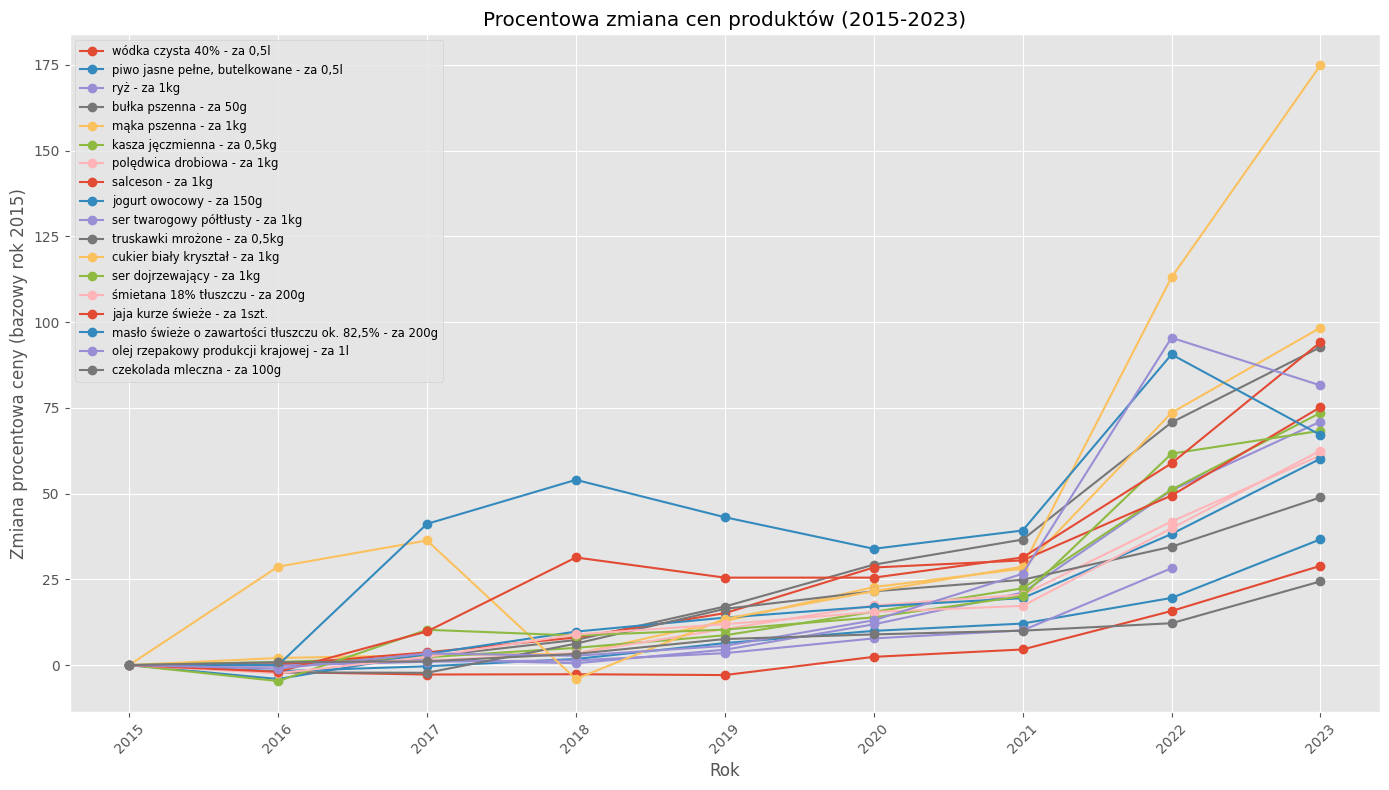

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def process_excel_file(file_path, sheet_name='TABLICA'):
    """
    Przetwarza plik Excel z danymi GUS i zwraca DataFrame z odpowiednimi kolumnami i indeksami.

    Parameters:
        file_path (str): Ścieżka do pliku Excel.
        sheet_name (str): Nazwa arkusza, domyślnie 'TABLICA'.

    Returns:
        pd.DataFrame: Oczyszczony DataFrame z MultiIndex dla kolumn.
    """
    # Wczytaj dane z arkusza
    data = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # Wyodrębnij pierwszą kolumnę jako 'Nazwa'
    nazwa_column = data.iloc[3:, 0].reset_index(drop=True)
    nazwa_column.name = 'Nazwa'

    # Wyciągnij nagłówki dla pozostałych kolumn (3 wiersze)
    header = data.iloc[:3, 1:]
    # Wypełnij puste wartości – zamiast fillna(method='ffill') używamy ffill()
    header = header.ffill(axis=1)

    # Utwórz MultiIndex z uzupełnionych nagłówków
    multi_index = pd.MultiIndex.from_arrays(header.values, names=["Category", "Year", "Unit"])

    # Utwórz DataFrame z pominięciem wierszy nagłówków
    data_cleaned = pd.DataFrame(data.iloc[3:, 1:].values, columns=multi_index)

    # Dodaj kolumnę 'Nazwa' z powrotem do DataFrame, jeśli nie istnieje
    if 'Nazwa' not in data_cleaned.columns:
        data_cleaned.insert(0, 'Nazwa', nazwa_column)

    # Usuń wiersze i kolumny pełne braków oraz ustaw 'Nazwa' jako indeks
    data_cleaned = data_cleaned.dropna(how='all').reset_index(drop=True)
    data_cleaned.set_index('Nazwa', inplace=True)

    # Diagnoza dostępnych kolumn w MultiIndex
    print("Dostępne kategorie (Category):", data_cleaned.columns.get_level_values('Category').unique())
    print("Dostępne lata (Year):", data_cleaned.columns.get_level_values('Year').unique())
    print("Dostępne jednostki (Unit):", data_cleaned.columns.get_level_values('Unit').unique())

    return data_cleaned

# ---------------------------
# Wczytywanie plików źródłowych
# ---------------------------
file_path_1 = "POLSKA/GUS/Przeciętne miesięczne wydatki na 1 osobę.xlsx"
file_path_2 = "POLSKA/GUS/PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - ALKOHOL.xlsx"
file_path_3 = "POLSKA/GUS/PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - BEZ ALKOHOLU.xlsx"

# Przetwarzamy pliki Excel
df1 = process_excel_file(file_path_1)
df2 = process_excel_file(file_path_2)
df3 = process_excel_file(file_path_3)

# Jeśli potrzebujesz danych o ludności, wczytaj również plik CSV (opcjonalnie)
df_ludnosc = pd.read_csv("POLSKA/GUS/LUDNOSC_POLSKA.csv", delimiter=',')
df_ludnosc = df_ludnosc.set_index("Województwo")

# ---------------------------
# Lista produktów
# ---------------------------
products = [
    'wódka czysta 40% - za 0,5l',
    'piwo jasne pełne, butelkowane - za 0,5l',
    'ryż - za 1kg',
    'bułka pszenna - za 50g',
    'mąka pszenna - za 1kg',
    'kasza jęczmienna - za 0,5kg',
    'mięso wieprzowe bez kości (schab) - za 1 kg',
    'polędwica drobiowa - za 1kg',
    'salceson - za 1kg',
    'mleko krowie spożywcze  2-2,5% tłuszczu 1l',
    'jogurt owocowy 250ml',
    'jogurt owocowy - za 150g',
    'ser twarogowy półtłusty - za 1kg',
    'truskawki mrożone - za 0,5kg',
    'cukier biały kryształ - za 1kg',
    'ser dojrzewający - za 1kg',
    'śmietana 18% tłuszczu - za 200ml',
    'śmietana 18% tłuszczu - za 200g',
    'jaja kurze świeże - za 1szt.',
    'masło świeże o zawartości tłuszczu ok. 82,5% - za 200g',
    'olej rzepakowy produkcji krajowej - za 1l',
    'czekolada mleczna - za 100g'
]

# Zakładamy, że produkty alkoholowe znajdują się w df2, a pozostałe (żywnościowe) w df3.
alcohol_products = {'wódka czysta 40% - za 0,5l', 'piwo jasne pełne, butelkowane - za 0,5l'}

# ---------------------------
# Wybór reprezentatywnego wiersza (np. "ogółem")
# ---------------------------
if 'ogółem' in df2.index:
    s_alcohol = df2.loc['ogółem']
else:
    s_alcohol = df2.iloc[0]

if 'ogółem' in df3.index:
    s_food = df3.loc['ogółem']
else:
    s_food = df3.iloc[0]

# ---------------------------
# Obliczanie procentowej zmiany cen
# ---------------------------
# Definiujemy zakres lat (jako stringi, ponieważ w nagłówkach lata są zapisane jako string)
years = [str(y) for y in range(2015, 2024)]

# Słownik, do którego zapiszemy obliczone zmiany procentowe dla każdego produktu
data_pct = {}

for product in products:
    # W zależności od produktu wybieramy źródło danych (alkohol lub żywność)
    if product in alcohol_products:
        try:
            # Pobieramy szereg dla danego produktu – filtrujemy po poziomie 'Category' i 'Unit'
            ts = s_alcohol.xs(product, level='Category').xs('[zł]', level='Unit')
        except KeyError:
            print(f"Produkt {product} nie znaleziony w danych alkoholowych.")
            continue
    else:
        try:
            ts = s_food.xs(product, level='Category').xs('[zł]', level='Unit')
        except KeyError:
            print(f"Produkt {product} nie znaleziony w danych żywnościowych.")
            continue

    # Pozostawiamy tylko dane dla lat 2015-2023; reindex gwarantuje, że wszystkie lata są obecne
    ts = ts[ts.index.isin(years)].reindex(years)

    # Jeśli dane są typu object, sprawdzamy czy elementy są napisami.
    # Jeśli wszystkie elementy są napisami, wykonujemy zamianę przecinków na kropki.
    if ts.dtype == object and ts.apply(lambda x: isinstance(x, str)).all():
        ts = ts.str.replace(',', '.')
        ts = pd.to_numeric(ts, errors='coerce')
    # Jeśli dane nie są numeryczne, wykonujemy konwersję – zabezpieczenie na wypadek mieszanych typów.
    elif not pd.api.types.is_numeric_dtype(ts):
        ts = pd.to_numeric(ts.astype(str).str.replace(',', '.'), errors='coerce')

    # Wyznaczamy bazową wartość z roku 2015
    try:
        base_value = ts.loc['2015']
    except KeyError:
        print(f"Brak danych dla roku 2015 dla produktu {product}.")
        continue

    if base_value == 0 or pd.isna(base_value):
        print(f"Brak lub zerowa wartość bazowa dla produktu {product}.")
        continue

    # Obliczamy procentową zmianę względem roku 2015:
    # (wartość bieżąca - wartość 2015) / wartość 2015 * 100
    pct_change = (ts - base_value) / base_value * 100
    data_pct[product] = pct_change

# Łączymy wyniki w DataFrame, gdzie wiersze to lata, a kolumny to poszczególne produkty
df_pct = pd.DataFrame(data_pct, index=years)

# ---------------------------
# Rysowanie wykresu
# ---------------------------
plt.figure(figsize=(14, 8))
for product in df_pct.columns:
    plt.plot(df_pct.index, df_pct[product], marker='o', label=product)

plt.xlabel('Rok')
plt.ylabel('Zmiana procentowa ceny (bazowy rok 2015)')
plt.title('Procentowa zmiana cen produktów (2015-2023)')
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Dostępne kategorie (Category): Index(['ogółem', 'towary i usługi konsumpcyjne',
       'żywność i napoje bezalkoholowe',
       'napoje alkoholowe i wyroby tytoniowe', 'odzież i obuwie',
       'użytkowanie mieszkania lub domu i nośniki energii',
       'wyposażenie mieszkania i prowadzenie gospodarstwa domowego', 'zdrowie',
       'transport', 'łączność', 'rekreacja i kultura', 'edukacja',
       'restauracje i hotele', 'pozostałe wydatki na towary i usługi',
       'ogółem (BAEL)', 'towary i usługi konsumpcyjne (BAEL)',
       'udział wydatków na żywność i napoje bezalkoholowe w wydatkach ogółem',
       'udział wydatków na użytkowanie mieszkania i nośniki energii w wydatkach ogółem'],
      dtype='object', name='Category')
Dostępne lata (Year): Index(['1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023'],
      dtype=

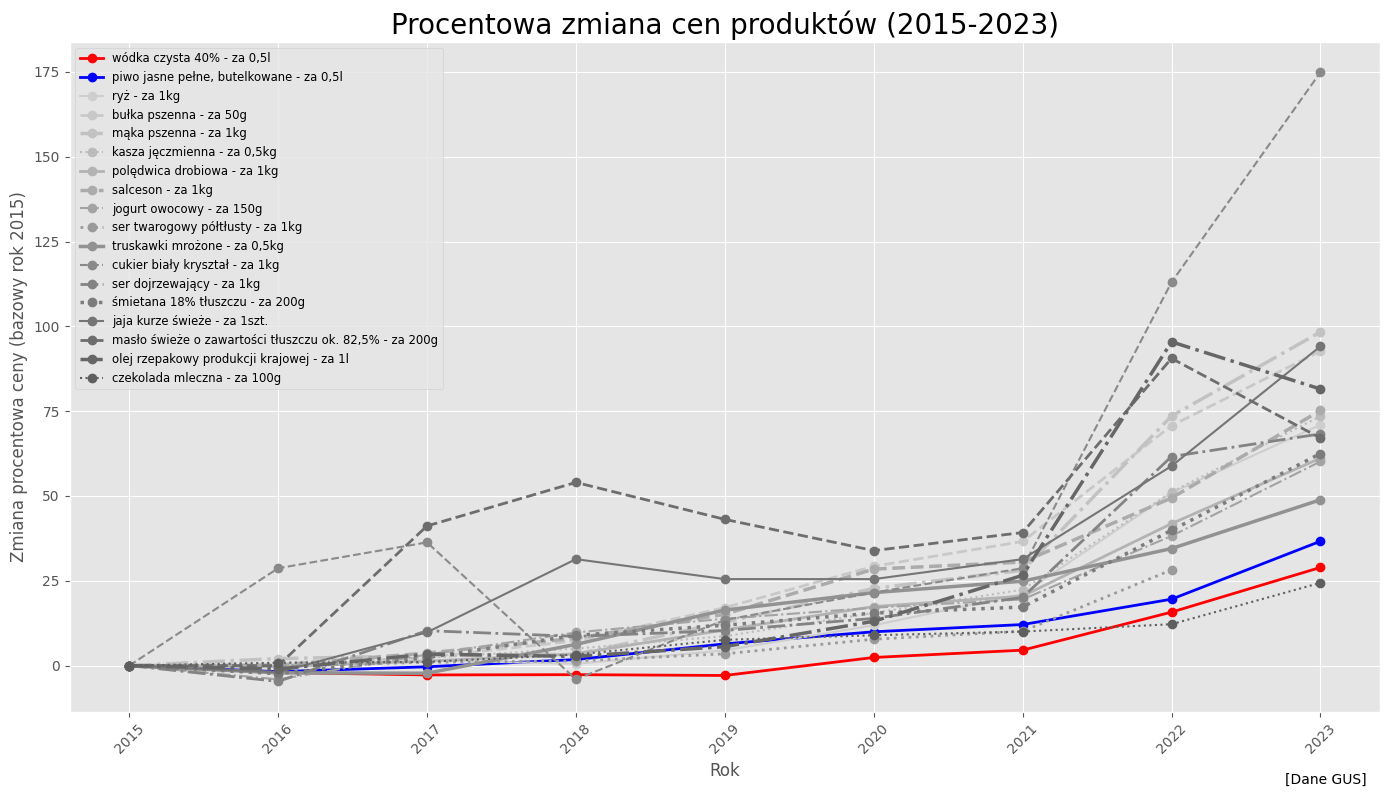

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def process_excel_file(file_path, sheet_name='TABLICA'):
    """
    Przetwarza plik Excel z danymi GUS i zwraca DataFrame z odpowiednimi kolumnami i indeksami.

    Parameters:
        file_path (str): Ścieżka do pliku Excel.
        sheet_name (str): Nazwa arkusza, domyślnie 'TABLICA'.

    Returns:
        pd.DataFrame: Oczyszczony DataFrame z MultiIndex dla kolumn.
    """
    # Wczytaj dane z arkusza
    data = pd.read_excel(file_path, sheet_name=sheet_name, header=None)

    # Wyodrębnij pierwszą kolumnę jako 'Nazwa'
    nazwa_column = data.iloc[3:, 0].reset_index(drop=True)
    nazwa_column.name = 'Nazwa'

    # Wyciągnij nagłówki dla pozostałych kolumn (3 wiersze)
    header = data.iloc[:3, 1:]
    # Wypełnij puste wartości – zamiast fillna(method='ffill') używamy ffill()
    header = header.ffill(axis=1)

    # Utwórz MultiIndex z uzupełnionych nagłówków
    multi_index = pd.MultiIndex.from_arrays(header.values, names=["Category", "Year", "Unit"])

    # Utwórz DataFrame z pominięciem wierszy nagłówków
    data_cleaned = pd.DataFrame(data.iloc[3:, 1:].values, columns=multi_index)

    # Dodaj kolumnę 'Nazwa' z powrotem do DataFrame, jeśli nie istnieje
    if 'Nazwa' not in data_cleaned.columns:
        data_cleaned.insert(0, 'Nazwa', nazwa_column)

    # Usuń wiersze i kolumny pełne braków oraz ustaw 'Nazwa' jako indeks
    data_cleaned = data_cleaned.dropna(how='all').reset_index(drop=True)
    data_cleaned.set_index('Nazwa', inplace=True)

    # Diagnoza dostępnych kolumn w MultiIndex
    print("Dostępne kategorie (Category):", data_cleaned.columns.get_level_values('Category').unique())
    print("Dostępne lata (Year):", data_cleaned.columns.get_level_values('Year').unique())
    print("Dostępne jednostki (Unit):", data_cleaned.columns.get_level_values('Unit').unique())

    return data_cleaned

# ---------------------------
# Wczytywanie plików źródłowych
# ---------------------------
file_path_1 = "POLSKA/GUS/Przeciętne miesięczne wydatki na 1 osobę.xlsx"
file_path_2 = "POLSKA/GUS/PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - ALKOHOL.xlsx"
file_path_3 = "POLSKA/GUS/PRZECIĘTNE CENY DETALICZNE TOWARÓW I USŁUG KONSUMPCYJNYCH - BEZ ALKOHOLU.xlsx"

# Przetwarzamy pliki Excel
df1 = process_excel_file(file_path_1)
df2 = process_excel_file(file_path_2)
df3 = process_excel_file(file_path_3)

# Jeśli potrzebujesz danych o ludności, wczytaj również plik CSV (opcjonalnie)
df_ludnosc = pd.read_csv("POLSKA/GUS/LUDNOSC_POLSKA.csv", delimiter=',')
df_ludnosc = df_ludnosc.set_index("Województwo")

# ---------------------------
# Lista produktów
# ---------------------------
products = [
    'wódka czysta 40% - za 0,5l',
    'piwo jasne pełne, butelkowane - za 0,5l',
    'ryż - za 1kg',
    'bułka pszenna - za 50g',
    'mąka pszenna - za 1kg',
    'kasza jęczmienna - za 0,5kg',
    'mięso wieprzowe bez kości (schab) - za 1 kg',
    'polędwica drobiowa - za 1kg',
    'salceson - za 1kg',
    'mleko krowie spożywcze  2-2,5% tłuszczu 1l',
    'jogurt owocowy 250ml',
    'jogurt owocowy - za 150g',
    'ser twarogowy półtłusty - za 1kg',
    'truskawki mrożone - za 0,5kg',
    'cukier biały kryształ - za 1kg',
    'ser dojrzewający - za 1kg',
    'śmietana 18% tłuszczu - za 200ml',
    'śmietana 18% tłuszczu - za 200g',
    'jaja kurze świeże - za 1szt.',
    'masło świeże o zawartości tłuszczu ok. 82,5% - za 200g',
    'olej rzepakowy produkcji krajowej - za 1l',
    'czekolada mleczna - za 100g'
]

# Zakładamy, że produkty alkoholowe znajdują się w df2, a pozostałe (żywnościowe) w df3.
alcohol_products = {'wódka czysta 40% - za 0,5l', 'piwo jasne pełne, butelkowane - za 0,5l'}

# ---------------------------
# Wybór reprezentatywnego wiersza (np. "ogółem")
# ---------------------------
if 'ogółem' in df2.index:
    s_alcohol = df2.loc['ogółem']
else:
    s_alcohol = df2.iloc[0]

if 'ogółem' in df3.index:
    s_food = df3.loc['ogółem']
else:
    s_food = df3.iloc[0]

# ---------------------------
# Obliczanie procentowej zmiany cen
# ---------------------------
# Definiujemy zakres lat (jako stringi, ponieważ w nagłówkach lata są zapisane jako string)
years = [str(y) for y in range(2015, 2024)]

# Słownik, do którego zapiszemy obliczone zmiany procentowe dla każdego produktu
data_pct = {}

for product in products:
    # W zależności od produktu wybieramy źródło danych (alkohol lub żywność)
    if product in alcohol_products:
        try:
            # Pobieramy szereg dla danego produktu – filtrujemy po poziomie 'Category' i 'Unit'
            ts = s_alcohol.xs(product, level='Category').xs('[zł]', level='Unit')
        except KeyError:
            print(f"Produkt {product} nie znaleziony w danych alkoholowych.")
            continue
    else:
        try:
            ts = s_food.xs(product, level='Category').xs('[zł]', level='Unit')
        except KeyError:
            print(f"Produkt {product} nie znaleziony w danych żywnościowych.")
            continue

    # Pozostawiamy tylko dane dla lat 2015-2023; reindex gwarantuje, że wszystkie lata są obecne
    ts = ts[ts.index.isin(years)].reindex(years)

    # Jeśli dane są typu object, sprawdzamy czy elementy są napisami i dokonujemy ewentualnej konwersji
    if ts.dtype == object and ts.apply(lambda x: isinstance(x, str)).all():
        ts = ts.str.replace(',', '.')
        ts = pd.to_numeric(ts, errors='coerce')
    elif not pd.api.types.is_numeric_dtype(ts):
        ts = pd.to_numeric(ts.astype(str).str.replace(',', '.'), errors='coerce')

    # Wyznaczamy bazową wartość z roku 2015
    try:
        base_value = ts.loc['2015']
    except KeyError:
        print(f"Brak danych dla roku 2015 dla produktu {product}.")
        continue

    if base_value == 0 or pd.isna(base_value):
        print(f"Brak lub zerowa wartość bazowa dla produktu {product}.")
        continue

    # Obliczamy procentową zmianę względem roku 2015:
    # (wartość bieżąca - wartość 2015) / wartość 2015 * 100
    pct_change = (ts - base_value) / base_value * 100
    data_pct[product] = pct_change

# Łączymy wyniki w DataFrame, gdzie wiersze to lata, a kolumny to poszczególne produkty
df_pct = pd.DataFrame(data_pct, index=years)

# ---------------------------
# Rysowanie wykresu z wyróżnieniem alkoholi oraz produktów żywnościowych
# ---------------------------
plt.figure(figsize=(14, 8))

# Definiujemy style dla produktów alkoholowych
alcohol_color_map = {
    'wódka czysta 40% - za 0,5l': 'red',
    'piwo jasne pełne, butelkowane - za 0,5l': 'blue'
}

# Wyznaczamy listę produktów niealkoholowych
non_alcohol_products = [prod for prod in df_pct.columns if prod not in alcohol_products]
n_non_alcohol = len(non_alcohol_products)
# Generujemy odcienie szarości (od nieco ciemniejszego do jaśniejszego)
gray_colors = plt.cm.Greys(np.linspace(0.3, 0.7, n_non_alcohol))
# Definiujemy możliwe style linii (solid, dashed, dashdot, dotted)
dash_styles = ['solid', 'dashed', 'dashdot', 'dotted']

# Mapujemy style dla produktów niealkoholowych
non_alcohol_styles = {}
for i, prod in enumerate(non_alcohol_products):
    color = gray_colors[i]
    linestyle = dash_styles[i % len(dash_styles)]
    # Przykładowa zmiana grubości linii – można dostosować według potrzeb
    linewidth = 1.5 + (i % 3) * 0.5
    non_alcohol_styles[prod] = {"color": color, "linestyle": linestyle, "linewidth": linewidth}

# Rysujemy wykresy dla wszystkich produktów
for product in df_pct.columns:
    if product in alcohol_products:
        plt.plot(df_pct.index, df_pct[product], marker='o', label=product,
                 color=alcohol_color_map.get(product, 'magenta'),
                 linewidth=2, linestyle='solid')
    else:
        style = non_alcohol_styles.get(product, {"color": "gray", "linestyle": "solid", "linewidth": 1.5})
        plt.plot(df_pct.index, df_pct[product], marker='o', label=product,
                 color=style["color"], linestyle=style["linestyle"], linewidth=style["linewidth"])

plt.xlabel('Rok')
plt.ylabel('Zmiana procentowa ceny (bazowy rok 2015)')
plt.title('Procentowa zmiana cen produktów (2015-2023)', fontsize = 20)
plt.legend(loc='best', fontsize='small')
plt.grid(True)
plt.xticks(rotation=45)
# Dodanie napisu [Dane GUS] w prawym dolnym rogu figury
plt.figtext(0.98, 0.01, '[Dane GUS]', ha='right', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()
